# NSCH Data Analysis

**Dataset:** National Survey of Children’s Health (NSCH)  
**Year:** 2024  
**Source:** U.S. Census Bureau / HRSA Maternal and Child Health Bureau  

## Research Role

The NSCH serves as the primary child- and family-level dataset for this project. This analysis examines factors associated with pediatric mental health need and unmet mental health care, with particular attention to factors that may be relevant to service or digital intervention.

## Research Questions

1. What factors are associated with unmet pediatric mental health care among children who need care?
2. Which child, family, and access-related factors appear most strongly associated with unmet need?
3. Which of these factors may be modifiable or addressable through service or digital intervention?

## Analysis Approach

This notebook applies the statistical concepts used in the Extern exploratory data analysis framework, including:

- descriptive statistics
- probability and prevalence estimates
- group comparisons
- hypothesis testing
- correlation where appropriate
- regression where appropriate
- Python-generated visualizations
- interpretation of findings in relation to the research questions

## Load the Cleaned NSCH Dataset

This analysis uses the cleaned NSCH dataset created during the data preparation phase. The cleaned file contains the variables selected for the pediatric mental health research questions and will serve as the analysis-ready source for this notebook.

Before beginning the statistical analysis, the dataset is loaded and its dimensions are confirmed.

In [4]:
import pandas as pd
from pathlib import Path

# Define path to cleaned NSCH dataset
data_path = Path("../../data/cleaned/NSCH_2024_cleaned_ages_6_to_17.csv")

# Load cleaned dataset
nsch = pd.read_csv(data_path)

print("Dataset shape:", nsch.shape)
nsch.head()

Dataset shape: (37534, 107)


,household_id,sampling_stratum,final_sampling_weight,state_fips_code,metropolitan_principal_city_status,hrsa_region,neighborhood_support,neighborhood_safety,neighborhood_amenities_count,provider_communication_with_other_services,...,ACEdomviol_24,ACEneighviol_24,ACEmhealth_24,ACEdrug_24,ACEdiscrim_24,ACEHealthDiscrim_24,ACE6ctHH_24,ACE2more6HH_24,ACEctComm_24,ACE1moreComm_24
0,24000016,1,14108.624370,48,2,6,1,1,99,2,...,2,2,2,2,2,2,0,1,0,1
1,24000081,1,1763.619834,47,2,4,2,2,1,2,...,2,2,2,2,2,2,0,1,0,1
2,24000088,1,109.931073,31,2,7,1,1,3,2,...,2,2,2,2,2,2,0,1,0,1
3,24000089,2,948.037623,27,2,5,1,1,2,2,...,2,2,1,1,2,2,3,3,0,1
4,24000173,1,532.319837,9,2,1,1,1,3,1,...,2,2,2,2,1,2,0,1,1,2


In [5]:
# Display all cleaned NSCH column names
for i, col in enumerate(nsch.columns, start=1):
    print(f"{i}. {col}")

1. household_id
2. sampling_stratum
3. final_sampling_weight
4. state_fips_code
5. metropolitan_principal_city_status
6. hrsa_region
7. neighborhood_support
8. neighborhood_safety
9. neighborhood_amenities_count
10. provider_communication_with_other_services
11. provider_communication_rating
12. sidewalks_available
13. park_available
14. recreation_center_available
15. library_available
16. child_age_years
17. child_sex
18. child_race
19. child_hispanic_ethnicity
20. anxiety_24
21. AnxietSev_24
22. depress_24
23. DepresSev_24
24. ADHD_24
25. ADHDSev_24
26. ADHDind_24
27. ADHDSevInd_24
28. autism_24
29. AutismSev_24
30. AutismInd_24
31. behavior_24
32. BehavSev_24
33. tourette_24
34. TouretSev_24
35. DevDelay_24
36. speech_24
37. learning_24
38. IntDisab_24
39. ADHDMed_24
40. ADHDBehTreat_24
41. ASDMed_24
42. ASDBehTreat_24
43. MedEmotion_24
44. therapy_24
45. rxmeds_24
46. MentHCare_24
47. MentHDiff_24
48. mhealth_24
49. mhneeds_24
50. nomAnxietyDep12to17_24
51. MEDB10ScrQ5_24
52. povl

## Analysis Variables

This notebook analyzes the cleaned 2024 NSCH dataset for children ages 6–17.

The analysis focuses on the variables retained during the data cleaning phase that are most relevant to the research questions. These variables are organized into the following groups:

- **Mental health:** anxiety, depression, ADHD, behavioral conditions, and overall mental health need
- **Mental health care:** therapy, medication, receipt of care, and difficulty obtaining care
- **Insurance and socioeconomic factors:** insurance coverage, insurance gaps, adequacy of coverage, and poverty level
- **Adverse childhood experiences (ACEs):** total ACE exposure and individual ACE indicators
- **Family factors:** caregiver physical and mental health, family resilience, and housing instability
- **School and social factors:** school engagement, grades, missed school, bullying, school safety, and extracurricular participation
- **Neighborhood factors:** neighborhood support, safety, and amenities
- **Demographic and geographic factors:** age, sex, race/ethnicity, state, and HRSA region

The goal is to identify which factors are most strongly associated with pediatric mental health need and difficulty accessing mental health care, and which findings may be most relevant for later service or digital intervention research.

In [6]:
# Review the cleaned NSCH variables available for analysis

analysis_groups = {
    "Mental Health": [
        "anxiety_24", "AnxietSev_24",
        "depress_24", "DepresSev_24",
        "ADHD_24", "ADHDSev_24",
        "behavior_24", "BehavSev_24",
        "mhealth_24", "mhneeds_24"
    ],

    "Mental Health Care": [
        "therapy_24",
        "rxmeds_24",
        "MentHCare_24",
        "MentHDiff_24"
    ],

    "Insurance and Poverty": [
        "povlev4_24",
        "insurance_24",
        "CurrIns_24",
        "InsGap_24",
        "InsAdeq_24"
    ],

    "ACEs": [
        "ACEct_24",
        "ACE2more_24",
        "ACEincome_24",
        "ACEdivorce_24",
        "ACEdeath_24",
        "ACEjail_24",
        "ACEdomviol_24",
        "ACEneighviol_24",
        "ACEmhealth_24",
        "ACEdrug_24",
        "ACEdiscrim_24"
    ],

    "Family": [
        "FAMILY_R",
        "ParentPhH_24",
        "ParentMH_24",
        "HousingInstab_24"
    ],

    "School and Social": [
        "SchlEngage_24",
        "GRADES",
        "SchlMiss_24",
        "bullied_24",
        "SchlSafe_24",
        "AftSchAct_24"
    ],

    "Neighborhood": [
        "neighborhood_support",
        "neighborhood_safety",
        "neighborhood_amenities_count"
    ],

    "Demographics": [
        "child_age_years",
        "child_sex",
        "child_race",
        "child_hispanic_ethnicity",
        "state_fips_code",
        "hrsa_region"
    ]
}

for group, variables in analysis_groups.items():
    print(f"\n{group}")
    print("-" * len(group))
    for variable in variables:
        print(variable)


Mental Health
-------------
anxiety_24
AnxietSev_24
depress_24
DepresSev_24
ADHD_24
ADHDSev_24
behavior_24
BehavSev_24
mhealth_24
mhneeds_24

Mental Health Care
------------------
therapy_24
rxmeds_24
MentHCare_24
MentHDiff_24

Insurance and Poverty
---------------------
povlev4_24
insurance_24
CurrIns_24
InsGap_24
InsAdeq_24

ACEs
----
ACEct_24
ACE2more_24
ACEincome_24
ACEdivorce_24
ACEdeath_24
ACEjail_24
ACEdomviol_24
ACEneighviol_24
ACEmhealth_24
ACEdrug_24
ACEdiscrim_24

Family
------
FAMILY_R
ParentPhH_24
ParentMH_24
HousingInstab_24

School and Social
-----------------
SchlEngage_24
GRADES
SchlMiss_24
bullied_24
SchlSafe_24
AftSchAct_24

Neighborhood
------------
neighborhood_support
neighborhood_safety
neighborhood_amenities_count

Demographics
------------
child_age_years
child_sex
child_race
child_hispanic_ethnicity
state_fips_code
hrsa_region


## Mental Health Need

The first stage of the analysis examines the prevalence and distribution of pediatric mental health need in the cleaned NSCH dataset.

This section focuses on the mental health indicators retained during data preparation, including anxiety, depression, ADHD, behavioral conditions, and broader measures of mental health need. The goal is to understand how common these conditions and needs are among children ages 6–17 before examining differences in access to care and the factors associated with those differences.

In [8]:
# Examine the distribution of the main mental health indicators

mental_health_vars = [
    "anxiety_24",
    "depress_24",
    "ADHD_24",
    "behavior_24",
    "mhealth_24",
    "mhneeds_24"
]

for col in mental_health_vars:
    print(f"\n{col}")
    print(nsch[col].value_counts(dropna=False).sort_index())


anxiety_24
anxiety_24
1     30052
2       626
3      6450
99      406
Name: count, dtype: int64

depress_24
depress_24
1     34068
2       670
3      2537
99      259
Name: count, dtype: int64

ADHD_24
ADHD_24
1     30774
2       320
3      6068
99      372
Name: count, dtype: int64

behavior_24
behavior_24
1     33195
2       890
3      3328
99      121
Name: count, dtype: int64

mhealth_24
mhealth_24
1     6402
2    31132
Name: count, dtype: int64

mhneeds_24
mhneeds_24
1     6402
2     5614
3    25518
Name: count, dtype: int64


In [10]:
# Calculate prevalence of current mental health conditions
# Primary analysis scope: anxiety, depression, or ADHD
# Code 3 = currently has condition
# Code 99 = missing and excluded from denominator

current_conditions = {
    "Anxiety": "anxiety_24",
    "Depression": "depress_24",
    "ADHD": "ADHD_24"
}

prevalence_results = []

for label, col in current_conditions.items():
    valid = nsch[nsch[col] != 99]
    current = (valid[col] == 3).sum()
    total = len(valid)
    percent = current / total * 100

    prevalence_results.append({
        "Condition": label,
        "Current cases": current,
        "Valid responses": total,
        "Percent": round(percent, 1)
    })

prevalence_df = pd.DataFrame(prevalence_results)

prevalence_df

,Condition,Current cases,Valid responses,Percent
0,Anxiety,6450,37128,17.4
1,Depression,2537,37275,6.8
2,ADHD,6068,37162,16.3


### Initial Finding

Within the three conditions used to define the primary mental health population, current anxiety was the most commonly reported condition at 17.4%, followed by ADHD at 16.3% and depression at 6.8%.

These condition-specific prevalence estimates provide context for the primary analysis population, which includes children with current anxiety, depression, or ADHD.

In [11]:
# Compare current anxiety, depression, and ADHD by age

age_condition_results = []

for age in sorted(nsch["child_age_years"].dropna().unique()):
    age_data = nsch[nsch["child_age_years"] == age]

    for label, col in current_conditions.items():
        valid = age_data[age_data[col] != 99]

        current = (valid[col] == 3).sum()
        total = len(valid)
        percent = current / total * 100 if total > 0 else None

        age_condition_results.append({
            "Age": age,
            "Condition": label,
            "Current cases": current,
            "Valid responses": total,
            "Percent": round(percent, 1)
        })

age_condition_df = pd.DataFrame(age_condition_results)

age_condition_df

,Age,Condition,Current cases,Valid responses,Percent
0,6,Anxiety,180,2184,8.2
1,6,Depression,13,2190,0.6
2,6,ADHD,188,2179,8.6
3,7,Anxiety,239,2387,10.0
4,7,Depression,30,2396,1.3
5,7,ADHD,329,2388,13.8
6,8,Anxiety,304,2543,12.0
7,8,Depression,51,2548,2.0
8,8,ADHD,406,2545,16.0
9,9,Anxiety,369,2600,14.2


In [12]:
# Compare current anxiety, depression, and ADHD by age group

age_group_data = nsch.copy()

age_group_data["age_group"] = pd.cut(
    age_group_data["child_age_years"],
    bins=[5, 11, 17],
    labels=["Ages 6–11", "Ages 12–17"]
)

age_group_results = []

for age_group in ["Ages 6–11", "Ages 12–17"]:
    group = age_group_data[age_group_data["age_group"] == age_group]

    for label, col in current_conditions.items():
        valid = group[group[col] != 99]

        current = (valid[col] == 3).sum()
        total = len(valid)
        percent = current / total * 100

        age_group_results.append({
            "Age group": age_group,
            "Condition": label,
            "Current cases": current,
            "Valid responses": total,
            "Percent": round(percent, 1)
        })

age_group_df = pd.DataFrame(age_group_results)

age_group_df

,Age group,Condition,Current cases,Valid responses,Percent
0,Ages 6–11,Anxiety,2000,15447,12.9
1,Ages 6–11,Depression,366,15486,2.4
2,Ages 6–11,ADHD,2307,15436,14.9
3,Ages 12–17,Anxiety,4450,21681,20.5
4,Ages 12–17,Depression,2171,21789,10.0
5,Ages 12–17,ADHD,3761,21726,17.3


In [13]:
# Create combined target population:
# current anxiety OR current depression OR current ADHD

valid_condition_data = nsch[
    (nsch["anxiety_24"] != 99) &
    (nsch["depress_24"] != 99) &
    (nsch["ADHD_24"] != 99)
].copy()

valid_condition_data["current_anxiety_depression_or_adhd"] = (
    (valid_condition_data["anxiety_24"] == 3) |
    (valid_condition_data["depress_24"] == 3) |
    (valid_condition_data["ADHD_24"] == 3)
)

target_count = valid_condition_data["current_anxiety_depression_or_adhd"].sum()
target_total = len(valid_condition_data)
target_percent = target_count / target_total * 100

print(f"Children with current anxiety, depression, or ADHD: {target_count:,}")
print(f"Valid responses: {target_total:,}")
print(f"Percent of valid sample: {target_percent:.1f}%")

Children with current anxiety, depression, or ADHD: 9,727
Valid responses: 36,610
Percent of valid sample: 26.6%


In [14]:
# Count current conditions per child to examine comorbidity

valid_condition_data["current_condition_count"] = (
    (valid_condition_data["anxiety_24"] == 3).astype(int) +
    (valid_condition_data["depress_24"] == 3).astype(int) +
    (valid_condition_data["ADHD_24"] == 3).astype(int)
)

comorbidity_results = (
    valid_condition_data["current_condition_count"]
    .value_counts()
    .sort_index()
    .rename_axis("Number of current conditions")
    .reset_index(name="Children")
)

comorbidity_results["Percent"] = (
    comorbidity_results["Children"] /
    len(valid_condition_data) * 100
).round(1)

comorbidity_results

,Number of current conditions,Children,Percent
0,0,26883,73.4
1,1,5768,15.8
2,2,2879,7.9
3,3,1080,3.0


In [15]:
# Children with two or more current conditions

comorbid_count = (valid_condition_data["current_condition_count"] >= 2).sum()
comorbid_percent = comorbid_count / len(valid_condition_data) * 100

print(f"Children with 2 or more current conditions: {comorbid_count:,}")
print(f"Percent of valid sample: {comorbid_percent:.1f}%")

Children with 2 or more current conditions: 3,959
Percent of valid sample: 10.8%


In [16]:
# Examine comorbidity within the target mental health population only

target_population = valid_condition_data[
    valid_condition_data["current_condition_count"] >= 1
].copy()

target_comorbidity = (
    target_population["current_condition_count"]
    .value_counts()
    .sort_index()
    .rename_axis("Number of current conditions")
    .reset_index(name="Children")
)

target_comorbidity["Percent of mental health population"] = (
    target_comorbidity["Children"] /
    len(target_population) * 100
).round(1)

target_comorbidity

,Number of current conditions,Children,Percent of mental health population
0,1,5768,59.3
1,2,2879,29.6
2,3,1080,11.1


In [17]:
# Identify the exact condition combination for every child
# in the target mental health population

target_population["condition_combination"] = target_population.apply(
    lambda row: " + ".join([
        condition
        for condition, present in [
            ("Anxiety", row["anxiety_24"] == 3),
            ("Depression", row["depress_24"] == 3),
            ("ADHD", row["ADHD_24"] == 3)
        ]
        if present
    ]),
    axis=1
)

# Count each exact combination
combination_results = (
    target_population["condition_combination"]
    .value_counts()
    .reset_index()
)

combination_results.columns = [
    "Condition combination",
    "Children"
]

# Add number of conditions in each combination
combination_results["Number of conditions"] = (
    combination_results["Condition combination"]
    .str.count(r"\+")
    .add(1)
)

# Percent of the full mental health population
combination_results["Percent of mental health population"] = (
    combination_results["Children"] /
    len(target_population) * 100
).round(1)

# Rank from most common to least common
combination_results["Rank"] = range(
    1,
    len(combination_results) + 1
)

# Reorder columns
combination_results = combination_results[
    [
        "Rank",
        "Condition combination",
        "Number of conditions",
        "Children",
        "Percent of mental health population"
    ]
]

combination_results

,Rank,Condition combination,Number of conditions,Children,Percent of mental health population
0,1,ADHD,1,3040,31.3
1,2,Anxiety,1,2531,26.0
2,3,Anxiety + ADHD,2,1697,17.4
3,4,Anxiety + Depression + ADHD,3,1080,11.1
4,5,Anxiety + Depression,2,1064,10.9
5,6,Depression,1,197,2.0
6,7,Depression + ADHD,2,118,1.2


In [18]:
# Identify the most common single-condition and comorbid patterns

single_conditions = combination_results[
    combination_results["Number of conditions"] == 1
]

two_conditions = combination_results[
    combination_results["Number of conditions"] == 2
]

three_conditions = combination_results[
    combination_results["Number of conditions"] == 3
]

print("Most common single condition:")
print(
    single_conditions.iloc[0][
        ["Condition combination", "Children",
         "Percent of mental health population"]
    ]
)

print("\nMost common two-condition combination:")
print(
    two_conditions.iloc[0][
        ["Condition combination", "Children",
         "Percent of mental health population"]
    ]
)

print("\nThree-condition group:")
print(
    three_conditions.iloc[0][
        ["Condition combination", "Children",
         "Percent of mental health population"]
    ]
)

Most common single condition:
Condition combination                  ADHD
Children                               3040
Percent of mental health population    31.3
Name: 0, dtype: object

Most common two-condition combination:
Condition combination                  Anxiety + ADHD
Children                                         1697
Percent of mental health population              17.4
Name: 2, dtype: object

Three-condition group:
Condition combination                  Anxiety + Depression + ADHD
Children                                                      1080
Percent of mental health population                           11.1
Name: 3, dtype: object


In [19]:
# Compare exact condition combinations by age group

target_population["age_group"] = pd.cut(
    target_population["child_age_years"],
    bins=[5, 11, 17],
    labels=["Ages 6–11", "Ages 12–17"]
)

age_combination_results = (
    target_population
    .groupby(["age_group", "condition_combination"], observed=False)
    .size()
    .reset_index(name="Children")
)

# Calculate percent within each age group's mental health population
age_totals = (
    target_population
    .groupby("age_group", observed=False)
    .size()
    .rename("Age group total")
    .reset_index()
)

age_combination_results = age_combination_results.merge(
    age_totals,
    on="age_group"
)

age_combination_results["Percent within age group"] = (
    age_combination_results["Children"] /
    age_combination_results["Age group total"] * 100
).round(1)

# Rank combinations within each age group
age_combination_results["Rank within age group"] = (
    age_combination_results
    .groupby("age_group", observed=False)["Children"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

age_combination_results = age_combination_results.sort_values(
    ["age_group", "Rank within age group"]
)

age_combination_results

,age_group,condition_combination,Children,Age group total,Percent within age group,Rank within age group
0,Ages 6–11,ADHD,1320,3340,39.5,1
1,Ages 6–11,Anxiety,935,3340,28.0,2
2,Ages 6–11,Anxiety + ADHD,727,3340,21.8,3
4,Ages 6–11,Anxiety + Depression + ADHD,197,3340,5.9,4
3,Ages 6–11,Anxiety + Depression,120,3340,3.6,5
6,Ages 6–11,Depression + ADHD,21,3340,0.6,6
5,Ages 6–11,Depression,20,3340,0.6,7
7,Ages 12–17,ADHD,1720,6387,26.9,1
8,Ages 12–17,Anxiety,1596,6387,25.0,2
9,Ages 12–17,Anxiety + ADHD,970,6387,15.2,3


## Mental Health Care Access

The primary research question focuses on unmet mental health care among children with current anxiety, depression, or ADHD.

This section narrows the analysis to children in the target mental health population who needed mental health treatment or counseling. It then examines the prevalence of unmet care and whether access differs by age, diagnosis pattern, comorbidity, socioeconomic conditions, family factors, and other potential risk factors.

In [20]:
# Create the mental health care access population

# Keep children with current anxiety, depression, or ADHD
mental_health_population = target_population.copy()

# MentHCare_24:
# 1 = needed care and received it
# 2 = needed care but did not receive it
# 3 = did not need care
#
# Restrict analysis to children who needed care
care_population = mental_health_population[
    mental_health_population["MentHCare_24"].isin([1, 2])
].copy()

# Binary outcome:
# 0 = care received
# 1 = unmet care
care_population["unmet_care"] = (
    care_population["MentHCare_24"] == 2
).astype(int)

print(f"Target mental health population: {len(mental_health_population):,}")
print(f"Children who needed mental health care: {len(care_population):,}")

unmet_count = care_population["unmet_care"].sum()
unmet_percent = care_population["unmet_care"].mean() * 100

print(f"Children with unmet care: {unmet_count:,}")
print(f"Unmet-care rate: {unmet_percent:.1f}%")

Target mental health population: 9,727
Children who needed mental health care: 5,741
Children with unmet care: 694
Unmet-care rate: 12.1%


In [21]:
# Add age group

care_population["age_group"] = pd.cut(
    care_population["child_age_years"],
    bins=[5, 11, 17],
    labels=["Ages 6–11", "Ages 12–17"]
)

# Create comorbidity category

care_population["condition_burden"] = care_population[
    "current_condition_count"
].map({
    1: "One condition",
    2: "Two conditions",
    3: "Three conditions"
})

def unmet_rate_table(data, group_col):
    results = (
        data.groupby(group_col, observed=False)
        .agg(
            Children=("unmet_care", "size"),
            Unmet_care=("unmet_care", "sum"),
            Unmet_rate=("unmet_care", "mean")
        )
        .reset_index()
    )

    results["Unmet_rate"] = (
        results["Unmet_rate"] * 100
    ).round(1)

    return results

print("UNMET CARE BY AGE GROUP")
display(unmet_rate_table(care_population, "age_group"))

print("\nUNMET CARE BY NUMBER OF CONDITIONS")
display(unmet_rate_table(care_population, "condition_burden"))

UNMET CARE BY AGE GROUP


,age_group,Children,Unmet_care,Unmet_rate
0,Ages 6–11,1845,251,13.6
1,Ages 12–17,3896,443,11.4



UNMET CARE BY NUMBER OF CONDITIONS


,condition_burden,Children,Unmet_care,Unmet_rate
0,One condition,2553,360,14.1
1,Three conditions,974,98,10.1
2,Two conditions,2214,236,10.7


In [22]:
# Compare unmet care across exact condition combinations

combination_access = unmet_rate_table(
    care_population,
    "condition_combination"
)

combination_access = combination_access.sort_values(
    "Unmet_rate",
    ascending=False
)

combination_access

,condition_combination,Children,Unmet_care,Unmet_rate
0,ADHD,996,142,14.3
1,Anxiety,1413,198,14.0
5,Depression,144,20,13.9
3,Anxiety + Depression,934,105,11.2
2,Anxiety + ADHD,1184,123,10.4
4,Anxiety + Depression + ADHD,974,98,10.1
6,Depression + ADHD,96,8,8.3


In [23]:
# Candidate factors related to the research questions

candidate_factors = [
    "age_group",
    "condition_burden",
    "condition_combination",

    # Insurance / socioeconomic
    "povlev4_24",
    "CurrIns_24",
    "InsGap_24",
    "InsAdeq_24",

    # ACEs
    "ACE2more_24",

    # Family
    "ParentMH_24",
    "FAMILY_R",
    "HousingInstab_24",

    # School / social
    "SchlEngage_24",
    "SchlSafe_24",

    # Neighborhood
    "neighborhood_support",
    "neighborhood_safety",

    # Demographics
    "child_sex",
    "child_race",
    "child_hispanic_ethnicity"
]

In [24]:
# Explore unmet-care rates across candidate factors

for factor in candidate_factors:
    print(f"\n{'=' * 60}")
    print(f"UNMET CARE BY: {factor}")
    print("=" * 60)

    display(
        unmet_rate_table(
            care_population,
            factor
        ).sort_values(
            "Unmet_rate",
            ascending=False
        )
    )


UNMET CARE BY: age_group


,age_group,Children,Unmet_care,Unmet_rate
0,Ages 6–11,1845,251,13.6
1,Ages 12–17,3896,443,11.4



UNMET CARE BY: condition_burden


,condition_burden,Children,Unmet_care,Unmet_rate
0,One condition,2553,360,14.1
2,Two conditions,2214,236,10.7
1,Three conditions,974,98,10.1



UNMET CARE BY: condition_combination


...

,child_sex,Children,Unmet_care,Unmet_rate
0,1,2670,359,13.4
1,2,3071,335,10.9



UNMET CARE BY: child_race


,child_race,Children,Unmet_care,Unmet_rate
3,4,133,30,22.6
4,5,11,2,18.2
1,2,329,53,16.1
5,7,492,67,13.6
0,1,4716,537,11.4
2,3,60,5,8.3



UNMET CARE BY: child_hispanic_ethnicity


,child_hispanic_ethnicity,Children,Unmet_care,Unmet_rate
0,1,700,107,15.3
1,2,5041,587,11.6


In [25]:
from scipy.stats import chi2_contingency
import numpy as np

chi_square_results = []

for factor in candidate_factors:

    # Exclude missing/special codes
    test_data = care_population[
        care_population[factor].notna()
    ].copy()

    contingency = pd.crosstab(
        test_data[factor],
        test_data["unmet_care"]
    )

    # Need at least 2 categories
    if contingency.shape[0] < 2 or contingency.shape[1] < 2:
        continue

    chi2, p, dof, expected = chi2_contingency(contingency)

    n = contingency.to_numpy().sum()
    min_dim = min(contingency.shape) - 1

    cramers_v = (
        np.sqrt(chi2 / (n * min_dim))
        if min_dim > 0 else np.nan
    )

    chi_square_results.append({
        "Factor": factor,
        "Chi-square": round(chi2, 2),
        "p-value": p,
        "Cramer's V": round(cramers_v, 3),
        "N": n
    })

chi_square_df = pd.DataFrame(
    chi_square_results
).sort_values(
    "Cramer's V",
    ascending=False
)

chi_square_df

,Factor,Chi-square,p-value,Cramer's V,N
8,ParentMH_24,58.34,1.330089e-12,0.101,5741
3,povlev4_24,47.88,2.258351e-10,0.091,5741
11,SchlEngage_24,43.51,1.918406e-09,0.087,5741
9,FAMILY_R,39.10,4.715532e-06,0.083,5741
5,InsGap_24,32.91,7.133185e-08,0.076,5741
13,neighborhood_support,33.33,5.792206e-08,0.076,5741
7,ACE2more_24,32.09,4.999876e-07,0.075,5741
14,neighborhood_safety,30.94,8.761524e-07,0.073,5741
10,HousingInstab_24,24.04,6.024245e-06,0.065,5741
16,child_race,23.17,3.135626e-04,0.064,5741


In [27]:
%pip install statsmodels

     ---------------------------------------- 0.0/20.7 MB ? eta -:--:--
     ---------------------------------------- 0.0/20.7 MB ? eta -:--:--
      --------------------------------------- 0.3/20.7 MB ? eta -:--:--
     - -------------------------------------- 0.5/20.7 MB 1.0 MB/s eta 0:00:20
     - ------------------------------------- 0.8/20.7 MB 976.7 kB/s eta 0:00:21
     - ------------------------------------- 0.8/20.7 MB 976.7 kB/s eta 0:00:21
     - ------------------------------------- 0.8/20.7 MB 976.7 kB/s eta 0:00:21
     - ------------------------------------- 1.0/20.7 MB 789.9 kB/s eta 0:00:25
     -- ------------------------------------ 1.3/20.7 MB 756.3 kB/s eta 0:00:26
     -- ------------------------------------ 1.3/20.7 MB 756.3 kB/s eta 0:00:26
     -- ------------------------------------ 1.3/20.7 MB 756.3 kB/s eta 0:00:26
     -- ------------------------------------ 1.6/20.7 MB 686.7 kB/s eta 0:00:28
     --- ----------------------------------- 1.8/20.7 MB 738.4 kB

  error: subprocess-exited-with-error
  
  × Building wheel for statsmodels (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [1557 lines of output]
      C:\Users\akila\AppData\Local\Temp\pip-build-env-z491citw\overlay\Lib\site-packages\setuptools\dist.py:765: SetuptoolsDeprecationWarning: License classifiers are deprecated.
      !!
      
              ********************************************************************************
              Please consider removing the following classifiers in favor of a SPDX license expression:
      
              License :: OSI Approved :: BSD License
      
              See https://packaging.python.org/en/latest/guides/writing-pyproject-toml/#license for details.
              ********************************************************************************
      
      !!
        self._finalize_license_expression()
      running bdist_wheel
      running build
      running build_py
      creating build\lib.win-arm64-cpytho

In [31]:
from scipy.stats import chi2_contingency
import numpy as np
import pandas as pd

# Factors to test against unmet mental health care
chi_square_factors = [
    "age_group",
    "condition_burden",
    "condition_combination",
    "povlev4_24",
    "CurrIns_24",
    "InsGap_24",
    "InsAdeq_24",
    "ACE2more_24",
    "ParentMH_24",
    "FAMILY_R",
    "HousingInstab_24",
    "SchlEngage_24",
    "SchlSafe_24",
    "neighborhood_support",
    "neighborhood_safety",
    "child_sex",
    "child_race",
    "child_hispanic_ethnicity"
]

chi_square_results = []

for factor in chi_square_factors:

    # Keep only valid responses
    test_data = care_population[
        care_population[factor].notna()
    ].copy()

    # Remove common NSCH special/missing codes
    if pd.api.types.is_numeric_dtype(test_data[factor]):
        test_data = test_data[
            ~test_data[factor].isin([90, 95, 99])
        ]

    # Create contingency table
    contingency = pd.crosstab(
        test_data[factor],
        test_data["unmet_care"]
    )

    # Skip variables that do not have enough categories
    if contingency.shape[0] < 2 or contingency.shape[1] < 2:
        continue

    # Run chi-square test
    chi2, p_value, dof, expected = chi2_contingency(contingency)

    # Calculate Cramér's V as an effect-size measure
    n = contingency.to_numpy().sum()
    min_dimension = min(contingency.shape[0] - 1,
                        contingency.shape[1] - 1)

    if min_dimension > 0:
        cramers_v = np.sqrt(
            chi2 / (n * min_dimension)
        )
    else:
        cramers_v = np.nan

    chi_square_results.append({
        "Factor": factor,
        "N": n,
        "Chi-square": round(chi2, 2),
        "Degrees of freedom": dof,
        "p-value": p_value,
        "Cramer's V": round(cramers_v, 3)
    })

# Create results table
chi_square_df = pd.DataFrame(chi_square_results)

# Sort strongest associations first
chi_square_df = chi_square_df.sort_values(
    "Cramer's V",
    ascending=False
).reset_index(drop=True)

chi_square_df

,Factor,N,Chi-square,Degrees of freedom,p-value,Cramer's V
0,ParentMH_24,5639,58.31,2,2.183793e-13,0.102
1,povlev4_24,5741,47.88,3,2.258351e-10,0.091
2,FAMILY_R,5644,39.10,7,1.867774e-06,0.083
3,neighborhood_support,5624,32.65,1,1.102015e-08,0.076
4,ACE2more_24,5701,32.09,2,1.073532e-07,0.075
5,InsGap_24,5696,31.39,1,2.107546e-08,0.074
6,neighborhood_safety,5646,30.90,2,1.955291e-07,0.074
7,SchlEngage_24,5703,30.11,2,2.888129e-07,0.073
8,child_race,5741,23.17,5,3.135626e-04,0.064
9,HousingInstab_24,5684,22.90,1,1.710739e-06,0.063


In [34]:
import sklearn
print(sklearn.__version__)

1.9.0


In [35]:
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np

# Select variables for the multivariable model
model_vars = [
    "unmet_care",
    "child_age_years",
    "current_condition_count",
    "povlev4_24",
    "InsAdeq_24",
    "ACE2more_24",
    "ParentMH_24",
    "FAMILY_R",
    "SchlEngage_24",
    "neighborhood_support"
]

model_data = care_population[model_vars].copy()

# Remove special/missing codes
for col in model_vars[3:]:
    model_data = model_data[
        ~model_data[col].isin([90, 95, 99])
    ]

model_data = model_data.dropna()

print("Rows used in regression:", len(model_data))

Rows used in regression: 5337


In [36]:
# Separate predictors and outcome

X = model_data.drop(columns="unmet_care")
y = model_data["unmet_care"]

# Treat coded categorical variables as categories
categorical_vars = [
    "povlev4_24",
    "InsAdeq_24",
    "ACE2more_24",
    "ParentMH_24",
    "FAMILY_R",
    "SchlEngage_24",
    "neighborhood_support"
]

X = pd.get_dummies(
    X,
    columns=categorical_vars,
    drop_first=True,
    dtype=int
)

# Fit logistic regression
log_reg = LogisticRegression(
    max_iter=3000
)

log_reg.fit(X, y)

print("Regression fitted successfully.")
print("Observations:", len(X))
print("Predictors:", X.shape[1])

Regression fitted successfully.
Observations: 5337
Predictors: 20


In [37]:
# Convert regression coefficients to odds ratios

regression_results = pd.DataFrame({
    "Predictor": X.columns,
    "Coefficient": log_reg.coef_[0],
    "Odds Ratio": np.exp(log_reg.coef_[0])
})

regression_results["Distance from 1"] = (
    regression_results["Odds Ratio"] - 1
).abs()

regression_results = regression_results.sort_values(
    "Distance from 1",
    ascending=False
).reset_index(drop=True)

regression_results[
    ["Predictor", "Coefficient", "Odds Ratio"]
].round(3)

,Predictor,Coefficient,Odds Ratio
0,ParentMH_24_3,0.605,1.832
1,SchlEngage_24_3,0.575,1.777
2,FAMILY_R_8,-1.130,0.323
3,FAMILY_R_2,0.430,1.537
4,povlev4_24_4,-0.436,0.647
5,current_condition_count,-0.376,0.687
6,ParentMH_24_2,0.253,1.288
7,SchlEngage_24_2,0.251,1.285
8,neighborhood_support_2,0.208,1.232
9,povlev4_24_2,-0.240,0.787


# NSCH Analysis Summary

This analysis examined unmet mental health care among children ages 6–17 with current anxiety, depression, or ADHD.

### Mental Health Population

Among children with valid responses for all three conditions, 9,727 children, or 26.6% of the unweighted cleaned sample, had current anxiety, depression, or ADHD.

Condition prevalence differed by age. Among children ages 6–11, ADHD was the most common of the three conditions, while anxiety was the most common among adolescents ages 12–17. Depression also increased substantially in adolescence.

Comorbidity was common within the mental health population:

- 59.3% had one of the three conditions
- 29.6% had two conditions
- 11.1% had all three conditions

ADHD alone was the most common single-condition pattern, while anxiety + ADHD was the most common two-condition combination.

### Mental Health Care Access

Among children in the target mental health population who needed mental health treatment or counseling, the analysis examined whether care was received and which factors were associated with unmet care.

Bivariate chi-square tests identified statistically significant relationships between unmet care and multiple family, socioeconomic, school, neighborhood, insurance, and child characteristics.

Cramér's V was used alongside chi-square testing to compare the relative strength of these categorical associations. The strongest observed bivariate associations included:

- parent mental health
- poverty level
- family factors
- neighborhood support
- adverse childhood experience exposure
- insurance gaps
- neighborhood safety
- school engagement

Effect sizes were generally small, suggesting that unmet mental health care is not explained by a single factor but is associated with multiple overlapping conditions.

### Multivariable Analysis

A logistic regression model was used to examine multiple predictors of unmet mental health care simultaneously.

The model included 5,337 complete observations and 20 encoded predictors. Parent mental health, school engagement, family factors, neighborhood support, poverty, insurance adequacy, ACE exposure, condition burden, and age were examined together.

The largest odds-ratio differences in the fitted model appeared for categories of parent mental health, school engagement, and family factors. Age showed comparatively little change in modeled odds of unmet care.

Because the logistic regression was fitted using scikit-learn, the regression coefficients and odds ratios are used descriptively and are interpreted together with the chi-square and Cramér's V findings rather than as standalone significance tests.

### Interpretation

The NSCH findings suggest an important distinction between factors associated with having a mental health condition and factors associated with difficulty accessing care.

Age was strongly related to the distribution of anxiety and depression, particularly during adolescence, but showed a much weaker relationship with unmet care. In contrast, family, socioeconomic, insurance, school, and neighborhood conditions showed stronger relationships with care access.

These results support the next stage of the project: using ACS, NCES, HPSA, and YRBSS data to examine how these individual- and family-level patterns intersect with community resources, school environments, provider shortages, and youth behavioral-health conditions.

### Carry Forward

**Primary NSCH contribution:**  
Identify child- and family-level factors associated with unmet mental health care among children with current anxiety, depression, or ADHD.

**Factors to carry into cross-dataset synthesis:**  
Parent mental health, poverty, family conditions, ACE exposure, insurance access, school engagement, neighborhood support and safety, and mental health condition burden.

**Service-design relevance:**  
Prioritize factors that may be addressable through navigation, education, family support, school-based support, referral pathways, and other digital or service interventions.

In [38]:
import nbformat as nbf
from pathlib import Path

nb = nbf.v4.new_notebook()
cells = []

# =========================================================
# TITLE
# =========================================================

cells.append(nbf.v4.new_markdown_cell("""
# Pediatric Mental Health Access: Full Project Analysis

## Project Focus

This notebook combines the final statistical analyses from all datasets used in the pediatric mental health access project.

### Primary Research Question

Among school-aged children ages 6–17 with current anxiety, depression, or ADHD, what factors are most strongly associated with unmet mental health care, and which communities are at greatest risk?

### Secondary Research Question

Among those associated factors, which are potentially modifiable and present the strongest opportunities for early digital or service intervention?

## Dataset Stack

- National Survey of Children's Health (NSCH), 2024
- Youth Risk Behavior Surveillance System (YRBSS), 2023
- American Community Survey (ACS), 2024 5-year
- NCES Common Core of Data Fiscal
- NCES Common Core of Data Nonfiscal
- HRSA Mental Health Professional Shortage Areas (HPSA)

## Analysis Strategy

Each dataset contributes a different layer of evidence:

- **NSCH:** child and family mental health need, care access, and risk factors
- **YRBSS:** adolescent mental health experiences and behavioral risk
- **ACS:** socioeconomic and community context
- **NCES Fiscal:** district financial resources
- **NCES Nonfiscal:** district staffing and school-system characteristics
- **HPSA:** mental health provider shortages and geographic access

The final section synthesizes findings across datasets to identify population risk, structural barriers, and potentially modifiable intervention opportunities.
"""))

# =========================================================
# COMMON IMPORTS
# =========================================================

cells.append(nbf.v4.new_markdown_cell("""
# 1. Setup
"""))

cells.append(nbf.v4.new_code_cell("""
from pathlib import Path

import pandas as pd
import numpy as np

from scipy.stats import chi2_contingency
from sklearn.linear_model import LogisticRegression

project_root = Path.cwd().parents[1]

cleaned_dir = project_root / "data" / "cleaned"

print("Project root:", project_root)
print("Cleaned data folder:", cleaned_dir)
"""))

# =========================================================
# NSCH
# =========================================================

cells.append(nbf.v4.new_markdown_cell("""
# 2. National Survey of Children's Health (NSCH)

## Research Role

NSCH provides the child- and family-level foundation of the project.

The primary NSCH analysis examines:

- current anxiety, depression, and ADHD
- age patterns
- comorbidity
- mental health care need
- unmet mental health care
- family, socioeconomic, school, insurance, ACE, neighborhood, and demographic factors associated with unmet care
"""))

cells.append(nbf.v4.new_markdown_cell("""
## 2.1 Load NSCH Data
"""))

cells.append(nbf.v4.new_code_cell("""
nsch_path = cleaned_dir / "NSCH_2024_cleaned_ages_6_to_17.csv"

nsch = pd.read_csv(nsch_path)

print("NSCH shape:", nsch.shape)
"""))

cells.append(nbf.v4.new_markdown_cell("""
## 2.2 Condition Prevalence
"""))

cells.append(nbf.v4.new_code_cell("""
current_conditions = {
    "Anxiety": "anxiety_24",
    "Depression": "depress_24",
    "ADHD": "ADHD_24"
}

prevalence_results = []

for label, col in current_conditions.items():

    valid = nsch[nsch[col] != 99]

    current = (valid[col] == 3).sum()
    total = len(valid)

    prevalence_results.append({
        "Condition": label,
        "Current cases": current,
        "Valid responses": total,
        "Percent": round(current / total * 100, 1)
    })

nsch_prevalence = pd.DataFrame(prevalence_results)

nsch_prevalence
"""))

cells.append(nbf.v4.new_markdown_cell("""
## 2.3 Age Groups
"""))

cells.append(nbf.v4.new_code_cell("""
nsch["age_group"] = pd.cut(
    nsch["child_age_years"],
    bins=[5, 11, 17],
    labels=["Ages 6–11", "Ages 12–17"]
)

age_group_results = []

for age_group in ["Ages 6–11", "Ages 12–17"]:

    group = nsch[nsch["age_group"] == age_group]

    for label, col in current_conditions.items():

        valid = group[group[col] != 99]

        current = (valid[col] == 3).sum()
        total = len(valid)

        age_group_results.append({
            "Age group": age_group,
            "Condition": label,
            "Current cases": current,
            "Valid responses": total,
            "Percent": round(current / total * 100, 1)
        })

nsch_age_groups = pd.DataFrame(age_group_results)

nsch_age_groups
"""))

cells.append(nbf.v4.new_markdown_cell("""
## 2.4 Target Mental Health Population
"""))

cells.append(nbf.v4.new_code_cell("""
valid_condition_data = nsch[
    (nsch["anxiety_24"] != 99) &
    (nsch["depress_24"] != 99) &
    (nsch["ADHD_24"] != 99)
].copy()

valid_condition_data["current_condition_count"] = (
    (valid_condition_data["anxiety_24"] == 3).astype(int) +
    (valid_condition_data["depress_24"] == 3).astype(int) +
    (valid_condition_data["ADHD_24"] == 3).astype(int)
)

target_population = valid_condition_data[
    valid_condition_data["current_condition_count"] >= 1
].copy()

print("Target population:", f"{len(target_population):,}")
print(
    "Percent of valid sample:",
    f"{len(target_population) / len(valid_condition_data) * 100:.1f}%"
)
"""))

cells.append(nbf.v4.new_markdown_cell("""
## 2.5 Comorbidity
"""))

cells.append(nbf.v4.new_code_cell("""
target_population["condition_combination"] = target_population.apply(
    lambda row: " + ".join([
        condition
        for condition, present in [
            ("Anxiety", row["anxiety_24"] == 3),
            ("Depression", row["depress_24"] == 3),
            ("ADHD", row["ADHD_24"] == 3)
        ]
        if present
    ]),
    axis=1
)

condition_combinations = (
    target_population["condition_combination"]
    .value_counts()
    .reset_index()
)

condition_combinations.columns = [
    "Condition combination",
    "Children"
]

condition_combinations["Percent"] = (
    condition_combinations["Children"]
    / len(target_population) * 100
).round(1)

condition_combinations
"""))

cells.append(nbf.v4.new_markdown_cell("""
## 2.6 Mental Health Care Access
"""))

cells.append(nbf.v4.new_code_cell("""
care_population = target_population[
    target_population["MentHCare_24"].isin([1, 2])
].copy()

care_population["unmet_care"] = (
    care_population["MentHCare_24"] == 2
).astype(int)

print("Children who needed care:", len(care_population))
print("Children with unmet care:", care_population["unmet_care"].sum())
print(
    "Unmet care rate:",
    f"{care_population['unmet_care'].mean() * 100:.1f}%"
)
"""))

cells.append(nbf.v4.new_markdown_cell("""
## 2.7 Chi-Square Tests and Cramér's V
"""))

cells.append(nbf.v4.new_code_cell("""
care_population["condition_burden"] = (
    care_population["current_condition_count"]
    .map({
        1: "One condition",
        2: "Two conditions",
        3: "Three conditions"
    })
)

chi_square_factors = [
    "age_group",
    "condition_burden",
    "condition_combination",
    "povlev4_24",
    "CurrIns_24",
    "InsGap_24",
    "InsAdeq_24",
    "ACE2more_24",
    "ParentMH_24",
    "FAMILY_R",
    "HousingInstab_24",
    "SchlEngage_24",
    "SchlSafe_24",
    "neighborhood_support",
    "neighborhood_safety",
    "child_sex",
    "child_race",
    "child_hispanic_ethnicity"
]

chi_square_results = []

for factor in chi_square_factors:

    test_data = care_population[
        care_population[factor].notna()
    ].copy()

    if pd.api.types.is_numeric_dtype(test_data[factor]):

        test_data = test_data[
            ~test_data[factor].isin([90, 95, 99])
        ]

    contingency = pd.crosstab(
        test_data[factor],
        test_data["unmet_care"]
    )

    if contingency.shape[0] < 2 or contingency.shape[1] < 2:
        continue

    chi2, p_value, dof, expected = chi2_contingency(
        contingency
    )

    n = contingency.to_numpy().sum()

    min_dimension = min(
        contingency.shape[0] - 1,
        contingency.shape[1] - 1
    )

    cramers_v = np.sqrt(
        chi2 / (n * min_dimension)
    )

    chi_square_results.append({
        "Factor": factor,
        "N": n,
        "Chi-square": round(chi2, 2),
        "Degrees of freedom": dof,
        "p-value": p_value,
        "Cramer's V": round(cramers_v, 3)
    })

nsch_chi_square = (
    pd.DataFrame(chi_square_results)
    .sort_values("Cramer's V", ascending=False)
    .reset_index(drop=True)
)

nsch_chi_square
"""))

cells.append(nbf.v4.new_markdown_cell("""
## 2.8 Logistic Regression
"""))

cells.append(nbf.v4.new_code_cell("""
model_vars = [
    "unmet_care",
    "child_age_years",
    "current_condition_count",
    "povlev4_24",
    "InsAdeq_24",
    "ACE2more_24",
    "ParentMH_24",
    "FAMILY_R",
    "SchlEngage_24",
    "neighborhood_support"
]

model_data = care_population[
    model_vars
].copy()

for col in model_vars[3:]:

    model_data = model_data[
        ~model_data[col].isin([90, 95, 99])
    ]

model_data = model_data.dropna()

X = model_data.drop(columns="unmet_care")
y = model_data["unmet_care"]

categorical_vars = [
    "povlev4_24",
    "InsAdeq_24",
    "ACE2more_24",
    "ParentMH_24",
    "FAMILY_R",
    "SchlEngage_24",
    "neighborhood_support"
]

X = pd.get_dummies(
    X,
    columns=categorical_vars,
    drop_first=True,
    dtype=int
)

log_reg = LogisticRegression(
    max_iter=3000
)

log_reg.fit(X, y)

nsch_regression = pd.DataFrame({
    "Predictor": X.columns,
    "Coefficient": log_reg.coef_[0],
    "Odds Ratio": np.exp(log_reg.coef_[0])
})

nsch_regression["Distance from 1"] = (
    nsch_regression["Odds Ratio"] - 1
).abs()

nsch_regression = (
    nsch_regression
    .sort_values("Distance from 1", ascending=False)
    .reset_index(drop=True)
)

nsch_regression[
    ["Predictor", "Coefficient", "Odds Ratio"]
].round(3)
"""))

# =========================================================
# ACS
# =========================================================

cells.append(nbf.v4.new_markdown_cell("""
# 3. American Community Survey (ACS)

## Research Role

ACS provides socioeconomic, demographic, household, and community context.

This section will examine which state and district characteristics overlap with the risk factors identified in NSCH.

**Final ACS analysis code will be inserted here after `02_acs_data_analysis.ipynb` is complete.**
"""))

cells.append(nbf.v4.new_code_cell("""
acs_path = cleaned_dir / "ACS_2024_cleaned_state_district.csv"

acs = pd.read_csv(acs_path)

print("ACS shape:", acs.shape)
"""))

# =========================================================
# NCES FISCAL
# =========================================================

cells.append(nbf.v4.new_markdown_cell("""
# 4. NCES Fiscal

## Research Role

NCES fiscal data provides district-level resource and funding context.

**Final NCES fiscal analysis code will be inserted here after `03_nces_fiscal_data_analysis.ipynb` is complete.**
"""))

cells.append(nbf.v4.new_code_cell("""
nces_fiscal_path = cleaned_dir / "NCES_CCD_2022_23_Fiscal_cleaned.csv"

nces_fiscal = pd.read_csv(nces_fiscal_path)

print("NCES fiscal shape:", nces_fiscal.shape)
"""))

# =========================================================
# NCES NONFISCAL
# =========================================================

cells.append(nbf.v4.new_markdown_cell("""
# 5. NCES Nonfiscal

## Research Role

NCES nonfiscal data provides district staffing, enrollment, and school-system context.

**Final NCES nonfiscal analysis code will be inserted here after `04_nces_nonfiscal_data_analysis.ipynb` is complete.**
"""))

cells.append(nbf.v4.new_code_cell("""
nces_directory_path = (
    cleaned_dir /
    "NCES_CCD_2024_25_District_Directory_clean.csv"
)

nces_staff_path = (
    cleaned_dir /
    "NCES_CCD_2024_25_District_Staff_clean.csv"
)

nces_directory = pd.read_csv(nces_directory_path)
nces_staff = pd.read_csv(nces_staff_path)

print("Directory shape:", nces_directory.shape)
print("Staff shape:", nces_staff.shape)
"""))

# =========================================================
# HPSA
# =========================================================

cells.append(nbf.v4.new_markdown_cell("""
# 6. HRSA Mental Health HPSA

## Research Role

HPSA data provides geographic context on mental health professional shortages and provider access.

**Final HPSA analysis code will be inserted here after `05_hpsa_data_analysis.ipynb` is complete.**
"""))

cells.append(nbf.v4.new_code_cell("""
hpsa_path = (
    cleaned_dir /
    "HPSA_20206_snapshot_mental_health_cleaned.csv"
)

hpsa = pd.read_csv(hpsa_path)

print("HPSA shape:", hpsa.shape)
"""))

# =========================================================
# YRBSS
# =========================================================

cells.append(nbf.v4.new_markdown_cell("""
# 7. Youth Risk Behavior Surveillance System (YRBSS)

## Research Role

YRBSS provides adolescent behavioral-health and school-age youth context, complementing parent-reported NSCH measures.

**Final YRBSS analysis code will be inserted here after `06_yrbss_data_analysis.ipynb` is complete.**
"""))

cells.append(nbf.v4.new_code_cell("""
yrbss_path = cleaned_dir / "yrbss_2023_cleaned.csv"

yrbss = pd.read_csv(yrbss_path)

print("YRBSS shape:", yrbss.shape)
"""))

# =========================================================
# SYNTHESIS
# =========================================================

cells.append(nbf.v4.new_markdown_cell("""
# 8. Cross-Dataset Synthesis

This section will combine the strongest findings from all six datasets.

The synthesis will answer:

1. What individual and family factors are associated with unmet mental health care?
2. Which communities show overlapping socioeconomic, school-resource, and provider-access risks?
3. Which findings are consistent across datasets?
4. Where do datasets provide different but complementary evidence?
5. Which factors appear modifiable through digital, service, school, or navigation interventions?
6. Which findings should lead the final research report and dashboards?
"""))

cells.append(nbf.v4.new_markdown_cell("""
## Final Evidence Table

A final synthesis table will be created with fields such as:

| Finding | Dataset | Evidence | Strength | Geographic Level | Modifiable? | Intervention Relevance |
|---|---|---|---|---|---|---|

This table will become the bridge between statistical analysis and the Project 4 research report.
"""))

# =========================================================
# SAVE NOTEBOOK
# =========================================================

nb["cells"] = cells

output_path = (
    Path.cwd() /
    "07_full_project_analysis.ipynb"
)

with open(output_path, "w", encoding="utf-8") as f:
    nbf.write(nb, f)

print("Created:", output_path.resolve())

Created: C:\Users\akila\pediatric-mental-health-analysis\notebooks\Data_Analysis_Notebooks\07_full_project_analysis.ipynb


## Exploratory Data Analysis Visualizations

The following visualizations summarize the major distributions and relationships identified during the NSCH analysis. These plots focus on mental health prevalence, age differences, comorbidity, and factors associated with unmet mental health care.

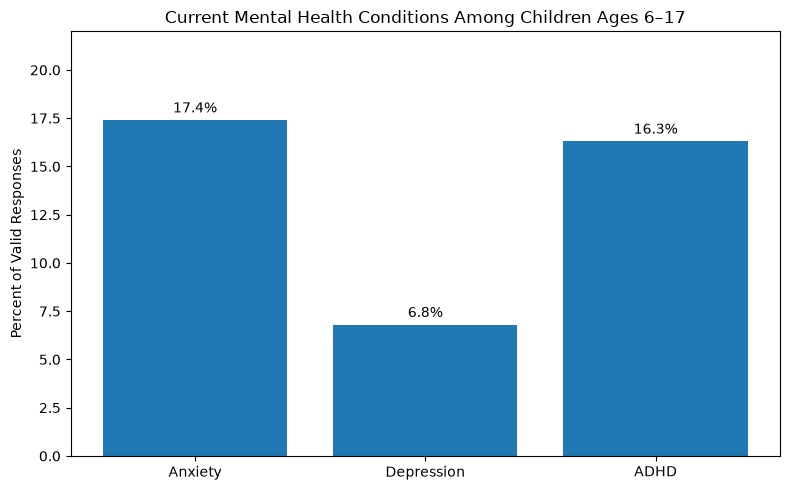

In [39]:
import matplotlib.pyplot as plt

condition_plot = pd.DataFrame({
    "Condition": ["Anxiety", "Depression", "ADHD"],
    "Percent": [17.4, 6.8, 16.3]
})

plt.figure(figsize=(8, 5))

bars = plt.bar(
    condition_plot["Condition"],
    condition_plot["Percent"]
)

plt.title("Current Mental Health Conditions Among Children Ages 6–17")
plt.ylabel("Percent of Valid Responses")
plt.xlabel("")

for bar, value in zip(bars, condition_plot["Percent"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f"{value:.1f}%",
        ha="center"
    )

plt.ylim(0, 22)
plt.tight_layout()
plt.show()

### Three Conditions Finding

Among the three conditions included in the target population, current anxiety was the most common at 17.4%, followed closely by ADHD at 16.3%. Current depression was reported for 6.8% of valid responses.

These unweighted percentages describe the cleaned NSCH sample and should not be interpreted as national prevalence estimates.

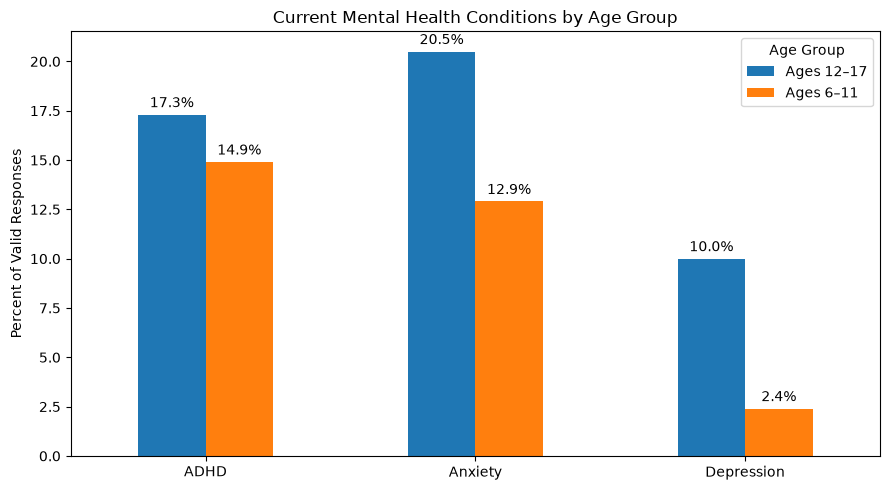

In [43]:
age_condition_plot = pd.DataFrame({
    "Condition": [
        "Anxiety", "Depression", "ADHD",
        "Anxiety", "Depression", "ADHD"
    ],
    "Age Group": [
        "Ages 6–11", "Ages 6–11", "Ages 6–11",
        "Ages 12–17", "Ages 12–17", "Ages 12–17"
    ],
    "Percent": [
        12.9, 2.4, 14.9,
        20.5, 10.0, 17.3
    ]
})

pivot_age = age_condition_plot.pivot(
    index="Condition",
    columns="Age Group",
    values="Percent"
)

ax = pivot_age.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Current Mental Health Conditions by Age Group")
plt.ylabel("Percent of Valid Responses")
plt.xlabel("")
plt.xticks(rotation=0)
plt.legend(title="Age Group")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

### Finding: Mental Health Conditions by Age Group

The condition profile changes substantially with age.

Among children ages 6–11, ADHD was the most common of the three conditions at 14.9%, compared with 12.9% for anxiety and 2.4% for depression.

Among adolescents ages 12–17, anxiety increased to 20.5% and became the most common condition. Depression also increased substantially to 10.0%, while ADHD increased more modestly to 17.3%.

This suggests that age is particularly important for understanding the distribution of anxiety and depression, even though later analyses found age to have a relatively weak association with unmet care.

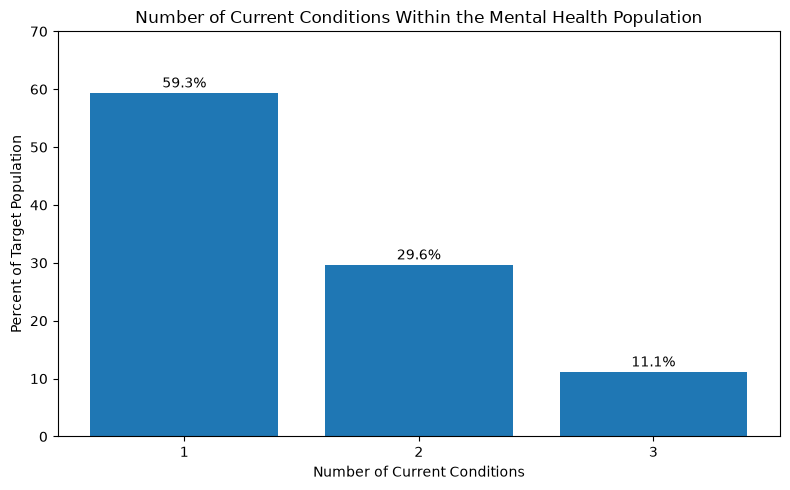

In [41]:
comorbidity_plot = (
    target_population["current_condition_count"]
    .value_counts()
    .sort_index()
    .reset_index()
)

comorbidity_plot.columns = [
    "Number of Conditions",
    "Children"
]

comorbidity_plot["Percent"] = (
    comorbidity_plot["Children"]
    / comorbidity_plot["Children"].sum()
    * 100
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    comorbidity_plot["Number of Conditions"].astype(str),
    comorbidity_plot["Percent"]
)

plt.title("Number of Current Conditions Within the Mental Health Population")
plt.xlabel("Number of Current Conditions")
plt.ylabel("Percent of Target Population")

for bar, value in zip(
    bars,
    comorbidity_plot["Percent"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.ylim(0, 70)
plt.tight_layout()
plt.show()

### Comorbidity Finding

Comorbidity was common among children with current anxiety, depression, or ADHD.

Approximately 59.3% had one of the three conditions, 29.6% had two, and 11.1% had all three.

Together, 40.7% of the target mental health population had two or more current conditions, showing that a substantial share of children in this population experience overlapping mental health needs.

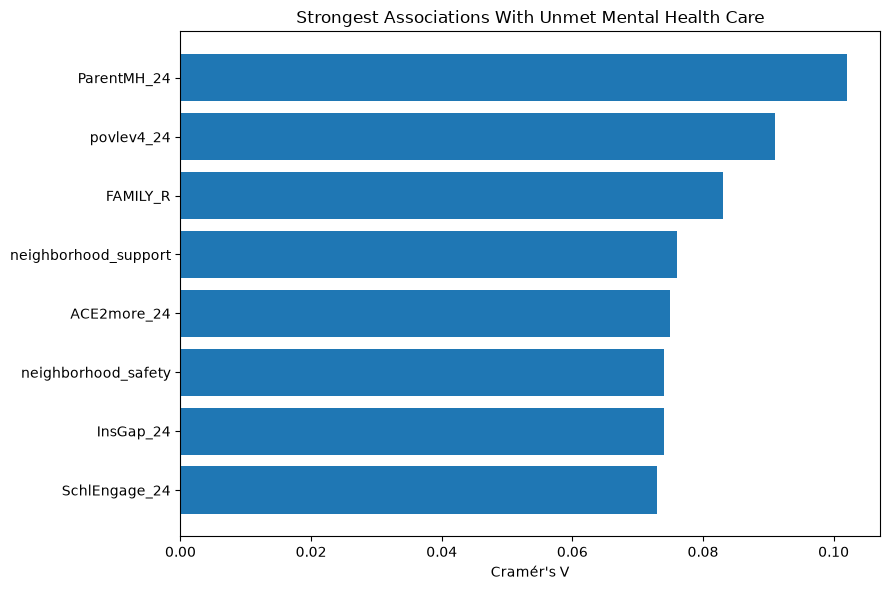

In [42]:
top_associations = (
    nsch_chi_square
    if "nsch_chi_square" in globals()
    else chi_square_df
)

top_associations = (
    top_associations
    .sort_values("Cramer's V", ascending=False)
    .head(8)
    .sort_values("Cramer's V")
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_associations["Factor"],
    top_associations["Cramer's V"]
)

plt.title("Strongest Associations With Unmet Mental Health Care")
plt.xlabel("Cramér's V")
plt.ylabel("")

plt.tight_layout()
plt.show()

### Bivariate Finding

The strongest bivariate associations with unmet mental health care were concentrated in family, socioeconomic, insurance, school, and neighborhood conditions.

Parent mental health showed the largest Cramér's V, followed by poverty level, family factors, neighborhood support, ACE exposure, insurance gaps, neighborhood safety, and school engagement.

Although these relationships were statistically significant, the effect sizes were generally small. This suggests that unmet mental health care is associated with multiple overlapping conditions rather than one dominant risk factor.

In [46]:
import nbformat as nbf
from pathlib import Path

# ---------------------------------------------------------
# Paths
# ---------------------------------------------------------

master_path = Path(
    "../Final_Data_Analysis/07_full_project_analysis.ipynb"
)

nb = nbf.read(master_path, as_version=4)

# ---------------------------------------------------------
# New NSCH EDA cells
# ---------------------------------------------------------

new_cells = []

new_cells.append(nbf.v4.new_markdown_cell("""
## 2.9 Exploratory Data Analysis Visualizations

The following visualizations summarize the major distributions and relationships identified during the NSCH analysis. These plots focus on mental health prevalence, age differences, comorbidity, and factors associated with unmet mental health care.
"""))

# 1. Prevalence chart
new_cells.append(nbf.v4.new_code_cell("""
import matplotlib.pyplot as plt

condition_plot = pd.DataFrame({
    "Condition": ["Anxiety", "Depression", "ADHD"],
    "Percent": [17.4, 6.8, 16.3]
})

plt.figure(figsize=(8, 5))

bars = plt.bar(
    condition_plot["Condition"],
    condition_plot["Percent"]
)

plt.title("Current Mental Health Conditions Among Children Ages 6–17")
plt.ylabel("Percent of Valid Responses")
plt.xlabel("")

for bar, value in zip(bars, condition_plot["Percent"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f"{value:.1f}%",
        ha="center"
    )

plt.ylim(0, 22)
plt.tight_layout()
plt.show()
"""))

new_cells.append(nbf.v4.new_markdown_cell("""
### Finding: Current Condition Prevalence

Among the three conditions included in the target population, current anxiety was the most common at 17.4%, followed closely by ADHD at 16.3%. Current depression was reported for 6.8% of valid responses.

These unweighted percentages describe the cleaned NSCH sample and should not be interpreted as national prevalence estimates.
"""))

# 2. Age group chart
new_cells.append(nbf.v4.new_code_cell("""
age_condition_plot = pd.DataFrame({
    "Condition": [
        "Anxiety", "Depression", "ADHD",
        "Anxiety", "Depression", "ADHD"
    ],
    "Age Group": [
        "Ages 6–11", "Ages 6–11", "Ages 6–11",
        "Ages 12–17", "Ages 12–17", "Ages 12–17"
    ],
    "Percent": [
        12.9, 2.4, 14.9,
        20.5, 10.0, 17.3
    ]
})

pivot_age = age_condition_plot.pivot(
    index="Condition",
    columns="Age Group",
    values="Percent"
)

ax = pivot_age.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Current Mental Health Conditions by Age Group")
plt.ylabel("Percent of Valid Responses")
plt.xlabel("")
plt.xticks(rotation=0)
plt.legend(title="Age Group")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()
plt.show()
"""))

new_cells.append(nbf.v4.new_markdown_cell("""
### Finding: Mental Health Conditions by Age Group

Among children ages 6–11, ADHD was the most common of the three conditions at 14.9%, compared with 12.9% for anxiety and 2.4% for depression.

Among adolescents ages 12–17, anxiety increased to 20.5% and became the most common condition. Depression also increased substantially to 10.0%, while ADHD increased more modestly to 17.3%.

Age is therefore particularly important for understanding the distribution of anxiety and depression, even though later analyses found age to have a relatively weak association with unmet care.
"""))

# 3. Comorbidity chart
new_cells.append(nbf.v4.new_code_cell("""
comorbidity_plot = (
    target_population["current_condition_count"]
    .value_counts()
    .sort_index()
    .reset_index()
)

comorbidity_plot.columns = [
    "Number of Conditions",
    "Children"
]

comorbidity_plot["Percent"] = (
    comorbidity_plot["Children"]
    / comorbidity_plot["Children"].sum()
    * 100
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    comorbidity_plot["Number of Conditions"].astype(str),
    comorbidity_plot["Percent"]
)

plt.title("Number of Current Conditions Within the Mental Health Population")
plt.xlabel("Number of Current Conditions")
plt.ylabel("Percent of Target Population")

for bar, value in zip(
    bars,
    comorbidity_plot["Percent"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.ylim(0, 70)
plt.tight_layout()
plt.show()
"""))

new_cells.append(nbf.v4.new_markdown_cell("""
### Finding: Comorbidity

Comorbidity was common among children with current anxiety, depression, or ADHD.

Approximately 59.3% had one of the three conditions, 29.6% had two, and 11.1% had all three.

Together, 40.7% of the target mental health population had two or more current conditions.
"""))

# 4. Strongest associations chart
new_cells.append(nbf.v4.new_code_cell("""
top_associations = (
    nsch_chi_square
    .sort_values("Cramer's V", ascending=False)
    .head(8)
    .sort_values("Cramer's V")
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_associations["Factor"],
    top_associations["Cramer's V"]
)

plt.title("Strongest Associations With Unmet Mental Health Care")
plt.xlabel("Cramér's V")
plt.ylabel("")

plt.tight_layout()
plt.show()
"""))

new_cells.append(nbf.v4.new_markdown_cell("""
### Finding: Strongest Associations With Unmet Care

The strongest bivariate associations with unmet mental health care were concentrated in family, socioeconomic, insurance, school, and neighborhood conditions.

Parent mental health showed the largest Cramér's V, followed by poverty level, family factors, neighborhood support, ACE exposure, insurance gaps, neighborhood safety, and school engagement.

Although these relationships were statistically significant, effect sizes were generally small, suggesting that unmet mental health care is associated with multiple overlapping conditions rather than one dominant risk factor.
"""))

# ---------------------------------------------------------
# Find where ACS section begins
# ---------------------------------------------------------

insert_index = None

for i, cell in enumerate(nb.cells):
    if (
        cell.cell_type == "markdown"
        and "# 3. American Community Survey" in cell.source
    ):
        insert_index = i
        break

if insert_index is None:
    raise ValueError("Could not find ACS section in master notebook.")

# ---------------------------------------------------------
# Insert NSCH EDA right before ACS
# ---------------------------------------------------------

nb.cells[insert_index:insert_index] = new_cells

# ---------------------------------------------------------
# Save updated master notebook
# ---------------------------------------------------------

nbf.write(nb, master_path)

print("Updated:", master_path.resolve())
print("Inserted", len(new_cells), "NSCH EDA cells.")

ValueError: Could not find ACS section in master notebook.

# ACS Community Context Analysis

**Dataset:** American Community Survey (ACS)  
**Year:** 2024 5-Year Estimates  
**Source:** U.S. Census Bureau  

## Research Role

The ACS adds socioeconomic, household, housing, and demographic context to the pediatric mental health access analysis.

Unlike the NSCH, the ACS does not measure individual children's mental health or whether a specific child received needed care. Instead, it helps identify communities where structural conditions may overlap with the family and socioeconomic risk factors identified in the NSCH analysis.

## Analysis Questions

1. Which states and school districts show the greatest concentration of socioeconomic and household vulnerability?
2. Which ACS indicators align most closely with the risk domains identified in NSCH, particularly poverty, insurance, family conditions, housing, and access to basic resources?
3. Which communities show multiple overlapping vulnerability indicators?
4. Which ACS findings should be carried forward into the cross-dataset community-risk analysis?

In [1]:
import pandas as pd
from pathlib import Path

data_path = Path(
    "../../data/cleaned/ACS_2024_cleaned_state_district.csv"
)

acs = pd.read_csv(data_path)

print("Dataset shape:", acs.shape)
acs.head()

Dataset shape: (10953, 176)


,GEO_ID,NAME,DP02_0003E,DP02_0003PE,DP02_0003PM,DP02_0005E,DP02_0005PE,DP02_0005PM,DP02_0007E,DP02_0007PE,...,DP05_0075E,DP05_0075PE,DP05_0075PM,DP05_0090E,DP05_0090PE,DP05_0090PM,DP05_0095E,DP05_0095PE,DP05_0095PM,FIPSST
0,0400000US01,Alabama,325534.0,16.3,0.2,35399.0,1.8,0.1,20605.0,1.0,...,270559,5.3,0.1,284135,5.6,0.1,4802633,94.4,0.1,1
1,0400000US02,Alaska,53341.0,19.7,0.5,8142.0,3.0,0.2,4333.0,1.6,...,99890,13.6,0.5,53803,7.3,0.1,681903,92.7,0.1,2
2,0400000US04,Arizona,477403.0,16.7,0.2,77389.0,2.7,0.1,38148.0,1.3,...,1441985,19.5,0.2,2313806,31.4,*****,5065032,68.6,*****,4
3,0400000US05,Arkansas,213116.0,17.7,0.3,26327.0,2.2,0.1,16104.0,1.3,...,315183,10.3,0.2,275571,9.0,0.1,2773820,91.0,0.1,5
4,0400000US06,California,2703186.0,20.0,0.1,360079.0,2.7,0.1,168186.0,1.2,...,7536798,19.2,0.1,15778963,40.2,*****,23508414,59.8,*****,6


In [2]:
# Identify ACS geographic level from GEO_ID

acs["geography_level"] = acs["GEO_ID"].astype(str).apply(
    lambda x: "State" if "0400000US" in x else
              "School District" if "9700000US" in x else
              "Other"
)

print(acs["geography_level"].value_counts())

geography_level
School District    10901
State                 52
Name: count, dtype: int64


## Geographic Scope

The cleaned ACS dataset contains both state-level and school-district-level records.

- 52 state-level records
- 10,901 school-district-level records

State-level data will be used to establish broad geographic context, while school-district-level data will provide the primary community-level detail for identifying areas with overlapping socioeconomic and household vulnerability.

In [3]:
# Show retained ACS variables by profile

profile_counts = {
    "DP02 - Social Characteristics": sum(col.startswith("DP02") for col in acs.columns),
    "DP03 - Economic Characteristics": sum(col.startswith("DP03") for col in acs.columns),
    "DP04 - Housing Characteristics": sum(col.startswith("DP04") for col in acs.columns),
    "DP05 - Demographic Characteristics": sum(col.startswith("DP05") for col in acs.columns)
}

pd.Series(profile_counts, name="Number of Columns")

DP02 - Social Characteristics         48
DP03 - Economic Characteristics       31
DP04 - Housing Characteristics        44
DP05 - Demographic Characteristics    47
Name: Number of Columns, dtype: int64

In [4]:
# Show the percentage variables retained from each ACS profile

for profile in ["DP02", "DP03", "DP04", "DP05"]:
    print(f"\n{profile} percentage variables:")
    
    cols = [
        col for col in acs.columns
        if col.startswith(profile) and col.endswith("PE")
    ]
    
    print(cols)


DP02 percentage variables:
['DP02_0003PE', 'DP02_0005PE', 'DP02_0007PE', 'DP02_0011PE', 'DP02_0014PE', 'DP02_0056PE', 'DP02_0057PE', 'DP02_0067PE', 'DP02_0068PE', 'DP02_0073PE', 'DP02_0074PE', 'DP02_0113PE', 'DP02_0114PE', 'DP02_0115PE', 'DP02_0153PE', 'DP02_0154PE']

DP03 percentage variables:
['DP03_0016PE', 'DP03_0017PE', 'DP03_0072PE', 'DP03_0074PE', 'DP03_0100PE', 'DP03_0101PE', 'DP03_0120PE', 'DP03_0129PE', 'DP03_0132PE']

DP04 percentage variables:
['DP04_0046PE', 'DP04_0047PE', 'DP04_0058PE', 'DP04_0059PE', 'DP04_0060PE', 'DP04_0061PE', 'DP04_0073PE', 'DP04_0074PE', 'DP04_0078PE', 'DP04_0079PE', 'DP04_0114PE', 'DP04_0115PE', 'DP04_0141PE', 'DP04_0142PE']

DP05 percentage variables:
['DP05_0002PE', 'DP05_0003PE', 'DP05_0006PE', 'DP05_0007PE', 'DP05_0008PE', 'DP05_0019PE', 'DP05_0037PE', 'DP05_0045PE', 'DP05_0053PE', 'DP05_0061PE', 'DP05_0069PE', 'DP05_0074PE', 'DP05_0075PE', 'DP05_0090PE', 'DP05_0095PE']


## Focused Community Vulnerability Indicators

The ACS contains a much broader set of social, economic, housing, and demographic measures than is needed for this analysis.

Based on the NSCH findings and the project research questions, the ACS analysis will focus on community-level indicators related to:

- child poverty
- health insurance access
- household and caregiver structure
- economic strain
- housing burden
- transportation access
- broadband access
- language access

These measures do not identify whether an individual child has an unmet mental health need. Instead, they provide community-level context that can be combined later with school-resource and provider-shortage data.

In [5]:
# Create focused ACS community indicators

acs_indicators = acs[
    [
        "GEO_ID",
        "NAME",
        "FIPSST",
        "geography_level",

        # Family / household context
        "DP02_0011PE",

        # Language access
        "DP02_0115PE",

        # Digital access
        "DP02_0154PE",

        # Economic / insurance
        "DP03_0074PE",
        "DP03_0101PE",
        "DP03_0129PE",
        "DP03_0132PE",

        # Housing
        "DP04_0047PE",
        "DP04_0115PE",
        "DP04_0142PE",

        # Transportation
        "pct_has_vehicle"
    ]
].copy()

acs_indicators = acs_indicators.rename(
    columns={
        "DP02_0011PE": "female_householder_with_children_pct",
        "DP02_0115PE": "limited_english_pct",
        "DP02_0154PE": "broadband_access_pct",

        "DP03_0074PE": "snap_households_pct",
        "DP03_0101PE": "uninsured_under19_pct",
        "DP03_0129PE": "child_poverty_under18_pct",
        "DP03_0132PE": "child_poverty_age5_17_pct",

        "DP04_0047PE": "renter_occupied_pct",
        "DP04_0115PE": "owner_cost_burden_35plus_pct",
        "DP04_0142PE": "rent_burden_35plus_pct"
    }
)

acs_indicators.head()

,GEO_ID,NAME,FIPSST,geography_level,female_householder_with_children_pct,limited_english_pct,broadband_access_pct,snap_households_pct,uninsured_under19_pct,child_poverty_under18_pct,child_poverty_age5_17_pct,renter_occupied_pct,owner_cost_burden_35plus_pct,rent_burden_35plus_pct,pct_has_vehicle
0,0400000US01,Alabama,1,State,6.0,2.4,87.5,13.7,3.6,21.3,19.9,29.8,18.2,39.9,94.6
1,0400000US02,Alaska,2,State,4.0,4.2,91.9,10.1,8.0,12.2,10.6,33.2,21.1,35.1,91.0
2,0400000US04,Arizona,4,State,4.4,8.0,91.5,10.4,8.8,16.2,15.3,32.6,21.1,42.2,94.6
3,0400000US05,Arkansas,5,State,5.6,3.4,86.7,10.2,6.0,21.1,19.5,33.6,16.9,35.9,94.1
4,0400000US06,California,6,State,4.5,17.5,93.5,12.4,3.2,15.0,14.7,44.1,30.0,46.0,92.9


In [6]:
# Check data types and missing values for focused indicators

indicator_cols = [
    "female_householder_with_children_pct",
    "limited_english_pct",
    "broadband_access_pct",
    "snap_households_pct",
    "uninsured_under19_pct",
    "child_poverty_under18_pct",
    "child_poverty_age5_17_pct",
    "renter_occupied_pct",
    "owner_cost_burden_35plus_pct",
    "rent_burden_35plus_pct",
    "pct_has_vehicle"
]

for col in indicator_cols:
    acs_indicators[col] = pd.to_numeric(
        acs_indicators[col],
        errors="coerce"
    )

summary = pd.DataFrame({
    "Missing": acs_indicators[indicator_cols].isna().sum(),
    "Valid": acs_indicators[indicator_cols].notna().sum()
})

summary

,Missing,Valid
female_householder_with_children_pct,14,10939
limited_english_pct,14,10939
broadband_access_pct,14,10939
snap_households_pct,12,10941
uninsured_under19_pct,32,10921
child_poverty_under18_pct,36,10917
child_poverty_age5_17_pct,44,10909
renter_occupied_pct,12,10941
owner_cost_burden_35plus_pct,41,10912
rent_burden_35plus_pct,62,10891


## State-Level Community Vulnerability Baseline

State-level ACS records provide a broad baseline for comparing economic, household, insurance, housing, transportation, and digital-access conditions.

These state comparisons are not used to infer individual mental health outcomes. Instead, they establish broad geographic context before examining school-district-level variation.

In [7]:
# Separate state and district records

acs_states = acs_indicators[
    acs_indicators["geography_level"] == "State"
].copy()

acs_districts = acs_indicators[
    acs_indicators["geography_level"] == "School District"
].copy()

print("State records:", len(acs_states))
print("District records:", len(acs_districts))

State records: 52
District records: 10901


In [8]:
state_summary_cols = [
    "child_poverty_under18_pct",
    "uninsured_under19_pct",
    "snap_households_pct",
    "female_householder_with_children_pct",
    "limited_english_pct",
    "broadband_access_pct",
    "owner_cost_burden_35plus_pct",
    "rent_burden_35plus_pct",
    "pct_has_vehicle"
]

state_summary = (
    acs_states[state_summary_cols]
    .describe()
    .T[
        ["mean", "50%", "min", "max"]
    ]
    .rename(
        columns={
            "mean": "Mean",
            "50%": "Median",
            "min": "Minimum",
            "max": "Maximum"
        }
    )
    .round(1)
)

state_summary

,Mean,Median,Minimum,Maximum
child_poverty_under18_pct,16.2,15.0,7.9,54.9
uninsured_under19_pct,5.0,4.8,1.6,12.0
snap_households_pct,12.0,11.4,5.2,47.4
female_householder_with_children_pct,4.6,4.6,3.0,7.6
limited_english_pct,5.7,4.8,0.7,17.5
broadband_access_pct,90.4,90.7,84.1,93.6
owner_cost_burden_35plus_pct,20.3,20.1,14.6,31.7
rent_burden_35plus_pct,39.6,39.4,30.4,50.2
pct_has_vehicle,92.2,93.8,64.0,96.3


In [9]:
def top_states(indicator, n=10):
    return (
        acs_states[
            ["NAME", indicator]
        ]
        .dropna()
        .sort_values(
            indicator,
            ascending=False
        )
        .head(n)
        .reset_index(drop=True)
    )

print("Highest child poverty:")
display(
    top_states(
        "child_poverty_under18_pct"
    )
)

print("\nHighest uninsured rate under age 19:")
display(
    top_states(
        "uninsured_under19_pct"
    )
)

print("\nHighest SNAP household rate:")
display(
    top_states(
        "snap_households_pct"
    )
)

print("\nHighest rent burden:")
display(
    top_states(
        "rent_burden_35plus_pct"
    )
)

Highest child poverty:


,NAME,child_poverty_under18_pct
0,Puerto Rico,54.9
1,Mississippi,26.0
2,Louisiana,25.4
3,New Mexico,24.0
4,District of Columbia,22.8
5,West Virginia,21.5
6,Alabama,21.3
7,Arkansas,21.1
8,Kentucky,20.3
9,Oklahoma,20.1



Highest uninsured rate under age 19:


,NAME,uninsured_under19_pct
0,Texas,12.0
1,Wyoming,9.1
2,Arizona,8.8
3,Oklahoma,8.3
4,Nevada,8.0
5,Alaska,8.0
6,Florida,7.5
7,South Dakota,7.3
8,Montana,7.1
9,Georgia,6.9



Highest SNAP household rate:


,NAME,snap_households_pct
0,Puerto Rico,47.4
1,New Mexico,19.2
2,West Virginia,17.3
3,Louisiana,17.3
4,Oregon,16.0
5,New York,15.6
6,Massachusetts,14.7
7,Pennsylvania,14.4
8,District of Columbia,14.3
9,Oklahoma,14.1



Highest rent burden:


,NAME,rent_burden_35plus_pct
0,Florida,50.2
1,Nevada,46.4
2,Louisiana,46.3
3,Hawaii,46.2
4,California,46.0
5,Connecticut,43.5
6,Georgia,43.4
7,Oregon,43.1
8,New York,43.1
9,South Carolina,42.8


## District-Level Overlapping Vulnerability

State averages can conceal substantial differences between local communities. The school-district records are therefore used to identify areas where multiple socioeconomic and access-related vulnerabilities occur simultaneously.

Rather than treating any single ACS measure as a proxy for mental health need, this analysis identifies districts that fall into relatively high-risk ranges across several indicators.

A district receives one vulnerability flag for each of the following conditions:

- child poverty in the highest 25% of districts
- uninsured youth in the highest 25%
- SNAP participation in the highest 25%
- female-householder households with children in the highest 25%
- housing cost burden in the highest 25%
- limited English proficiency in the highest 25%
- broadband access in the lowest 25%
- vehicle access in the lowest 25%

The total number of flags is used as an exploratory measure of overlapping community vulnerability. It is not a validated clinical risk score.

In [10]:
# Create district-level vulnerability flags

district_risk = acs_districts.copy()

high_risk_indicators = [
    "child_poverty_under18_pct",
    "uninsured_under19_pct",
    "snap_households_pct",
    "female_householder_with_children_pct",
    "limited_english_pct",
    "rent_burden_35plus_pct"
]

low_access_indicators = [
    "broadband_access_pct",
    "pct_has_vehicle"
]

# Highest quartile = vulnerability
for col in high_risk_indicators:
    cutoff = district_risk[col].quantile(0.75)
    district_risk[f"{col}_flag"] = (
        district_risk[col] >= cutoff
    ).astype(int)

# Lowest quartile = vulnerability
for col in low_access_indicators:
    cutoff = district_risk[col].quantile(0.25)
    district_risk[f"{col}_flag"] = (
        district_risk[col] <= cutoff
    ).astype(int)

flag_cols = [
    col for col in district_risk.columns
    if col.endswith("_flag")
]

district_risk["vulnerability_flags"] = (
    district_risk[flag_cols].sum(axis=1)
)

district_risk["vulnerability_flags"].value_counts().sort_index()

vulnerability_flags
0    2479
1    2702
2    2085
3    1378
4     984
5     732
6     405
7     117
8      19
Name: count, dtype: int64

In [11]:
# Districts with the greatest number of overlapping vulnerability flags

top_vulnerable_districts = (
    district_risk[
        [
            "NAME",
            "FIPSST",
            "vulnerability_flags",
            "child_poverty_under18_pct",
            "uninsured_under19_pct",
            "snap_households_pct",
            "female_householder_with_children_pct",
            "limited_english_pct",
            "broadband_access_pct",
            "rent_burden_35plus_pct",
            "pct_has_vehicle"
        ]
    ]
    .sort_values(
        [
            "vulnerability_flags",
            "child_poverty_under18_pct"
        ],
        ascending=[False, False]
    )
    .head(25)
    .reset_index(drop=True)
)

top_vulnerable_districts

,NAME,FIPSST,vulnerability_flags,child_poverty_under18_pct,uninsured_under19_pct,snap_households_pct,female_householder_with_children_pct,limited_english_pct,broadband_access_pct,rent_burden_35plus_pct,pct_has_vehicle
0,"San Diego Independent School District, Texas",48,8,53.6,22.8,28.0,17.5,7.9,66.0,44.4,88.4
1,"West Oso Independent School District, Texas",48,8,53.5,10.3,29.9,9.4,6.6,72.5,62.5,87.6
2,"Alice Independent School District, Texas",48,8,49.9,12.8,25.8,15.0,9.3,73.8,60.6,91.7
3,"East Cleveland City School District, Ohio",39,8,49.1,7.7,44.3,10.5,4.7,76.2,50.3,68.2
4,"Santa Maria Independent School District, Texas",48,8,48.5,10.9,35.3,14.2,38.8,66.1,48.1,87.0
5,"Buckholts Independent School District, Texas",48,8,48.0,12.4,28.1,8.5,10.8,66.9,53.1,91.5
6,"Laredo Independent School District, Texas",48,8,47.3,14.6,36.4,13.2,50.5,76.8,46.8,85.7
7,"Roma Independent School District, Texas",48,8,45.5,15.7,47.8,14.5,38.9,73.5,51.2,87.3
8,San Benito Consolidated Independent School Dis...,48,8,44.1,15.8,30.2,10.5,24.7,80.8,44.5,92.8
9,"Mathis Independent School District, Texas",48,8,42.4,11.4,19.2,5.3,7.3,72.7,43.5,88.4


## District-Level Overlapping Vulnerability

State-level averages provide broad geographic context, but they can hide substantial variation between local communities.

The school-district records are therefore used to identify communities where several socioeconomic and access-related vulnerabilities occur at the same time.

This exploratory analysis uses relative district-level thresholds rather than treating any single ACS measure as a direct indicator of mental health need.

A district receives one vulnerability flag when it falls:

- in the highest 25% for child poverty
- in the highest 25% for uninsured youth
- in the highest 25% for SNAP participation
- in the highest 25% for female-householder households with children
- in the highest 25% for limited English proficiency
- in the highest 25% for rent burden
- in the lowest 25% for broadband access
- in the lowest 25% for vehicle access

The total number of flags represents overlapping community vulnerability. This is an exploratory contextual measure, not a validated clinical risk score.

In [12]:
# Create district-level vulnerability flags

district_risk = acs_districts.copy()

high_risk_indicators = [
    "child_poverty_under18_pct",
    "uninsured_under19_pct",
    "snap_households_pct",
    "female_householder_with_children_pct",
    "limited_english_pct",
    "rent_burden_35plus_pct"
]

low_access_indicators = [
    "broadband_access_pct",
    "pct_has_vehicle"
]

# Highest quartile = vulnerability
for col in high_risk_indicators:
    cutoff = district_risk[col].quantile(0.75)

    district_risk[f"{col}_flag"] = (
        district_risk[col] >= cutoff
    ).astype(int)

# Lowest quartile = vulnerability
for col in low_access_indicators:
    cutoff = district_risk[col].quantile(0.25)

    district_risk[f"{col}_flag"] = (
        district_risk[col] <= cutoff
    ).astype(int)

flag_cols = [
    col for col in district_risk.columns
    if col.endswith("_flag")
]

district_risk["vulnerability_flags"] = (
    district_risk[flag_cols].sum(axis=1)
)

flag_distribution = (
    district_risk["vulnerability_flags"]
    .value_counts()
    .sort_index()
    .rename_axis("Number of Vulnerability Flags")
    .reset_index(name="Districts")
)

flag_distribution["Percent of Districts"] = (
    flag_distribution["Districts"]
    / len(district_risk)
    * 100
).round(1)

flag_distribution

,Number of Vulnerability Flags,Districts,Percent of Districts
0,0,2479,22.7
1,1,2702,24.8
2,2,2085,19.1
3,3,1378,12.6
4,4,984,9.0
5,5,732,6.7
6,6,405,3.7
7,7,117,1.1
8,8,19,0.2


### Finding: Overlapping Community Vulnerability

Most school districts did not fall into the highest-risk range across many indicators at once, but substantial overlap was still present.

Approximately 21.6% of districts had four or more vulnerability flags, while about 5.0% had six or more.

Only 19 districts, approximately 0.2% of all districts, met the vulnerability threshold for all eight indicators.

This distribution suggests that community vulnerability is concentrated rather than evenly distributed across school districts. The vulnerability flag count is used as an exploratory way to identify communities where several socioeconomic and access-related pressures overlap.

In [13]:
# Examine districts with the greatest overlapping vulnerability

top_vulnerable_districts = (
    district_risk[
        [
            "NAME",
            "FIPSST",
            "vulnerability_flags",
            "child_poverty_under18_pct",
            "uninsured_under19_pct",
            "snap_households_pct",
            "female_householder_with_children_pct",
            "limited_english_pct",
            "broadband_access_pct",
            "rent_burden_35plus_pct",
            "pct_has_vehicle"
        ]
    ]
    .sort_values(
        [
            "vulnerability_flags",
            "child_poverty_under18_pct"
        ],
        ascending=[False, False]
    )
    .head(30)
    .reset_index(drop=True)
)

top_vulnerable_districts

,NAME,FIPSST,vulnerability_flags,child_poverty_under18_pct,uninsured_under19_pct,snap_households_pct,female_householder_with_children_pct,limited_english_pct,broadband_access_pct,rent_burden_35plus_pct,pct_has_vehicle
0,"San Diego Independent School District, Texas",48,8,53.6,22.8,28.0,17.5,7.9,66.0,44.4,88.4
1,"West Oso Independent School District, Texas",48,8,53.5,10.3,29.9,9.4,6.6,72.5,62.5,87.6
2,"Alice Independent School District, Texas",48,8,49.9,12.8,25.8,15.0,9.3,73.8,60.6,91.7
3,"East Cleveland City School District, Ohio",39,8,49.1,7.7,44.3,10.5,4.7,76.2,50.3,68.2
4,"Santa Maria Independent School District, Texas",48,8,48.5,10.9,35.3,14.2,38.8,66.1,48.1,87.0
5,"Buckholts Independent School District, Texas",48,8,48.0,12.4,28.1,8.5,10.8,66.9,53.1,91.5
6,"Laredo Independent School District, Texas",48,8,47.3,14.6,36.4,13.2,50.5,76.8,46.8,85.7
7,"Roma Independent School District, Texas",48,8,45.5,15.7,47.8,14.5,38.9,73.5,51.2,87.3
8,San Benito Consolidated Independent School Dis...,48,8,44.1,15.8,30.2,10.5,24.7,80.8,44.5,92.8
9,"Mathis Independent School District, Texas",48,8,42.4,11.4,19.2,5.3,7.3,72.7,43.5,88.4


In [14]:
# Add state/territory names from FIPS codes

state_fips_names = {
    1: "Alabama", 2: "Alaska", 4: "Arizona", 5: "Arkansas",
    6: "California", 8: "Colorado", 9: "Connecticut",
    10: "Delaware", 11: "District of Columbia", 12: "Florida",
    13: "Georgia", 15: "Hawaii", 16: "Idaho", 17: "Illinois",
    18: "Indiana", 19: "Iowa", 20: "Kansas", 21: "Kentucky",
    22: "Louisiana", 23: "Maine", 24: "Maryland",
    25: "Massachusetts", 26: "Michigan", 27: "Minnesota",
    28: "Mississippi", 29: "Missouri", 30: "Montana",
    31: "Nebraska", 32: "Nevada", 33: "New Hampshire",
    34: "New Jersey", 35: "New Mexico", 36: "New York",
    37: "North Carolina", 38: "North Dakota", 39: "Ohio",
    40: "Oklahoma", 41: "Oregon", 42: "Pennsylvania",
    44: "Rhode Island", 45: "South Carolina",
    46: "South Dakota", 47: "Tennessee", 48: "Texas",
    49: "Utah", 50: "Vermont", 51: "Virginia",
    53: "Washington", 54: "West Virginia", 55: "Wisconsin",
    56: "Wyoming", 72: "Puerto Rico"
}

top_vulnerable_districts["State/Territory"] = (
    top_vulnerable_districts["FIPSST"]
    .map(state_fips_names)
)

top_vulnerable_districts[
    [
        "NAME",
        "State/Territory",
        "vulnerability_flags",
        "child_poverty_under18_pct",
        "uninsured_under19_pct",
        "snap_households_pct",
        "broadband_access_pct",
        "rent_burden_35plus_pct",
        "pct_has_vehicle"
    ]
]

,NAME,State/Territory,vulnerability_flags,child_poverty_under18_pct,uninsured_under19_pct,snap_households_pct,broadband_access_pct,rent_burden_35plus_pct,pct_has_vehicle
0,"San Diego Independent School District, Texas",Texas,8,53.6,22.8,28.0,66.0,44.4,88.4
1,"West Oso Independent School District, Texas",Texas,8,53.5,10.3,29.9,72.5,62.5,87.6
2,"Alice Independent School District, Texas",Texas,8,49.9,12.8,25.8,73.8,60.6,91.7
3,"East Cleveland City School District, Ohio",Ohio,8,49.1,7.7,44.3,76.2,50.3,68.2
4,"Santa Maria Independent School District, Texas",Texas,8,48.5,10.9,35.3,66.1,48.1,87.0
5,"Buckholts Independent School District, Texas",Texas,8,48.0,12.4,28.1,66.9,53.1,91.5
6,"Laredo Independent School District, Texas",Texas,8,47.3,14.6,36.4,76.8,46.8,85.7
7,"Roma Independent School District, Texas",Texas,8,45.5,15.7,47.8,73.5,51.2,87.3
8,San Benito Consolidated Independent School Dis...,Texas,8,44.1,15.8,30.2,80.8,44.5,92.8
9,"Mathis Independent School District, Texas",Texas,8,42.4,11.4,19.2,72.7,43.5,88.4


## Exploratory Data Analysis: District Vulnerability

The following visualizations examine how vulnerability is distributed across school districts and how the underlying ACS indicators relate to one another.

Because the ACS indicators are continuous percentages, correlation analysis is appropriate for examining whether community-level socioeconomic and access conditions tend to occur together.

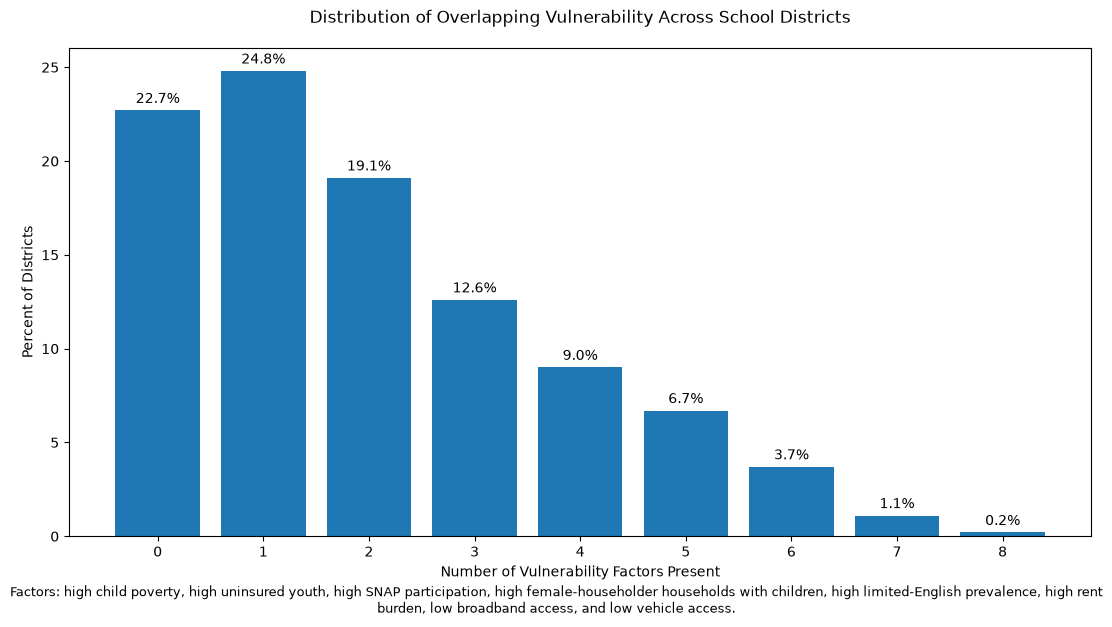

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 6))

bars = plt.bar(
    flag_distribution["Number of Vulnerability Flags"].astype(str),
    flag_distribution["Percent of Districts"]
)

plt.title(
    "Distribution of Overlapping Vulnerability Across School Districts",
    pad=18
)

plt.xlabel("Number of Vulnerability Factors Present")
plt.ylabel("Percent of Districts")

for bar, value in zip(
    bars,
    flag_distribution["Percent of Districts"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f"{value:.1f}%",
        ha="center"
    )

factor_note = (
    "Factors: high child poverty, high uninsured youth, high SNAP participation, "
    "high female-householder households with children, high limited-English prevalence, "
    "high rent burden, low broadband access, and low vehicle access."
)

plt.figtext(
    0.5,
    -0.03,
    factor_note,
    ha="center",
    wrap=True,
    fontsize=9
)

plt.tight_layout()
plt.show()

### Finding: Distribution of Overlapping Vulnerability

Nearly half of school districts had zero or one vulnerability flag, while approximately 21.6% had four or more.

A smaller group of districts showed especially concentrated vulnerability: approximately 5.0% had six or more flags, and 19 districts met all eight thresholds.

This indicates that socioeconomic and access-related vulnerability is unevenly distributed across school districts.

In [17]:
correlation_cols = [
    "child_poverty_under18_pct",
    "uninsured_under19_pct",
    "snap_households_pct",
    "female_householder_with_children_pct",
    "limited_english_pct",
    "broadband_access_pct",
    "rent_burden_35plus_pct",
    "pct_has_vehicle"
]

district_correlations = (
    district_risk[correlation_cols]
    .corr()
    .round(2)
)

district_correlations

,child_poverty_under18_pct,uninsured_under19_pct,snap_households_pct,female_householder_with_children_pct,limited_english_pct,broadband_access_pct,rent_burden_35plus_pct,pct_has_vehicle
child_poverty_under18_pct,1.00,0.14,0.64,0.45,0.12,-0.40,0.17,-0.34
uninsured_under19_pct,0.14,1.00,0.04,0.02,0.17,-0.26,-0.08,-0.12
snap_households_pct,0.64,0.04,1.00,0.51,0.17,-0.40,0.17,-0.47
female_householder_with_children_pct,0.45,0.02,0.51,1.00,0.24,-0.11,0.19,-0.29
limited_english_pct,0.12,0.17,0.17,0.24,1.00,0.05,0.14,-0.20
broadband_access_pct,-0.40,-0.26,-0.40,-0.11,0.05,1.00,0.11,0.25
rent_burden_35plus_pct,0.17,-0.08,0.17,0.19,0.14,0.11,1.00,-0.12
pct_has_vehicle,-0.34,-0.12,-0.47,-0.29,-0.20,0.25,-0.12,1.00


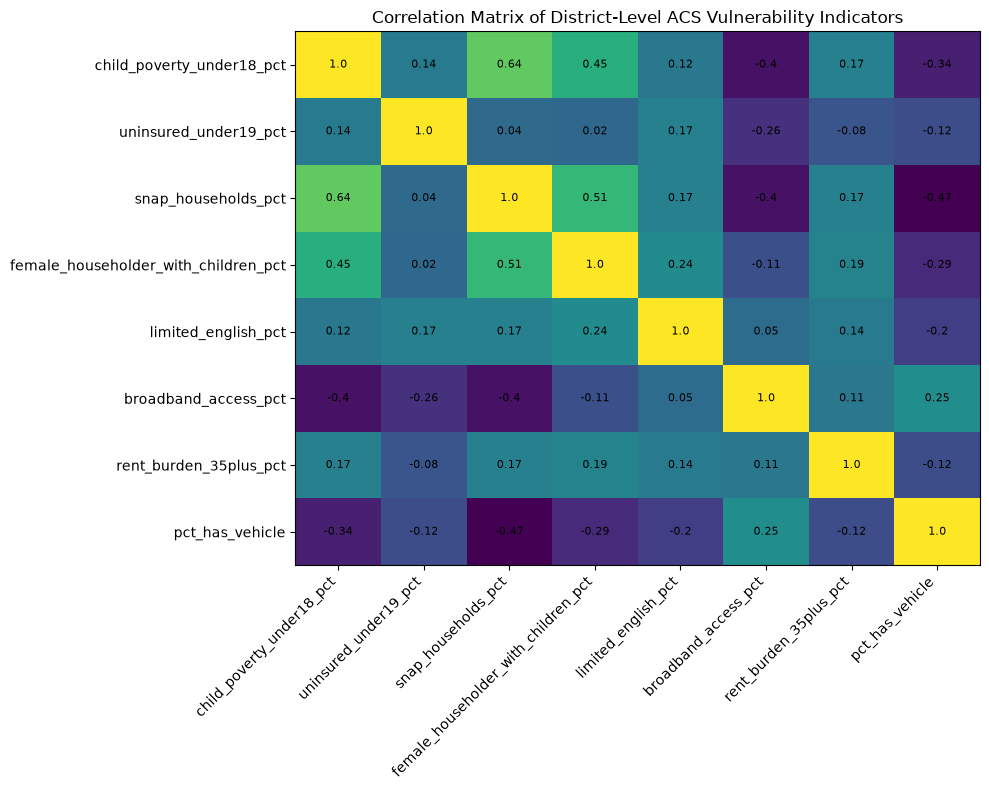

In [18]:
import numpy as np

fig, ax = plt.subplots(figsize=(10, 8))

matrix = ax.imshow(
    district_correlations,
    aspect="auto"
)

ax.set_xticks(
    np.arange(len(district_correlations.columns))
)

ax.set_yticks(
    np.arange(len(district_correlations.index))
)

ax.set_xticklabels(
    district_correlations.columns,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    district_correlations.index
)

for i in range(len(district_correlations.index)):
    for j in range(len(district_correlations.columns)):
        ax.text(
            j,
            i,
            district_correlations.iloc[i, j],
            ha="center",
            va="center",
            fontsize=8
        )

plt.title("Correlation Matrix of District-Level ACS Vulnerability Indicators")
plt.tight_layout()
plt.show()

### Finding: Relationships Between Community Vulnerability Indicators

The correlation analysis showed that several district-level socioeconomic vulnerability indicators tend to occur together.

The strongest positive relationship was between child poverty and SNAP participation (`r = 0.64`). SNAP participation was also moderately associated with female-householder households with children (`r = 0.51`), while child poverty was moderately associated with female-householder households with children (`r = 0.45`).

Access-related measures showed inverse relationships with economic vulnerability. SNAP participation was negatively correlated with vehicle access (`r = -0.47`), while both child poverty and SNAP participation were negatively correlated with broadband access (`r = -0.40`).

Most other relationships were weak, indicating that the indicators represent related but distinct dimensions of community vulnerability rather than a single underlying condition.

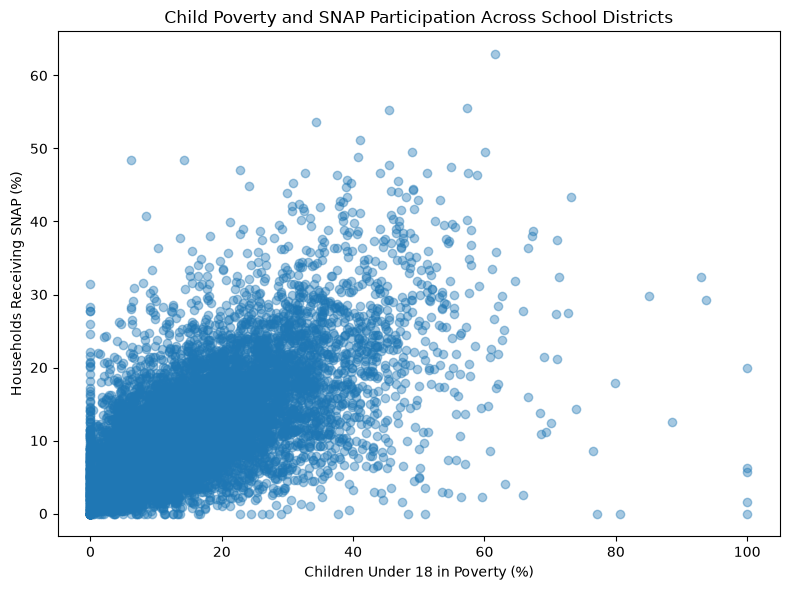

In [19]:
plt.figure(figsize=(8, 6))

plt.scatter(
    district_risk["child_poverty_under18_pct"],
    district_risk["snap_households_pct"],
    alpha=0.4
)

plt.title("Child Poverty and SNAP Participation Across School Districts")
plt.xlabel("Children Under 18 in Poverty (%)")
plt.ylabel("Households Receiving SNAP (%)")

plt.tight_layout()
plt.show()

### Finding: Child Poverty and SNAP Participation

School districts with higher child poverty rates generally also had higher rates of households receiving SNAP benefits.

The correlation between the two measures was `r = 0.64`, the strongest relationship among the ACS vulnerability indicators examined.

The relationship is substantial but not perfect, reinforcing the decision to examine multiple community indicators rather than using poverty alone to define vulnerability.

## Geographic Concentration of High-Vulnerability Districts

To identify where overlapping vulnerability is concentrated geographically, districts with four or more vulnerability flags are classified as high-vulnerability districts.

The analysis then calculates the percentage of districts within each state or territory that meet this threshold.

In [20]:
# Flag districts with 4 or more overlapping vulnerability factors

district_risk["high_vulnerability"] = (
    district_risk["vulnerability_flags"] >= 4
).astype(int)

# Add state/territory names

state_fips_names = {
    1: "Alabama", 2: "Alaska", 4: "Arizona", 5: "Arkansas",
    6: "California", 8: "Colorado", 9: "Connecticut",
    10: "Delaware", 11: "District of Columbia", 12: "Florida",
    13: "Georgia", 15: "Hawaii", 16: "Idaho", 17: "Illinois",
    18: "Indiana", 19: "Iowa", 20: "Kansas", 21: "Kentucky",
    22: "Louisiana", 23: "Maine", 24: "Maryland",
    25: "Massachusetts", 26: "Michigan", 27: "Minnesota",
    28: "Mississippi", 29: "Missouri", 30: "Montana",
    31: "Nebraska", 32: "Nevada", 33: "New Hampshire",
    34: "New Jersey", 35: "New Mexico", 36: "New York",
    37: "North Carolina", 38: "North Dakota", 39: "Ohio",
    40: "Oklahoma", 41: "Oregon", 42: "Pennsylvania",
    44: "Rhode Island", 45: "South Carolina",
    46: "South Dakota", 47: "Tennessee", 48: "Texas",
    49: "Utah", 50: "Vermont", 51: "Virginia",
    53: "Washington", 54: "West Virginia", 55: "Wisconsin",
    56: "Wyoming", 72: "Puerto Rico"
}

district_risk["State/Territory"] = (
    district_risk["FIPSST"].map(state_fips_names)
)

state_vulnerability = (
    district_risk
    .groupby("State/Territory", observed=False)
    .agg(
        Total_Districts=("high_vulnerability", "size"),
        High_Vulnerability_Districts=("high_vulnerability", "sum")
    )
    .reset_index()
)

state_vulnerability["Percent_High_Vulnerability"] = (
    state_vulnerability["High_Vulnerability_Districts"]
    / state_vulnerability["Total_Districts"]
    * 100
).round(1)

state_vulnerability = (
    state_vulnerability
    .sort_values(
        "Percent_High_Vulnerability",
        ascending=False
    )
    .reset_index(drop=True)
)

state_vulnerability.head(15)

,State/Territory,Total_Districts,High_Vulnerability_Districts,Percent_High_Vulnerability
0,District of Columbia,1,1,100.0
1,Louisiana,69,48,69.6
2,New Mexico,89,54,60.7
3,Mississippi,137,77,56.2
4,Georgia,182,98,53.8
5,Alaska,53,26,49.1
6,Alabama,141,59,41.8
7,South Carolina,74,30,40.5
8,North Carolina,118,44,37.3
9,Texas,1018,371,36.4


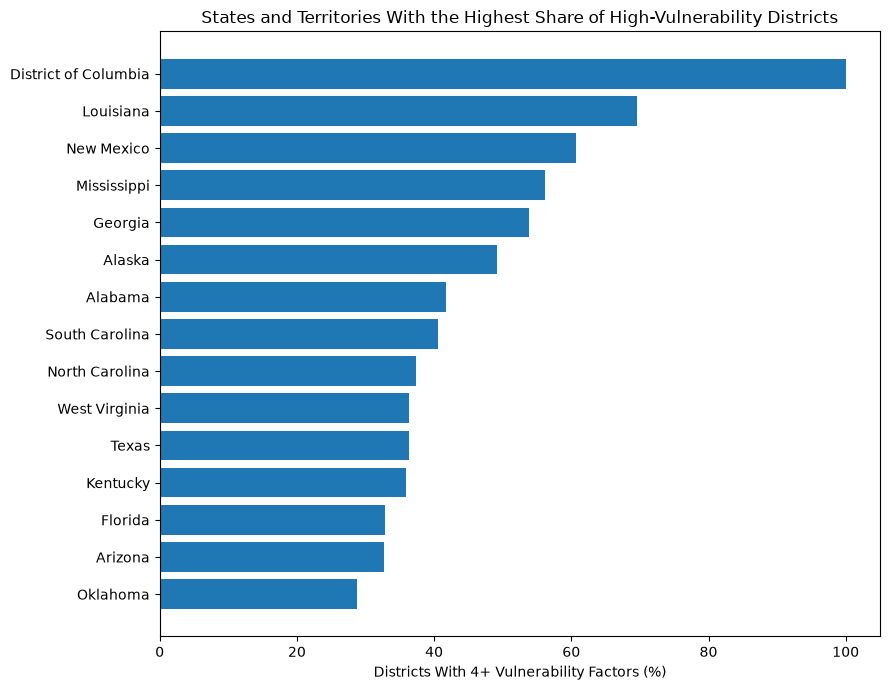

In [21]:
top_state_vulnerability = state_vulnerability.head(15).sort_values(
    "Percent_High_Vulnerability"
)

plt.figure(figsize=(9, 7))

plt.barh(
    top_state_vulnerability["State/Territory"],
    top_state_vulnerability["Percent_High_Vulnerability"]
)

plt.title(
    "States and Territories With the Highest Share of High-Vulnerability Districts"
)

plt.xlabel("Districts With 4+ Vulnerability Factors (%)")
plt.ylabel("")

plt.tight_layout()
plt.show()

### Finding: Geographic Concentration of High-Vulnerability Districts

High-vulnerability school districts were not distributed evenly across states.

Excluding the District of Columbia, which contains only one district in this analysis, Louisiana had the highest share of districts with four or more vulnerability factors at 69.6%. New Mexico followed at 60.7%, Mississippi at 56.2%, and Georgia at 53.8%.

Texas had a lower proportion of high-vulnerability districts at 36.4%, but because of its large number of districts, it contained 371 high-vulnerability districts, the largest count among the states shown.

These results illustrate why both the percentage and the absolute number of high-vulnerability districts are important when identifying communities for further analysis.

In [22]:
state_vulnerability[
    [
        "State/Territory",
        "Total_Districts",
        "High_Vulnerability_Districts",
        "Percent_High_Vulnerability"
    ]
].head(15)

,State/Territory,Total_Districts,High_Vulnerability_Districts,Percent_High_Vulnerability
0,District of Columbia,1,1,100.0
1,Louisiana,69,48,69.6
2,New Mexico,89,54,60.7
3,Mississippi,137,77,56.2
4,Georgia,182,98,53.8
5,Alaska,53,26,49.1
6,Alabama,141,59,41.8
7,South Carolina,74,30,40.5
8,North Carolina,118,44,37.3
9,Texas,1018,371,36.4


In [29]:
state_factor_summary_50 = (
    state_factor_summary[
        ~state_factor_summary["State/Territory"].isin(
            ["District of Columbia", "Puerto Rico"]
        )
    ]
    .copy()
)

state_factor_summary_50 = state_factor_summary_50.rename(
    columns={"State/Territory": "State"}
)

state_factor_summary_50.sort_values(
    "Factor 1 Districts (%)",
    ascending=False
).head(20)

,State,Top Factor 1,Factor 1 Districts (%),Top Factor 2,Factor 2 Districts (%),Top Factor 3,Factor 3 Districts (%)
11,Hawaii,Limited English,100.0,Rent burden,100.0,Low vehicle access,100.0
18,Louisiana,Female-householder families,87.0,SNAP participation,75.4,Child poverty,69.6
4,California,Limited English,85.8,Rent burden,56.6,SNAP participation,34.1
24,Mississippi,Female-householder families,83.2,Child poverty,72.3,Low broadband access,67.2
1,Alaska,Low vehicle access,83.0,Uninsured youth,56.6,Low broadband access,39.6
49,West Virginia,SNAP participation,78.2,Low vehicle access,65.5,Child poverty,50.9
31,New Mexico,SNAP participation,71.9,Limited English,64.0,Low broadband access,62.9
7,Delaware,Female-householder families,68.8,Limited English,56.2,SNAP participation,25.0
9,Florida,Rent burden,68.7,Limited English,49.3,Uninsured youth,47.8
30,New Jersey,Limited English,67.4,Rent burden,47.8,Low vehicle access,36.1


In [28]:
state_vulnerability_50 = (
    state_vulnerability[
        ~state_vulnerability["State/Territory"].isin(
            ["District of Columbia", "Puerto Rico"]
        )
    ]
    .copy()
)

state_vulnerability_50 = state_vulnerability_50.rename(
    columns={"State/Territory": "State"}
)

state_vulnerability_50.head(15)

,State,Total_Districts,High_Vulnerability_Districts,Percent_High_Vulnerability
1,Louisiana,69,48,69.6
2,New Mexico,89,54,60.7
3,Mississippi,137,77,56.2
4,Georgia,182,98,53.8
5,Alaska,53,26,49.1
6,Alabama,141,59,41.8
7,South Carolina,74,30,40.5
8,North Carolina,118,44,37.3
9,Texas,1018,371,36.4
10,West Virginia,55,20,36.4


In [30]:
state_profile_final = (
    state_vulnerability_50
    .merge(
        state_factor_summary_50,
        on="State",
        how="left"
    )
    .sort_values(
        "Percent_High_Vulnerability",
        ascending=False
    )
)

state_profile_final[
    [
        "State",
        "Total_Districts",
        "High_Vulnerability_Districts",
        "Percent_High_Vulnerability",
        "Top Factor 1",
        "Factor 1 Districts (%)",
        "Top Factor 2",
        "Factor 2 Districts (%)",
        "Top Factor 3",
        "Factor 3 Districts (%)"
    ]
].head(20)

,State,Total_Districts,High_Vulnerability_Districts,Percent_High_Vulnerability,Top Factor 1,Factor 1 Districts (%),Top Factor 2,Factor 2 Districts (%),Top Factor 3,Factor 3 Districts (%)
0,Louisiana,69,48,69.6,Female-householder families,87.0,SNAP participation,75.4,Child poverty,69.6
1,New Mexico,89,54,60.7,SNAP participation,71.9,Limited English,64.0,Low broadband access,62.9
2,Mississippi,137,77,56.2,Female-householder families,83.2,Child poverty,72.3,Low broadband access,67.2
3,Georgia,182,98,53.8,Female-householder families,64.3,Child poverty,55.5,SNAP participation,54.9
4,Alaska,53,26,49.1,Low vehicle access,83.0,Uninsured youth,56.6,Low broadband access,39.6
5,Alabama,141,59,41.8,Female-householder families,58.9,Child poverty,56.0,SNAP participation,51.1
6,South Carolina,74,30,40.5,Female-householder families,60.8,Child poverty,54.1,Low broadband access,41.9
7,North Carolina,118,44,37.3,Female-householder families,52.5,SNAP participation,49.2,Child poverty,44.1
8,Texas,1018,371,36.4,Uninsured youth,67.2,Limited English,56.1,Female-householder families,40.7
9,West Virginia,55,20,36.4,SNAP participation,78.2,Low vehicle access,65.5,Child poverty,50.9


## ACS Analysis Summary

The ACS analysis adds community-level socioeconomic, household, housing, transportation, and digital-access context to the pediatric mental health access project.

### State-Level Context

State-level comparisons showed substantial variation in child poverty, youth uninsurance, SNAP participation, household structure, housing burden, broadband access, and transportation access.

Several states repeatedly appeared near the top of different vulnerability measures, including Louisiana, New Mexico, Mississippi, Texas, Oklahoma, and West Virginia. These patterns suggest that community disadvantage is multidimensional and cannot be represented adequately by any single indicator.

### District-Level Overlapping Vulnerability

School-district analysis identified substantial overlap across eight community vulnerability indicators:

- child poverty
- uninsured youth
- SNAP participation
- female-headed households with children
- limited English prevalence
- rent burden
- low broadband access
- low vehicle access

Approximately 21.6% of school districts had four or more vulnerability factors, while about 5.0% had six or more. Nineteen districts met all eight vulnerability thresholds.

This exploratory flag count is not a clinical risk score. It is used to identify communities where several socioeconomic and access-related pressures occur simultaneously.

### Statistical Relationships

Correlation analysis showed that several economic vulnerability measures cluster together.

The strongest relationship was between child poverty and SNAP participation (`r = 0.64`). SNAP participation was also moderately associated with female-headed households with children (`r = 0.51`), while child poverty was moderately associated with female-headed households with children (`r = 0.45`).

Higher levels of economic vulnerability were also associated with lower access to resources. SNAP participation was negatively correlated with vehicle access (`r = -0.47`), while both child poverty and SNAP participation were negatively correlated with broadband access (`r = -0.40`).

These relationships support the use of multiple community indicators rather than relying on poverty alone.

### Geographic Concentration

For the formal state-level comparison, the analysis focuses on the 50 U.S. states.

Louisiana had the highest share of districts with four or more vulnerability factors at 69.6%. New Mexico followed at 60.7%, Mississippi at 56.2%, Georgia at 53.8%, and Alaska at 49.1%.

Texas had a lower proportion of high-vulnerability districts at 36.4%, but contained 371 such districts, the largest absolute number among the states examined.

This distinction between percentage and count is important when identifying where community vulnerability is both concentrated and widespread.

### State Vulnerability Profiles

The factors contributing to high community vulnerability differed substantially across states.

Among the states with the highest concentration of high-vulnerability districts:

- **Louisiana:** female-headed households with children, SNAP participation, and child poverty were the most widespread vulnerability factors.
- **New Mexico:** SNAP participation, limited English prevalence, and low broadband access were most prominent.
- **Mississippi:** female-headed households with children, child poverty, and low broadband access were most prominent.
- **Georgia:** female-headed households with children, child poverty, and SNAP participation were most prominent.
- **Alaska:** low vehicle access, uninsured youth, and low broadband access were most prominent.
- **Texas:** uninsured youth, limited English prevalence, and female-headed households with children were especially common.

Here, **female-headed households with children** refers to the ACS measure for a female householder with no spouse or partner present and children under age 18. It is used as a household-structure indicator rather than as a direct measure of individual family risk.

These state profiles show that communities with similar levels of overall vulnerability may face very different combinations of barriers. This reinforces the need to examine both the concentration and composition of vulnerability when identifying intervention opportunities.

### Interpretation

The ACS findings complement the NSCH results by showing that family and socioeconomic risk factors associated with unmet mental health care also occur within broader community environments marked by poverty, insurance gaps, household structure, housing burden, transportation limitations, and reduced digital access.

The ACS cannot establish whether an individual child has an unmet mental health need. Instead, it identifies geographic contexts where multiple structural pressures may increase barriers to accessing care.

The findings also suggest that intervention needs may differ by geography. For example, communities where uninsured youth are prominent may require different strategies than communities where broadband limitations, transportation barriers, or economic hardship are the dominant pressures.

In [1]:
import nbformat as nbf
from pathlib import Path

# ---------------------------------------------------------
# Paths
# ---------------------------------------------------------

acs_path = Path("02_acs_data_analysis.ipynb")

master_path = Path(
    "../Final_Data_Analysis/07_full_project_analysis.ipynb"
)

# ---------------------------------------------------------
# Read both notebooks
# ---------------------------------------------------------

acs_nb = nbf.read(acs_path, as_version=4)
master_nb = nbf.read(master_path, as_version=4)

# ---------------------------------------------------------
# Find ACS section in master notebook
# ---------------------------------------------------------

acs_start = None
acs_end = None

for i, cell in enumerate(master_nb.cells):

    if (
        cell.cell_type == "markdown"
        and "# 3. American Community Survey" in cell.source
    ):
        acs_start = i

    if (
        acs_start is not None
        and cell.cell_type == "markdown"
        and "# 4. NCES Fiscal" in cell.source
    ):
        acs_end = i
        break

if acs_start is None:
    raise ValueError("Could not find the ACS section in the master notebook.")

if acs_end is None:
    raise ValueError("Could not find the NCES Fiscal section in the master notebook.")

# ---------------------------------------------------------
# Use finished ACS notebook cells
#
# Skip the standalone ACS title because the master notebook
# already has its own ACS section heading.
# ---------------------------------------------------------

acs_cells = acs_nb.cells[1:]

# ---------------------------------------------------------
# Replace old ACS placeholder/content
# Keep the master ACS heading itself.
# ---------------------------------------------------------

master_nb.cells[
    acs_start + 1 : acs_end
] = acs_cells

# ---------------------------------------------------------
# Save
# ---------------------------------------------------------

nbf.write(master_nb, master_path)

print("ACS ported successfully.")
print("Updated:", master_path.resolve())
print("ACS cells inserted:", len(acs_cells))

ValueError: Could not find the ACS section in the master notebook.

# NCES CCD Fiscal Data Analysis

## Purpose

The NCES Common Core of Data fiscal dataset provides district-level information about public school system finances and resource allocation.

For this project, the fiscal data are used to examine variation in school-system financial resources across districts and states, including revenue, expenditures, and per-pupil spending measures where available.

This dataset does not measure individual mental health outcomes. Its role is to provide school-system resource context that can later be compared with community vulnerability and other structural indicators.

In [1]:
import pandas as pd
from pathlib import Path

data_path = Path("../../data/cleaned/NCES_CCD_2022_23_Fiscal_cleaned.csv")

nces_fiscal = pd.read_csv(data_path)

print("Loaded:", data_path.name)
print("Dataset shape:", nces_fiscal.shape)

nces_fiscal.head()

Loaded: NCES_CCD_2022_23_Fiscal_cleaned.csv
Dataset shape: (17788, 36)


,LEAID,NAME,STNAME,STABBR,FIPST,CONUM,YEAR,LEA_RESOURCE_TYPE,CHARTER_STATUS,PER_PUPIL_COMPARABLE,...,EXP_PER_PUPIL,INST_PER_PUPIL,SUPPORT_PER_PUPIL,FEDREV_PER_PUPIL,STATEREV_PER_PUPIL,LOCALREV_PER_PUPIL,STUDENT_SUPPORT_PER_PUPIL,INST_STAFF_SUPPORT_PER_PUPIL,SCHOOL_ADMIN_PER_PUPIL,TRANSPORT_PER_PUPIL
0,100005,Albertville City,Alabama,AL,1,1095,23,Regular School District,No charter,True,...,13794.237288,6276.610169,3791.864407,3575.593220,8060.169492,3776.101695,900.677966,412.203390,554.576271,495.762712
1,100006,Marshall County,Alabama,AL,1,1095,23,Regular School District,No charter,True,...,14746.261133,7065.367165,5097.798689,3019.324483,8222.315577,3499.075786,910.603260,447.823895,785.246177,799.193413
2,100007,Hoover City,Alabama,AL,1,1073,23,Regular School District,No charter,True,...,15545.474663,8515.674559,4971.158811,830.862285,6845.983625,9265.250424,1037.028841,567.603452,880.135723,647.414620
3,100008,Madison City,Alabama,AL,1,1089,23,Regular School District,No charter,True,...,15138.699591,6829.551832,4278.441433,903.230979,8181.111200,7519.121302,995.430129,856.570192,584.221919,459.793153
4,100011,Leeds City,Alabama,AL,1,1073,23,Regular School District,No charter,True,...,12842.105263,6883.040936,4421.502474,1654.071075,8216.824112,5327.035538,906.882591,487.629330,663.517769,508.771930


In [2]:
print("Columns:")
for col in nces_fiscal.columns:
    print(col)

Columns:
LEAID
NAME
STNAME
STABBR
FIPST
CONUM
YEAR
LEA_RESOURCE_TYPE
CHARTER_STATUS
PER_PUPIL_COMPARABLE
MEMBERSCH
TOTALREV
TFEDREV
TSTREV
TLOCREV
TOTALEXP
TCURELSC
TCURINST
TCURSSVC
TCUROTH
TCAPOUT
E17
E07
E09
V45
REV_PER_PUPIL
EXP_PER_PUPIL
INST_PER_PUPIL
SUPPORT_PER_PUPIL
FEDREV_PER_PUPIL
STATEREV_PER_PUPIL
LOCALREV_PER_PUPIL
STUDENT_SUPPORT_PER_PUPIL
INST_STAFF_SUPPORT_PER_PUPIL
SCHOOL_ADMIN_PER_PUPIL
TRANSPORT_PER_PUPIL


## Key Fiscal Measures

The cleaned NCES fiscal dataset contains both total district revenue/expenditure measures and standardized per-pupil measures.

Because districts vary substantially in enrollment size, the primary analysis will focus on **per-pupil measures**, which allow more meaningful comparisons across districts.

Key measures include:

- total revenue per pupil
- total expenditure per pupil
- instructional spending per pupil
- support services spending per pupil
- student support spending per pupil
- instructional staff support per pupil
- school administration spending per pupil
- transportation spending per pupil
- federal, state, and local revenue per pupil

District enrollment and total financial measures are retained for context.

In [3]:
fiscal_measures = [
    "LEAID",
    "NAME",
    "STNAME",
    "STABBR",
    "MEMBERSCH",
    "LEA_RESOURCE_TYPE",
    "CHARTER_STATUS",
    "PER_PUPIL_COMPARABLE",
    "REV_PER_PUPIL",
    "EXP_PER_PUPIL",
    "INST_PER_PUPIL",
    "SUPPORT_PER_PUPIL",
    "STUDENT_SUPPORT_PER_PUPIL",
    "INST_STAFF_SUPPORT_PER_PUPIL",
    "SCHOOL_ADMIN_PER_PUPIL",
    "TRANSPORT_PER_PUPIL",
    "FEDREV_PER_PUPIL",
    "STATEREV_PER_PUPIL",
    "LOCALREV_PER_PUPIL"
]

fiscal_focus = nces_fiscal[fiscal_measures].copy()

print("Focused fiscal dataset shape:", fiscal_focus.shape)

fiscal_focus.head()

Focused fiscal dataset shape: (17788, 19)


,LEAID,NAME,STNAME,STABBR,MEMBERSCH,LEA_RESOURCE_TYPE,CHARTER_STATUS,PER_PUPIL_COMPARABLE,REV_PER_PUPIL,EXP_PER_PUPIL,INST_PER_PUPIL,SUPPORT_PER_PUPIL,STUDENT_SUPPORT_PER_PUPIL,INST_STAFF_SUPPORT_PER_PUPIL,SCHOOL_ADMIN_PER_PUPIL,TRANSPORT_PER_PUPIL,FEDREV_PER_PUPIL,STATEREV_PER_PUPIL,LOCALREV_PER_PUPIL
0,100005,Albertville City,Alabama,AL,5900,Regular School District,No charter,True,15411.864407,13794.237288,6276.610169,3791.864407,900.677966,412.203390,554.576271,495.762712,3575.593220,8060.169492,3776.101695
1,100006,Marshall County,Alabama,AL,5951,Regular School District,No charter,True,14740.715846,14746.261133,7065.367165,5097.798689,910.603260,447.823895,785.246177,799.193413,3019.324483,8222.315577,3499.075786
2,100007,Hoover City,Alabama,AL,13557,Regular School District,No charter,True,16942.096334,15545.474663,8515.674559,4971.158811,1037.028841,567.603452,880.135723,647.414620,830.862285,6845.983625,9265.250424
3,100008,Madison City,Alabama,AL,12473,Regular School District,No charter,True,16603.463481,15138.699591,6829.551832,4278.441433,995.430129,856.570192,584.221919,459.793153,903.230979,8181.111200,7519.121302
4,100011,Leeds City,Alabama,AL,2223,Regular School District,No charter,True,15197.930724,12842.105263,6883.040936,4421.502474,906.882591,487.629330,663.517769,508.771930,1654.071075,8216.824112,5327.035538


In [4]:
# Check comparability and missingness before analysis

print("Per-pupil comparable:")
print(fiscal_focus["PER_PUPIL_COMPARABLE"].value_counts(dropna=False))

print("\nMissing values:")
display(
    fiscal_focus.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("Missing")
)

Per-pupil comparable:
PER_PUPIL_COMPARABLE
True     17366
False      422
Name: count, dtype: int64

Missing values:


,Missing
EXP_PER_PUPIL,380
INST_PER_PUPIL,380
STATEREV_PER_PUPIL,380
FEDREV_PER_PUPIL,380
TRANSPORT_PER_PUPIL,380
SCHOOL_ADMIN_PER_PUPIL,380
INST_STAFF_SUPPORT_PER_PUPIL,380
STUDENT_SUPPORT_PER_PUPIL,380
SUPPORT_PER_PUPIL,380
LOCALREV_PER_PUPIL,380


## Analysis Sample

The cleaned fiscal dataset contains 17,788 school districts.

NCES identifies 17,366 districts as appropriate for per-pupil comparisons, while 422 are marked as non-comparable. Because the primary analysis compares financial resources across districts of different sizes, the fiscal analysis is restricted to districts marked as comparable.

Missingness among the selected per-pupil measures is limited, with 380 missing observations across the primary fiscal indicators.

The resulting analysis therefore focuses on comparable districts with valid per-pupil financial data.

In [5]:
# Restrict analysis to districts appropriate for per-pupil comparison

fiscal_analysis = fiscal_focus[
    fiscal_focus["PER_PUPIL_COMPARABLE"] == True
].copy()

print("Comparable districts:", len(fiscal_analysis))

print("\nMissing per-pupil values after comparability filter:")

per_pupil_cols = [
    "REV_PER_PUPIL",
    "EXP_PER_PUPIL",
    "INST_PER_PUPIL",
    "SUPPORT_PER_PUPIL",
    "STUDENT_SUPPORT_PER_PUPIL",
    "INST_STAFF_SUPPORT_PER_PUPIL",
    "SCHOOL_ADMIN_PER_PUPIL",
    "TRANSPORT_PER_PUPIL",
    "FEDREV_PER_PUPIL",
    "STATEREV_PER_PUPIL",
    "LOCALREV_PER_PUPIL"
]

display(
    fiscal_analysis[per_pupil_cols]
    .isna()
    .sum()
    .to_frame("Missing")
)

Comparable districts: 17366

Missing per-pupil values after comparability filter:


,Missing
REV_PER_PUPIL,336
EXP_PER_PUPIL,336
INST_PER_PUPIL,336
SUPPORT_PER_PUPIL,336
STUDENT_SUPPORT_PER_PUPIL,336
INST_STAFF_SUPPORT_PER_PUPIL,336
SCHOOL_ADMIN_PER_PUPIL,336
TRANSPORT_PER_PUPIL,336
FEDREV_PER_PUPIL,336
STATEREV_PER_PUPIL,336


In [6]:
fiscal_summary = (
    fiscal_analysis[per_pupil_cols]
    .describe()
    .T[
        ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]
    ]
    .round(1)
)

fiscal_summary

,count,mean,std,min,25%,50%,75%,max
REV_PER_PUPIL,17030.0,21688.9,46714.8,0.0,15260.0,18678.9,24191.2,5666000.0
EXP_PER_PUPIL,17030.0,21681.3,41741.1,0.0,14836.5,18268.0,24059.4,4925000.0
INST_PER_PUPIL,17030.0,10266.3,15482.3,0.0,7327.0,8911.9,11442.0,1722000.0
SUPPORT_PER_PUPIL,17030.0,7170.5,11552.1,0.0,4681.6,5985.8,8108.4,1201000.0
STUDENT_SUPPORT_PER_PUPIL,17030.0,999.8,1224.0,0.0,473.2,764.0,1217.8,67428.6
INST_STAFF_SUPPORT_PER_PUPIL,17030.0,860.7,1722.3,0.0,288.3,557.3,911.1,68000.0
SCHOOL_ADMIN_PER_PUPIL,17030.0,1082.2,3435.1,0.0,643.2,855.4,1177.0,432000.0
TRANSPORT_PER_PUPIL,17030.0,725.8,825.2,0.0,289.3,578.5,945.2,35000.0
FEDREV_PER_PUPIL,17030.0,2764.6,6038.9,0.0,1256.7,2100.5,3297.5,558000.0
STATEREV_PER_PUPIL,17030.0,9895.5,13535.1,0.0,6343.5,8868.1,11692.4,1003000.0


## Distribution of Per-Pupil Spending

Per-pupil fiscal measures are strongly right-skewed.

For example, the median total revenue per pupil is approximately $18,679 and the median total expenditure per pupil is approximately $18,268, while maximum values are several orders of magnitude higher.

Because extreme values can substantially influence means and visual scales, the analysis emphasizes medians, interquartile ranges, and trimmed visualizations when comparing districts and states.

In [7]:
state_fiscal_summary = (
    fiscal_analysis
    .groupby(["STNAME", "STABBR"])
    [per_pupil_cols]
    .median()
    .reset_index()
)

state_fiscal_summary[
    [
        "STNAME",
        "REV_PER_PUPIL",
        "EXP_PER_PUPIL",
        "INST_PER_PUPIL",
        "STUDENT_SUPPORT_PER_PUPIL",
        "INST_STAFF_SUPPORT_PER_PUPIL"
    ]
].sort_values(
    "EXP_PER_PUPIL",
    ascending=False
).head(15)

,STNAME,REV_PER_PUPIL,EXP_PER_PUPIL,INST_PER_PUPIL,STUDENT_SUPPORT_PER_PUPIL,INST_STAFF_SUPPORT_PER_PUPIL
1,Alaska,34065.930143,36908.630952,15637.689579,1188.276064,3074.341431
8,District of Columbia,36427.933772,33263.646646,13983.449988,3139.267197,611.750384
32,New York,30420.600358,30973.712116,16296.245385,997.342233,1617.291656
30,New Jersey,29782.407407,29535.211268,15388.438208,3017.374517,859.946133
29,New Hampshire,28679.245283,28425.211665,13878.326996,1993.506494,754.098361
6,Connecticut,28698.374953,28252.835794,14251.230789,1981.361840,686.612112
45,Vermont,26966.685345,27960.606537,12241.596048,1521.671902,789.477114
21,Massachusetts,23504.347826,25092.457421,13212.543554,2073.184098,856.992639
39,Rhode Island,23624.847592,23760.470478,11492.810329,2399.318139,863.118454
50,Wyoming,22803.258126,22928.371362,11820.164089,1337.118361,993.122604


## State-Level Fiscal Variation

Median per-pupil spending varies substantially across states.

Because fiscal distributions contain extreme district-level outliers, state comparisons are based on the median district value rather than the mean.

The formal state-level analysis is restricted to the 50 U.S. states.

In [8]:
# Restrict formal state-level fiscal analysis to the 50 U.S. states

state_fiscal_50 = state_fiscal_summary[
    state_fiscal_summary["STNAME"] != "District of Columbia"
].copy()

state_fiscal_50[
    [
        "STNAME",
        "REV_PER_PUPIL",
        "EXP_PER_PUPIL",
        "INST_PER_PUPIL",
        "STUDENT_SUPPORT_PER_PUPIL",
        "INST_STAFF_SUPPORT_PER_PUPIL"
    ]
].sort_values(
    "EXP_PER_PUPIL",
    ascending=False
).head(15)

,STNAME,REV_PER_PUPIL,EXP_PER_PUPIL,INST_PER_PUPIL,STUDENT_SUPPORT_PER_PUPIL,INST_STAFF_SUPPORT_PER_PUPIL
1,Alaska,34065.930143,36908.630952,15637.689579,1188.276064,3074.341431
32,New York,30420.600358,30973.712116,16296.245385,997.342233,1617.291656
30,New Jersey,29782.407407,29535.211268,15388.438208,3017.374517,859.946133
29,New Hampshire,28679.245283,28425.211665,13878.326996,1993.506494,754.098361
6,Connecticut,28698.374953,28252.835794,14251.230789,1981.361840,686.612112
45,Vermont,26966.685345,27960.606537,12241.596048,1521.671902,789.477114
21,Massachusetts,23504.347826,25092.457421,13212.543554,2073.184098,856.992639
39,Rhode Island,23624.847592,23760.470478,11492.810329,2399.318139,863.118454
50,Wyoming,22803.258126,22928.371362,11820.164089,1337.118361,993.122604
19,Maine,22620.071685,22730.964467,11088.709677,1381.663113,816.326531


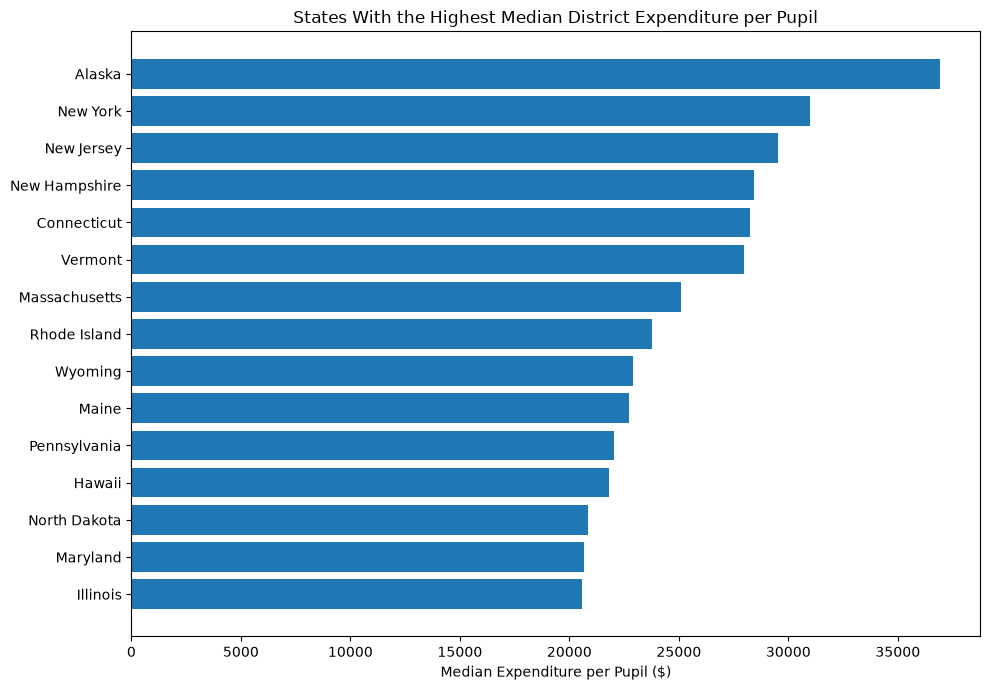

In [9]:
import matplotlib.pyplot as plt

top_spending_states = (
    state_fiscal_50
    .sort_values("EXP_PER_PUPIL", ascending=False)
    .head(15)
    .sort_values("EXP_PER_PUPIL")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_spending_states["STNAME"],
    top_spending_states["EXP_PER_PUPIL"]
)

plt.xlabel("Median Expenditure per Pupil ($)")
plt.ylabel("")
plt.title("States With the Highest Median District Expenditure per Pupil")

plt.tight_layout()
plt.show()

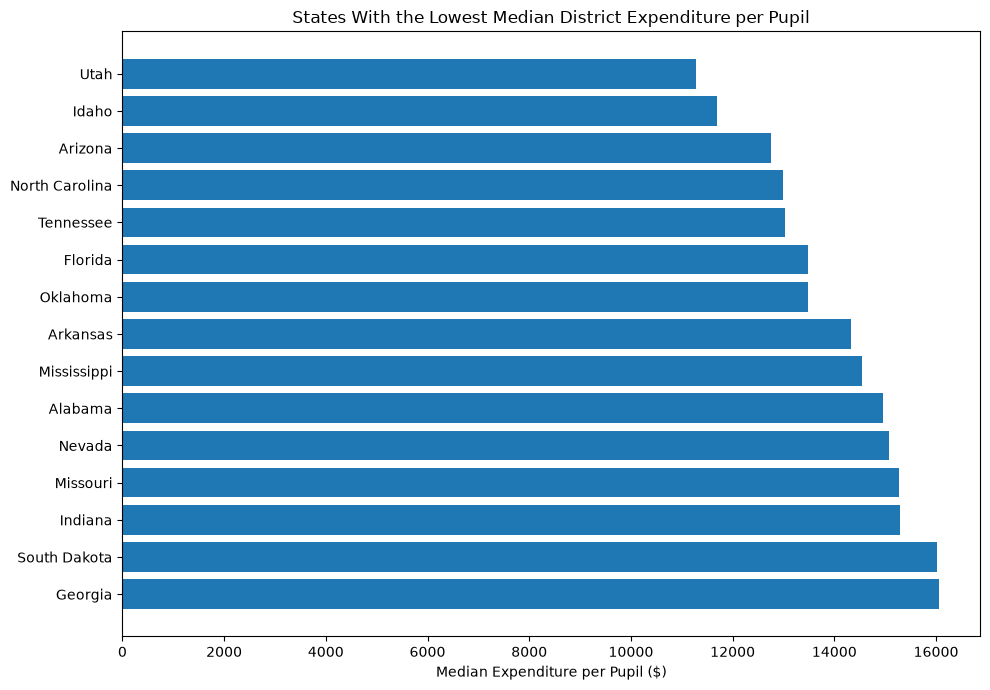

In [10]:
bottom_spending_states = (
    state_fiscal_50
    .sort_values("EXP_PER_PUPIL", ascending=True)
    .head(15)
    .sort_values("EXP_PER_PUPIL", ascending=False)
)

plt.figure(figsize=(10, 7))

plt.barh(
    bottom_spending_states["STNAME"],
    bottom_spending_states["EXP_PER_PUPIL"]
)

plt.xlabel("Median Expenditure per Pupil ($)")
plt.ylabel("")
plt.title("States With the Lowest Median District Expenditure per Pupil")

plt.tight_layout()
plt.show()

In [11]:
state_fiscal_50[
    [
        "STNAME",
        "REV_PER_PUPIL",
        "EXP_PER_PUPIL",
        "INST_PER_PUPIL",
        "STUDENT_SUPPORT_PER_PUPIL",
        "INST_STAFF_SUPPORT_PER_PUPIL"
    ]
].sort_values(
    "EXP_PER_PUPIL",
    ascending=True
).head(15)

,STNAME,REV_PER_PUPIL,EXP_PER_PUPIL,INST_PER_PUPIL,STUDENT_SUPPORT_PER_PUPIL,INST_STAFF_SUPPORT_PER_PUPIL
44,Utah,11870.167526,11284.083344,6092.024898,586.547297,292.710310
12,Idaho,12487.902247,11698.269596,6411.747163,381.675573,353.339644
2,Arizona,13610.775862,12750.000000,5915.104741,827.510917,392.638037
33,North Carolina,12532.408093,12986.886815,7112.047799,541.692357,282.776699
42,Tennessee,13333.027735,13021.023791,6790.749018,606.102725,701.948495
9,Florida,13761.518726,13474.028808,6522.172007,580.759494,734.271523
36,Oklahoma,13936.966572,13477.209781,6457.151352,782.402988,306.652900
3,Arkansas,14173.356106,14320.396367,6824.561404,637.733377,783.427495
24,Mississippi,15229.942515,14551.414405,7039.679497,690.010274,552.730483
0,Alabama,15651.234568,14948.833710,7256.583898,953.938277,468.590336


In [12]:
state_fiscal_50[
    [
        "STNAME",
        "REV_PER_PUPIL",
        "EXP_PER_PUPIL",
        "INST_PER_PUPIL",
        "STUDENT_SUPPORT_PER_PUPIL",
        "INST_STAFF_SUPPORT_PER_PUPIL"
    ]
].query("STNAME == 'Louisiana'")

,STNAME,REV_PER_PUPIL,EXP_PER_PUPIL,INST_PER_PUPIL,STUDENT_SUPPORT_PER_PUPIL,INST_STAFF_SUPPORT_PER_PUPIL
18,Louisiana,16939.869281,16332.853026,7884.053156,856.070667,738.188976


In [14]:
state_spending_rank = (
    state_fiscal_50[
        [
            "STNAME",
            "EXP_PER_PUPIL",
            "STUDENT_SUPPORT_PER_PUPIL"
        ]
    ]
    .sort_values("EXP_PER_PUPIL")
    .reset_index(drop=True)
)

state_spending_rank["Expenditure_Rank_Low_to_High"] = (
    state_spending_rank.index + 1
)

state_spending_rank.query("STNAME == 'Louisiana'")

,STNAME,EXP_PER_PUPIL,STUDENT_SUPPORT_PER_PUPIL,Expenditure_Rank_Low_to_High
20,Louisiana,16332.853026,856.070667,21


## Student Support Spending

Total school spending provides broad resource context, but student support spending is more directly relevant to the pediatric mental health access question.

Student support expenditures can include services that support students' educational, social, emotional, and health-related needs.

To compare states fairly, the analysis uses the median district-level student support spending per pupil.

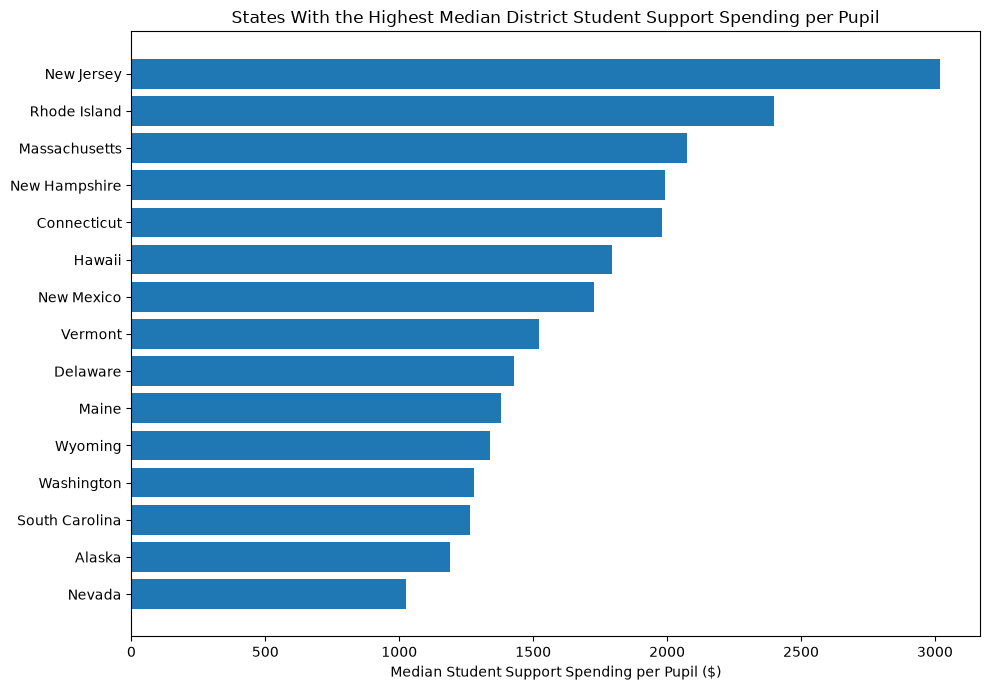

In [15]:
top_student_support_states = (
    state_fiscal_50
    .sort_values("STUDENT_SUPPORT_PER_PUPIL", ascending=False)
    .head(15)
    .sort_values("STUDENT_SUPPORT_PER_PUPIL")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_student_support_states["STNAME"],
    top_student_support_states["STUDENT_SUPPORT_PER_PUPIL"]
)

plt.xlabel("Median Student Support Spending per Pupil ($)")
plt.ylabel("")
plt.title(
    "States With the Highest Median District Student Support Spending per Pupil"
)

plt.tight_layout()
plt.show()

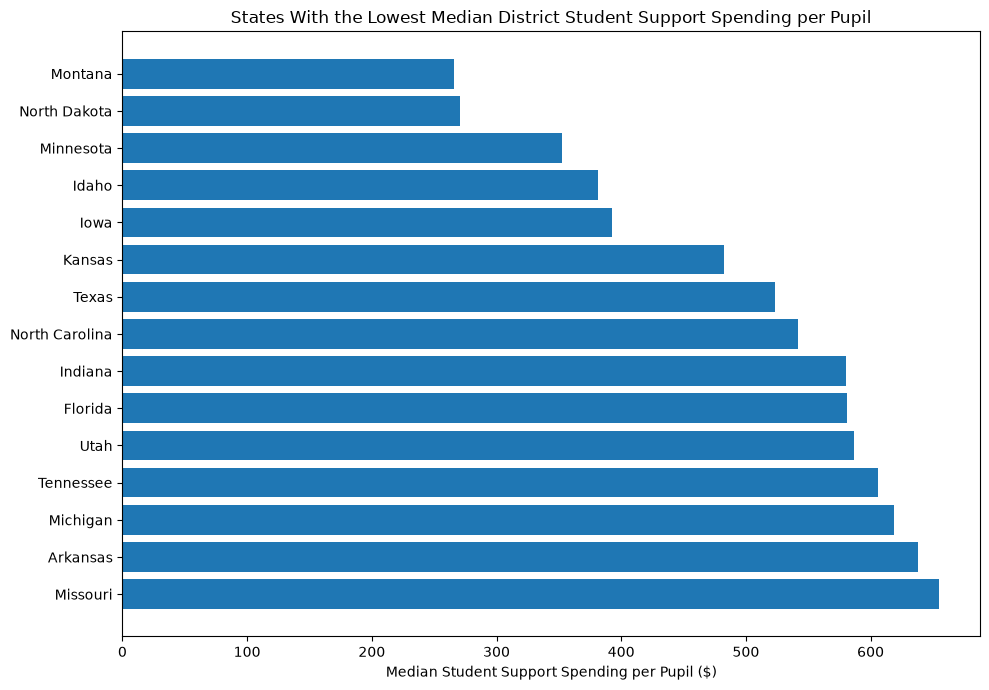

In [16]:
bottom_student_support_states = (
    state_fiscal_50
    .sort_values("STUDENT_SUPPORT_PER_PUPIL", ascending=True)
    .head(15)
    .sort_values("STUDENT_SUPPORT_PER_PUPIL", ascending=False)
)

plt.figure(figsize=(10, 7))

plt.barh(
    bottom_student_support_states["STNAME"],
    bottom_student_support_states["STUDENT_SUPPORT_PER_PUPIL"]
)

plt.xlabel("Median Student Support Spending per Pupil ($)")
plt.ylabel("")
plt.title(
    "States With the Lowest Median District Student Support Spending per Pupil"
)

plt.tight_layout()
plt.show()

## Overall Spending vs. Student Support Spending

A district or state may spend relatively more overall without allocating the same proportion of resources to student support.

Comparing total expenditure per pupil with student support expenditure per pupil helps distinguish broad school-system spending from resources more directly connected to student-facing support services.

In [17]:
state_support_comparison = (
    state_fiscal_50[
        [
            "STNAME",
            "EXP_PER_PUPIL",
            "STUDENT_SUPPORT_PER_PUPIL"
        ]
    ]
    .copy()
)

state_support_comparison["STUDENT_SUPPORT_SHARE_PCT"] = (
    state_support_comparison["STUDENT_SUPPORT_PER_PUPIL"]
    / state_support_comparison["EXP_PER_PUPIL"]
    * 100
)

state_support_comparison[
    [
        "STNAME",
        "EXP_PER_PUPIL",
        "STUDENT_SUPPORT_PER_PUPIL",
        "STUDENT_SUPPORT_SHARE_PCT"
    ]
].sort_values(
    "STUDENT_SUPPORT_SHARE_PCT",
    ascending=False
).head(15).round(1)

,STNAME,EXP_PER_PUPIL,STUDENT_SUPPORT_PER_PUPIL,STUDENT_SUPPORT_SHARE_PCT
30,New Jersey,29535.2,3017.4,10.2
39,Rhode Island,23760.5,2399.3,10.1
31,New Mexico,20184.3,1727.3,8.6
21,Massachusetts,25092.5,2073.2,8.3
11,Hawaii,21803.9,1795.2,8.2
7,Delaware,17883.0,1428.1,8.0
40,South Carolina,16478.1,1262.3,7.7
29,New Hampshire,28425.2,1993.5,7.0
6,Connecticut,28252.8,1981.4,7.0
28,Nevada,15074.3,1025.1,6.8


## Relationships Among Fiscal Measures

Correlation analysis is used to examine how different forms of district spending relate to one another.

This helps determine whether districts with higher overall expenditures also consistently spend more on instruction, student support, staff support, administration, and transportation.

In [18]:
fiscal_corr_vars = [
    "EXP_PER_PUPIL",
    "INST_PER_PUPIL",
    "SUPPORT_PER_PUPIL",
    "STUDENT_SUPPORT_PER_PUPIL",
    "INST_STAFF_SUPPORT_PER_PUPIL",
    "SCHOOL_ADMIN_PER_PUPIL",
    "TRANSPORT_PER_PUPIL"
]

fiscal_correlations = (
    fiscal_analysis[fiscal_corr_vars]
    .corr()
    .round(2)
)

fiscal_correlations

,EXP_PER_PUPIL,INST_PER_PUPIL,SUPPORT_PER_PUPIL,STUDENT_SUPPORT_PER_PUPIL,INST_STAFF_SUPPORT_PER_PUPIL,SCHOOL_ADMIN_PER_PUPIL,TRANSPORT_PER_PUPIL
EXP_PER_PUPIL,1.00,0.96,0.94,0.42,0.15,0.27,0.14
INST_PER_PUPIL,0.96,1.00,0.95,0.44,0.17,0.38,0.14
SUPPORT_PER_PUPIL,0.94,0.95,1.00,0.51,0.30,0.45,0.21
STUDENT_SUPPORT_PER_PUPIL,0.42,0.44,0.51,1.00,0.13,0.30,0.21
INST_STAFF_SUPPORT_PER_PUPIL,0.15,0.17,0.30,0.13,1.00,0.28,0.01
SCHOOL_ADMIN_PER_PUPIL,0.27,0.38,0.45,0.30,0.28,1.00,0.04
TRANSPORT_PER_PUPIL,0.14,0.14,0.21,0.21,0.01,0.04,1.00


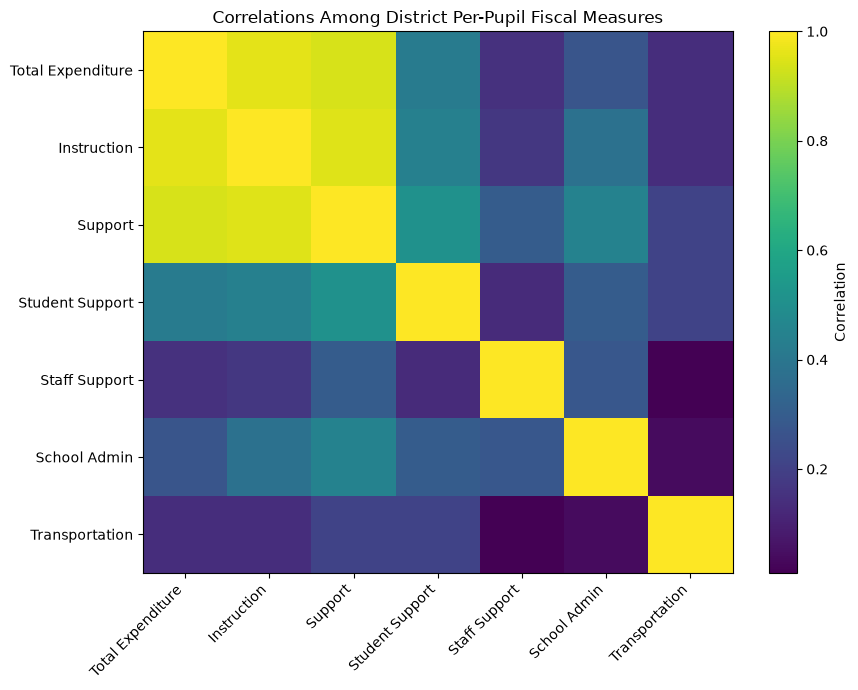

In [19]:
plt.figure(figsize=(9, 7))

plt.imshow(
    fiscal_correlations,
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(fiscal_corr_vars)),
    [
        "Total Expenditure",
        "Instruction",
        "Support",
        "Student Support",
        "Staff Support",
        "School Admin",
        "Transportation"
    ],
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(fiscal_corr_vars)),
    [
        "Total Expenditure",
        "Instruction",
        "Support",
        "Student Support",
        "Staff Support",
        "School Admin",
        "Transportation"
    ]
)

plt.title("Correlations Among District Per-Pupil Fiscal Measures")

plt.tight_layout()
plt.show()

## Fiscal Analysis Findings

School-system financial resources vary substantially across states, both in overall spending and in the amount devoted specifically to student support.

### Overall Expenditure

Median district expenditure per pupil ranged widely across states. Alaska, New York, and New Jersey were among the states with the highest median district expenditures, while Utah, Idaho, Arizona, North Carolina, and Tennessee were among the lowest.

Louisiana, which had the highest concentration of multi-factor community vulnerability in the ACS analysis, ranked 21st from lowest to highest in median district expenditure per pupil. This indicates that high community vulnerability does not necessarily correspond directly with the lowest overall school spending.

### Student Support Spending

Student-support spending showed a different geographic pattern from total expenditure.

New Jersey had the highest median district student-support spending at approximately $3,017 per pupil, followed by Rhode Island at approximately $2,399. Massachusetts, New Hampshire, Connecticut, Hawaii, and New Mexico also ranked relatively high.

At the lower end, Montana and North Dakota had median student-support spending below $300 per pupil. Texas, North Carolina, Florida, Utah, Tennessee, and several Midwestern states also appeared among the lower-spending states.

New Mexico is particularly notable because it combines high community vulnerability with relatively high student-support spending. Approximately 8.6% of its median district expenditure was devoted to student support, the third-highest share among the 50 states.

### Relationship Between Overall and Student-Support Spending

Correlation analysis showed that total expenditure per pupil was very strongly associated with instructional spending (`r = 0.96`) and overall support spending (`r = 0.94`).

However, total expenditure had only a moderate relationship with student-support spending (`r = 0.42`).

This suggests that higher overall school spending does not necessarily translate into proportionally greater spending on student-facing support services. Resource allocation patterns therefore provide information that total expenditure alone cannot capture.

In [20]:
priority_states = [
    "Louisiana",
    "New Mexico",
    "Mississippi",
    "Georgia",
    "Alaska",
    "Alabama",
    "South Carolina",
    "North Carolina",
    "Texas",
    "West Virginia"
]

priority_fiscal = (
    state_support_comparison[
        state_support_comparison["STNAME"].isin(priority_states)
    ]
    .copy()
)

# Add spending ranks among all 50 states
priority_fiscal["Overall_Spending_Rank_Low_to_High"] = (
    priority_fiscal["STNAME"]
    .map(
        state_fiscal_50
        .set_index("STNAME")["EXP_PER_PUPIL"]
        .rank(method="min", ascending=True)
    )
)

priority_fiscal["Student_Support_Rank_Low_to_High"] = (
    priority_fiscal["STNAME"]
    .map(
        state_fiscal_50
        .set_index("STNAME")["STUDENT_SUPPORT_PER_PUPIL"]
        .rank(method="min", ascending=True)
    )
)

priority_fiscal[
    [
        "STNAME",
        "EXP_PER_PUPIL",
        "Overall_Spending_Rank_Low_to_High",
        "STUDENT_SUPPORT_PER_PUPIL",
        "Student_Support_Rank_Low_to_High",
        "STUDENT_SUPPORT_SHARE_PCT"
    ]
].sort_values(
    "STUDENT_SUPPORT_PER_PUPIL"
).round(1)

,STNAME,EXP_PER_PUPIL,Overall_Spending_Rank_Low_to_High,STUDENT_SUPPORT_PER_PUPIL,Student_Support_Rank_Low_to_High,STUDENT_SUPPORT_SHARE_PCT
43,Texas,16092.9,16.0,523.7,7.0,3.3
33,North Carolina,12986.9,4.0,541.7,8.0,4.2
24,Mississippi,14551.4,9.0,690.0,19.0,4.7
10,Georgia,16061.3,15.0,855.8,26.0,5.3
18,Louisiana,16332.9,21.0,856.1,27.0,5.2
0,Alabama,14948.8,10.0,953.9,31.0,6.4
48,West Virginia,16219.7,19.0,970.7,33.0,6.0
1,Alaska,36908.6,50.0,1188.3,37.0,3.2
40,South Carolina,16478.1,22.0,1262.3,38.0,7.7
31,New Mexico,20184.3,33.0,1727.3,44.0,8.6


## NCES Fiscal Analysis Summary

The NCES fiscal analysis shows substantial variation in both overall school spending and the allocation of resources to student support across the 50 states.

### Overall School Spending

Median district expenditure per pupil varied widely across states. Alaska had the highest median district expenditure, while Utah, Idaho, Arizona, North Carolina, and Tennessee were among the lowest.

Several states identified as highly vulnerable in the ACS analysis also appeared toward the lower end of the spending distribution. North Carolina ranked fourth-lowest, Mississippi ninth-lowest, Alabama tenth-lowest, Georgia fifteenth-lowest, and Texas sixteenth-lowest in median district expenditure per pupil.

However, the relationship was not consistent across all high-vulnerability states. Louisiana ranked 21st from lowest to highest, New Mexico ranked 33rd, and Alaska had the highest median district expenditure of all 50 states.

### Student Support Spending

Student-support spending showed a different geographic pattern from total school expenditure.

Among states previously identified as having high concentrations of community vulnerability, Texas and North Carolina stood out for relatively low student-support spending, ranking seventh- and eighth-lowest respectively.

By contrast, New Mexico ranked 44th from lowest to highest, placing it among the states with the highest median student-support spending. Approximately 8.6% of its median district expenditures were devoted to student support.

Louisiana fell closer to the middle of the distribution, ranking 27th in student-support spending.

### Statistical Relationships

Total expenditure per pupil was strongly correlated with instructional spending (`r = 0.96`) and overall support spending (`r = 0.94`).

The relationship between total expenditure and student-support spending was substantially weaker (`r = 0.42`).

This indicates that districts with higher overall expenditures do not necessarily allocate proportionally more resources to student-facing support services.

### Interpretation

The fiscal findings do not support a simple relationship in which greater community vulnerability corresponds directly with lower school spending.

Instead, highly vulnerable states show different resource profiles. Some combine high community vulnerability with relatively low overall and student-support spending, while others maintain comparatively high levels of school or student-support expenditure.

These findings suggest that both the **amount of funding available** and **how that funding is allocated** are important when evaluating the school-system context surrounding pediatric mental health access.

In [23]:
import nbformat as nbf
from pathlib import Path

# ---------------------------------------------------------
# Paths
# ---------------------------------------------------------

fiscal_path = Path("03_nces_fiscal_data_analysis.ipynb")

master_path = Path(
    "../Final_Data_Analysis/07_full_project_analysis.ipynb"
)

# ---------------------------------------------------------
# Read both notebooks
# ---------------------------------------------------------

fiscal_nb = nbf.read(fiscal_path, as_version=4)
master_nb = nbf.read(master_path, as_version=4)

# ---------------------------------------------------------
# Find NCES Fiscal section in master notebook
# ---------------------------------------------------------

fiscal_start = None
fiscal_end = None

for i, cell in enumerate(master_nb.cells):

    if (
        cell.cell_type == "markdown"
        and "# 4. NCES Fiscal" in cell.source
    ):
        fiscal_start = i

    if (
        fiscal_start is not None
        and cell.cell_type == "markdown"
        and "# 5. NCES Nonfiscal" in cell.source
    ):
        fiscal_end = i
        break

if fiscal_start is None:
    raise ValueError("Could not find the NCES Fiscal section in the master notebook.")

if fiscal_end is None:
    raise ValueError("Could not find the NCES Nonfiscal section in the master notebook.")

# ---------------------------------------------------------
# Copy finished fiscal notebook cells
#
# Skip its standalone title because the master already
# contains the NCES Fiscal section heading.
# ---------------------------------------------------------

fiscal_cells = fiscal_nb.cells[1:]

# ---------------------------------------------------------
# Replace current Fiscal placeholder/content
# ---------------------------------------------------------

master_nb.cells[
    fiscal_start + 1 : fiscal_end
] = fiscal_cells

# ---------------------------------------------------------
# Save
# ---------------------------------------------------------

nbf.write(master_nb, master_path)

print("NCES Fiscal ported successfully.")
print("Updated:", master_path.resolve())
print("Fiscal cells inserted:", len(fiscal_cells))

ValueError: Could not find the NCES Fiscal section in the master notebook.

# NCES CCD Nonfiscal Data Analysis

## Purpose

The NCES Common Core of Data nonfiscal files provide district-level information about public school systems that is not financial.

For this project, three cleaned files are used:

- **District Directory** — district identity, location, and organizational characteristics
- **District Membership** — student enrollment
- **District Staff** — staffing levels and staff categories

Together, these data provide school-system capacity context for the pediatric mental health access analysis.

The primary goal is to examine how student enrollment and staffing resources vary across districts and states, with particular attention to student-facing staff capacity where available.

In [4]:
import pandas as pd
from pathlib import Path

cleaned_dir = Path("../../data/cleaned")

directory_path = cleaned_dir / "NCES_CCD_2024_25_District_Directory_clean.csv"
membership_path = cleaned_dir / "NCES_CCD_2024_25_District_Membership_clean.csv"
staff_path = cleaned_dir / "NCES_CCD_2024_25_District_Staff_clean.csv"

directory = pd.read_csv(directory_path)
membership = pd.read_csv(membership_path)
staff = pd.read_csv(staff_path)

print("Directory shape:", directory.shape)
print("Membership shape:", membership.shape)
print("Staff shape:", staff.shape)

Directory shape: (19630, 15)
Membership shape: (3822460, 15)
Staff shape: (454247, 13)


In [2]:
for f in cleaned_dir.glob("*NCES*2024*25*.csv"):
    print(f.name)

NCES_CCD_2024_25_District_Directory_clean.csv
NCES_CCD_2024_25_District_Membership_clean.csv
NCES_CCD_2024_25_District_Staff_clean.csv


## Dataset Structure

Before combining the three nonfiscal files, each dataset is inspected separately to identify the district identifier, enrollment measures, staffing measures, and geographic fields available for analysis.

The files will only be merged after confirming that the relevant district-level variables are present and compatible.

In [5]:
print("\nDIRECTORY COLUMNS")
for col in directory.columns:
    print(col)

print("\nMEMBERSHIP COLUMNS")
for col in membership.columns:
    print(col)

print("\nSTAFF COLUMNS")
for col in staff.columns:
    print(col)


DIRECTORY COLUMNS
SCHOOL_YEAR
LEAID
ST_LEAID
LEA_NAME
ST
STATENAME
FIPST
LCITY
LSTATE
LZIP
LEA_TYPE_TEXT
SY_STATUS_TEXT
UPDATED_STATUS_TEXT
LEVEL
OPERATIONAL_SCHOOLS

MEMBERSHIP COLUMNS
SCHOOL_YEAR
FIPST
STATENAME
ST
LEA_NAME
STATE_AGENCY_NO
UNION
ST_LEAID
LEAID
GRADE
RACE_ETHNICITY
SEX
STUDENT_COUNT
TOTAL_INDICATOR
DMS_FLAG

STAFF COLUMNS
SCHOOL_YEAR
FIPST
STATENAME
ST
LEA_NAME
STATE_AGENCY_NO
UNION
ST_LEAID
LEAID
STAFF
STAFF_COUNT
TOTAL_INDICATOR
DMS_FLAG


## District-Level Enrollment and Staffing Measures

The membership and staffing files are stored in long format, meaning each school district appears across multiple rows for different student groups or staff categories.

For this analysis, the data are reduced to district-level totals and selected staffing categories before being merged with the district directory.

This creates one analytical record per school district and avoids double-counting enrollment or staff.

In [6]:
staff_categories = (
    staff["STAFF"]
    .dropna()
    .value_counts()
)

staff_categories

STAFF
All Other Support Staff                                    19406
LEA Administrative Support Staff                           19406
LEA Administrators                                         19406
LEA Staff                                                  19406
Other Staff                                                19406
No Category Codes                                          19406
Guidance Counselors                                        18993
Teachers                                                   18993
School Staff                                               18975
School Administrative Support Staff                        18915
School administrators                                      18915
Instructional Coordinators and Supervisors to the Staff    18870
Librarians/media specialists                               18870
Library/Media Support Staff                                18870
Paraprofessionals/Instructional Aides                      18870
School Psychologist

In [7]:
print("Membership TOTAL_INDICATOR values:")
print(membership["TOTAL_INDICATOR"].value_counts(dropna=False))

print("\nStaff TOTAL_INDICATOR values:")
print(staff["TOTAL_INDICATOR"].value_counts(dropna=False))

Membership TOTAL_INDICATOR values:
TOTAL_INDICATOR
Category Set A - By Race/Ethnicity; Sex; Grade                              3271718
Derived - Subtotal by Race/Ethnicity and Sex minus Adult Education Count     278220
Subtotal 4 - By Grade                                                        235426
Derived - Education Unit Total minus Adult Education Count                    18548
Education Unit Total                                                          18548
Name: count, dtype: int64

Staff TOTAL_INDICATOR values:
TOTAL_INDICATOR
Category Set A                       339068
Derived - Major Staffing Category     95773
Education Unit Total                  19406
Name: count, dtype: int64


In [8]:
print("GRADE values:")
print(membership["GRADE"].value_counts(dropna=False))

print("\nRACE_ETHNICITY values:")
print(membership["RACE_ETHNICITY"].value_counts(dropna=False))

print("\nSEX values:")
print(membership["SEX"].value_counts(dropna=False))

GRADE values:
GRADE
No Category Codes    315316
Grade 6              263232
Grade 5              261168
Grade 1              260496
Grade 2              260368
Grade 4              260368
Grade 3              260192
Kindergarten         260048
Grade 8              259248
Grade 7              259104
Grade 9              225808
Grade 10             225600
Grade 11             225328
Grade 12             224928
Pre-Kindergarten     184544
Not Specified         37096
Ungraded              30048
Adult Education        6912
Grade 13               2656
Name: count, dtype: int64

RACE_ETHNICITY values:
RACE_ETHNICITY
American Indian or Alaska Native             470852
Asian                                        470852
Black or African American                    470852
Hispanic/Latino                              470852
Native Hawaiian or Other Pacific Islander    470852
Two or more races                            470852
White                                        470852
Not Specified      

## District Enrollment Totals

District enrollment is taken from membership records labeled `Education Unit Total`.

Using the district-level total avoids double-counting students across grade, race/ethnicity, and sex categories contained in the long-format membership file.

In [9]:
district_enrollment = (
    membership[
        membership["TOTAL_INDICATOR"] == "Education Unit Total"
    ][
        [
            "LEAID",
            "STATENAME",
            "ST",
            "LEA_NAME",
            "STUDENT_COUNT"
        ]
    ]
    .copy()
)

district_enrollment = district_enrollment.rename(
    columns={"STUDENT_COUNT": "TOTAL_ENROLLMENT"}
)

print("District enrollment rows:", len(district_enrollment))
print("Unique districts:", district_enrollment["LEAID"].nunique())

district_enrollment.head()

District enrollment rows: 18548
Unique districts: 18548


,LEAID,STATENAME,ST,LEA_NAME,TOTAL_ENROLLMENT
212,100002,ALABAMA,AL,Alabama Youth Services,NaN
454,100005,ALABAMA,AL,Albertville City,5910.0
697,100006,ALABAMA,AL,Marshall County,6494.0
940,100007,ALABAMA,AL,Hoover City,13632.0
1183,100008,ALABAMA,AL,Madison City,13046.0


## Student-Support Staffing

The staffing file contains several student-facing professional categories.

For this analysis, the initial focus is on:

- school psychologists
- school counselors
- guidance counselors
- student support services staff excluding psychologists

These categories are examined separately rather than summed together because some counselor categories may represent overlapping reporting structures.

In [10]:
support_staff_categories = [
    "School Psychologists",
    "School Counselors",
    "Guidance Counselors",
    "Student Support Services Staff (w/o Psychology)"
]

support_staff = staff[
    staff["STAFF"].isin(support_staff_categories)
][
    [
        "LEAID",
        "STATENAME",
        "ST",
        "LEA_NAME",
        "STAFF",
        "STAFF_COUNT"
    ]
].copy()

support_staff.head()

,LEAID,STATENAME,ST,LEA_NAME,STAFF,STAFF_COUNT
13,100002,ALABAMA,AL,Alabama Youth Services,School Counselors,NaN
14,100002,ALABAMA,AL,Alabama Youth Services,School Psychologists,NaN
17,100002,ALABAMA,AL,Alabama Youth Services,Student Support Services Staff (w/o Psychology),NaN
18,100002,ALABAMA,AL,Alabama Youth Services,Guidance Counselors,NaN
37,100005,ALABAMA,AL,Albertville City,School Counselors,0.0


In [11]:
support_staff_wide = (
    support_staff
    .pivot_table(
        index=["LEAID", "STATENAME", "ST", "LEA_NAME"],
        columns="STAFF",
        values="STAFF_COUNT",
        aggfunc="first"
    )
    .reset_index()
)

support_staff_wide.columns.name = None

support_staff_wide = support_staff_wide.rename(
    columns={
        "School Psychologists": "SCHOOL_PSYCHOLOGISTS",
        "School Counselors": "SCHOOL_COUNSELORS",
        "Guidance Counselors": "GUIDANCE_COUNSELORS",
        "Student Support Services Staff (w/o Psychology)": "STUDENT_SUPPORT_STAFF"
    }
)

print("Staff rows after pivot:", len(support_staff_wide))
support_staff_wide.head()

Staff rows after pivot: 18411


,LEAID,STATENAME,ST,LEA_NAME,GUIDANCE_COUNSELORS,SCHOOL_COUNSELORS,SCHOOL_PSYCHOLOGISTS,STUDENT_SUPPORT_STAFF
0,100005,ALABAMA,AL,Albertville City,14.0,0.0,0.0,6.00
1,100006,ALABAMA,AL,Marshall County,15.0,1.0,0.0,26.50
2,100007,ALABAMA,AL,Hoover City,36.0,0.0,0.0,52.00
3,100008,ALABAMA,AL,Madison City,28.5,0.0,1.0,62.17
4,100011,ALABAMA,AL,Leeds City,6.0,0.0,0.0,10.00


## District Staffing Capacity

Enrollment totals are merged with student-support staffing counts to create one record per district.

Staffing capacity is expressed as **students per staff member**. Higher ratios indicate that each professional is responsible for more students and therefore suggest lower staffing capacity.

The primary measures are:

- students per guidance counselor
- students per school psychologist
- students per student-support staff member

Staff categories are kept separate to avoid double-counting potentially overlapping counselor classifications.

In [12]:
district_staffing = (
    district_enrollment
    .merge(
        support_staff_wide[
            [
                "LEAID",
                "GUIDANCE_COUNSELORS",
                "SCHOOL_COUNSELORS",
                "SCHOOL_PSYCHOLOGISTS",
                "STUDENT_SUPPORT_STAFF"
            ]
        ],
        on="LEAID",
        how="left"
    )
)

print("Merged district rows:", len(district_staffing))
print("Unique districts:", district_staffing["LEAID"].nunique())

district_staffing.head()

Merged district rows: 18548
Unique districts: 18548


,LEAID,STATENAME,ST,LEA_NAME,TOTAL_ENROLLMENT,GUIDANCE_COUNSELORS,SCHOOL_COUNSELORS,SCHOOL_PSYCHOLOGISTS,STUDENT_SUPPORT_STAFF
0,100002,ALABAMA,AL,Alabama Youth Services,NaN,NaN,NaN,NaN,NaN
1,100005,ALABAMA,AL,Albertville City,5910.0,14.0,0.0,0.0,6.00
2,100006,ALABAMA,AL,Marshall County,6494.0,15.0,1.0,0.0,26.50
3,100007,ALABAMA,AL,Hoover City,13632.0,36.0,0.0,0.0,52.00
4,100008,ALABAMA,AL,Madison City,13046.0,28.5,0.0,1.0,62.17


In [13]:
staffing_cols = [
    "GUIDANCE_COUNSELORS",
    "SCHOOL_COUNSELORS",
    "SCHOOL_PSYCHOLOGISTS",
    "STUDENT_SUPPORT_STAFF"
]

staffing_check = pd.DataFrame({
    "Missing": district_staffing[staffing_cols].isna().sum(),
    "Zero": (district_staffing[staffing_cols] == 0).sum(),
    "Positive": (district_staffing[staffing_cols] > 0).sum()
})

staffing_check

,Missing,Zero,Positive
GUIDANCE_COUNSELORS,921,3874,13753
SCHOOL_COUNSELORS,6023,5444,7081
SCHOOL_PSYCHOLOGISTS,1293,8649,8606
STUDENT_SUPPORT_STAFF,1035,2632,14881


## Students per Student-Support Professional

Staff-to-student ratios are calculated only when a district reports a positive number of staff in that category.

Districts reporting zero staff are retained and flagged separately rather than assigning an artificial ratio, because division by zero would produce an undefined value.

Higher student-to-staff ratios represent lower staffing capacity.

In [14]:
import numpy as np

district_staffing["STUDENTS_PER_GUIDANCE_COUNSELOR"] = np.where(
    district_staffing["GUIDANCE_COUNSELORS"] > 0,
    district_staffing["TOTAL_ENROLLMENT"] /
    district_staffing["GUIDANCE_COUNSELORS"],
    np.nan
)

district_staffing["STUDENTS_PER_PSYCHOLOGIST"] = np.where(
    district_staffing["SCHOOL_PSYCHOLOGISTS"] > 0,
    district_staffing["TOTAL_ENROLLMENT"] /
    district_staffing["SCHOOL_PSYCHOLOGISTS"],
    np.nan
)

district_staffing["STUDENTS_PER_SUPPORT_STAFF"] = np.where(
    district_staffing["STUDENT_SUPPORT_STAFF"] > 0,
    district_staffing["TOTAL_ENROLLMENT"] /
    district_staffing["STUDENT_SUPPORT_STAFF"],
    np.nan
)

district_staffing[
    [
        "LEA_NAME",
        "STATENAME",
        "TOTAL_ENROLLMENT",
        "GUIDANCE_COUNSELORS",
        "STUDENTS_PER_GUIDANCE_COUNSELOR",
        "SCHOOL_PSYCHOLOGISTS",
        "STUDENTS_PER_PSYCHOLOGIST",
        "STUDENT_SUPPORT_STAFF",
        "STUDENTS_PER_SUPPORT_STAFF"
    ]
].head(10)

,LEA_NAME,STATENAME,TOTAL_ENROLLMENT,GUIDANCE_COUNSELORS,STUDENTS_PER_GUIDANCE_COUNSELOR,SCHOOL_PSYCHOLOGISTS,STUDENTS_PER_PSYCHOLOGIST,STUDENT_SUPPORT_STAFF,STUDENTS_PER_SUPPORT_STAFF
0,Alabama Youth Services,ALABAMA,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Albertville City,ALABAMA,5910.0,14.0,422.142857,0.0,NaN,6.00,985.000000
2,Marshall County,ALABAMA,6494.0,15.0,432.933333,0.0,NaN,26.50,245.056604
3,Hoover City,ALABAMA,13632.0,36.0,378.666667,0.0,NaN,52.00,262.153846
4,Madison City,ALABAMA,13046.0,28.5,457.754386,1.0,13046.0,62.17,209.843976
5,Al Inst Deaf And Blind,ALABAMA,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Al Sch Of Math And Science,ALABAMA,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Leeds City,ALABAMA,2271.0,6.0,378.500000,0.0,NaN,10.00,227.100000
8,Boaz City,ALABAMA,2607.0,6.0,434.500000,0.0,NaN,5.10,511.176471
9,Trussville City,ALABAMA,5005.0,11.5,435.217391,2.0,2502.5,17.98,278.364850


In [15]:
ratio_cols = [
    "STUDENTS_PER_GUIDANCE_COUNSELOR",
    "STUDENTS_PER_PSYCHOLOGIST",
    "STUDENTS_PER_SUPPORT_STAFF"
]

district_staffing[ratio_cols].describe().T.round(1)

,count,mean,std,min,25%,50%,75%,max
STUDENTS_PER_GUIDANCE_COUNSELOR,13748.0,479.4,2107.1,0.0,245.0,331.7,452.1,159500.0
STUDENTS_PER_PSYCHOLOGIST,8604.0,1325.3,2998.2,0.0,522.0,833.2,1359.9,117100.0
STUDENTS_PER_SUPPORT_STAFF,14871.0,263.6,697.8,0.0,72.2,132.0,252.1,30100.0


## Staffing Availability and Capacity

Student-support staffing varies substantially across school districts.

A large number of districts report no staff in specific support categories. School psychologists show the greatest gap: 8,649 districts report zero school psychologists, compared with 3,874 districts reporting zero guidance counselors and 2,632 reporting zero broader student-support staff.

Among districts reporting positive staffing and enrollment, the median staffing ratios are approximately:

- 332 students per guidance counselor
- 833 students per school psychologist
- 132 students per broader student-support staff member

Because staffing ratios contain extreme outliers, subsequent comparisons emphasize medians rather than means.

In [16]:
# Keep districts with positive enrollment for staffing ratio comparisons

staffing_analysis = district_staffing[
    district_staffing["TOTAL_ENROLLMENT"] > 0
].copy()

ratio_cols = [
    "STUDENTS_PER_GUIDANCE_COUNSELOR",
    "STUDENTS_PER_PSYCHOLOGIST",
    "STUDENTS_PER_SUPPORT_STAFF"
]

print("Districts with positive enrollment:", len(staffing_analysis))

staffing_analysis[ratio_cols].describe().T.round(1)

Districts with positive enrollment: 18014


,count,mean,std,min,25%,50%,75%,max
STUDENTS_PER_GUIDANCE_COUNSELOR,13634.0,483.4,2115.4,0.5,247.4,333.0,454.0,159500.0
STUDENTS_PER_PSYCHOLOGIST,8478.0,1345.0,3016.0,2.0,533.7,843.1,1376.0,117100.0
STUDENTS_PER_SUPPORT_STAFF,14641.0,267.8,702.4,0.3,74.5,134.0,255.5,30100.0


## State-Level Student-Support Capacity

District staffing measures are summarized at the state level using median student-to-staff ratios.

Higher student-to-staff ratios indicate lower staffing capacity because each professional is responsible for more students.

The analysis also considers the percentage of districts reporting zero professionals in each category. This distinguishes states where existing staff carry large caseloads from states where many districts report no staff in that category at all.

In [17]:
# Exclude DC for formal 50-state comparisons

staffing_50 = staffing_analysis[
    staffing_analysis["STATENAME"].str.upper() != "DISTRICT OF COLUMBIA"
].copy()

state_staffing = (
    staffing_50
    .groupby("STATENAME")
    .agg(
        DISTRICTS=("LEAID", "nunique"),

        MEDIAN_STUDENTS_PER_COUNSELOR=(
            "STUDENTS_PER_GUIDANCE_COUNSELOR", "median"
        ),

        MEDIAN_STUDENTS_PER_PSYCHOLOGIST=(
            "STUDENTS_PER_PSYCHOLOGIST", "median"
        ),

        MEDIAN_STUDENTS_PER_SUPPORT_STAFF=(
            "STUDENTS_PER_SUPPORT_STAFF", "median"
        ),

        ZERO_COUNSELOR_DISTRICTS=(
            "GUIDANCE_COUNSELORS",
            lambda x: (x == 0).sum()
        ),

        ZERO_PSYCHOLOGIST_DISTRICTS=(
            "SCHOOL_PSYCHOLOGISTS",
            lambda x: (x == 0).sum()
        ),

        ZERO_SUPPORT_STAFF_DISTRICTS=(
            "STUDENT_SUPPORT_STAFF",
            lambda x: (x == 0).sum()
        )
    )
    .reset_index()
)

state_staffing["PCT_ZERO_COUNSELOR"] = (
    state_staffing["ZERO_COUNSELOR_DISTRICTS"]
    / state_staffing["DISTRICTS"] * 100
)

state_staffing["PCT_ZERO_PSYCHOLOGIST"] = (
    state_staffing["ZERO_PSYCHOLOGIST_DISTRICTS"]
    / state_staffing["DISTRICTS"] * 100
)

state_staffing["PCT_ZERO_SUPPORT_STAFF"] = (
    state_staffing["ZERO_SUPPORT_STAFF_DISTRICTS"]
    / state_staffing["DISTRICTS"] * 100
)

state_staffing.round(1).head()

,STATENAME,DISTRICTS,MEDIAN_STUDENTS_PER_COUNSELOR,MEDIAN_STUDENTS_PER_PSYCHOLOGIST,MEDIAN_STUDENTS_PER_SUPPORT_STAFF,ZERO_COUNSELOR_DISTRICTS,ZERO_PSYCHOLOGIST_DISTRICTS,ZERO_SUPPORT_STAFF_DISTRICTS,PCT_ZERO_COUNSELOR,PCT_ZERO_PSYCHOLOGIST,PCT_ZERO_SUPPORT_STAFF
0,ALABAMA,153,383.5,4492.5,274.0,4,147,4,2.6,96.1,2.6
1,ALASKA,53,336.0,1080.0,216.1,20,42,27,37.7,79.2,50.9
2,ARIZONA,659,418.6,712.0,78.4,382,492,237,58.0,74.7,36.0
3,ARKANSAS,263,335.8,1775.0,66.0,9,218,2,3.4,82.9,0.8
4,BUREAU OF INDIAN EDUCATION,174,139.0,216.2,66.2,0,0,0,0.0,0.0,0.0


In [18]:
psychologist_capacity = (
    state_staffing
    .dropna(subset=["MEDIAN_STUDENTS_PER_PSYCHOLOGIST"])
    .sort_values(
        "MEDIAN_STUDENTS_PER_PSYCHOLOGIST",
        ascending=False
    )
)

psychologist_capacity[
    [
        "STATENAME",
        "DISTRICTS",
        "MEDIAN_STUDENTS_PER_PSYCHOLOGIST",
        "PCT_ZERO_PSYCHOLOGIST"
    ]
].head(15).round(1)

,STATENAME,DISTRICTS,MEDIAN_STUDENTS_PER_PSYCHOLOGIST,PCT_ZERO_PSYCHOLOGIST
36,NORTHERN MARIANAS,1,8965.0,0.0
11,GUAM,5,4682.6,0.0
0,ALABAMA,153,4492.5,96.1
25,MISSISSIPPI,152,3289.5,9.9
47,U.S. VIRGIN ISLANDS,2,2572.5,50.0
48,UTAH,155,2195.0,77.4
9,FLORIDA,82,2079.8,32.9
16,IOWA,329,1913.9,99.1
38,OKLAHOMA,542,1898.0,88.7
10,GEORGIA,234,1870.1,29.9


In [21]:
# Keep only the 50 U.S. states

states_50 = [
    "ALABAMA", "ALASKA", "ARIZONA", "ARKANSAS", "CALIFORNIA",
    "COLORADO", "CONNECTICUT", "DELAWARE", "FLORIDA", "GEORGIA",
    "HAWAII", "IDAHO", "ILLINOIS", "INDIANA", "IOWA",
    "KANSAS", "KENTUCKY", "LOUISIANA", "MAINE", "MARYLAND",
    "MASSACHUSETTS", "MICHIGAN", "MINNESOTA", "MISSISSIPPI", "MISSOURI",
    "MONTANA", "NEBRASKA", "NEVADA", "NEW HAMPSHIRE", "NEW JERSEY",
    "NEW MEXICO", "NEW YORK", "NORTH CAROLINA", "NORTH DAKOTA", "OHIO",
    "OKLAHOMA", "OREGON", "PENNSYLVANIA", "RHODE ISLAND", "SOUTH CAROLINA",
    "SOUTH DAKOTA", "TENNESSEE", "TEXAS", "UTAH", "VERMONT",
    "VIRGINIA", "WASHINGTON", "WEST VIRGINIA", "WISCONSIN", "WYOMING"
]

staffing_50 = staffing_analysis[
    staffing_analysis["STATENAME"].str.upper().isin(states_50)
].copy()

print("States included:", staffing_50["STATENAME"].nunique())
print(sorted(staffing_50["STATENAME"].unique()))

States included: 50
['ALABAMA', 'ALASKA', 'ARIZONA', 'ARKANSAS', 'CALIFORNIA', 'COLORADO', 'CONNECTICUT', 'DELAWARE', 'FLORIDA', 'GEORGIA', 'HAWAII', 'IDAHO', 'ILLINOIS', 'INDIANA', 'IOWA', 'KANSAS', 'KENTUCKY', 'LOUISIANA', 'MAINE', 'MARYLAND', 'MASSACHUSETTS', 'MICHIGAN', 'MINNESOTA', 'MISSISSIPPI', 'MISSOURI', 'MONTANA', 'NEBRASKA', 'NEVADA', 'NEW HAMPSHIRE', 'NEW JERSEY', 'NEW MEXICO', 'NEW YORK', 'NORTH CAROLINA', 'NORTH DAKOTA', 'OHIO', 'OKLAHOMA', 'OREGON', 'PENNSYLVANIA', 'RHODE ISLAND', 'SOUTH CAROLINA', 'SOUTH DAKOTA', 'TENNESSEE', 'TEXAS', 'UTAH', 'VERMONT', 'VIRGINIA', 'WASHINGTON', 'WEST VIRGINIA', 'WISCONSIN', 'WYOMING']


In [31]:
state_staffing = (
    staffing_50
    .groupby("STATENAME")
    .agg(
        DISTRICTS=("LEAID", "nunique"),

        MEDIAN_STUDENTS_PER_COUNSELOR=(
            "STUDENTS_PER_GUIDANCE_COUNSELOR", "median"
        ),

        MEDIAN_STUDENTS_PER_PSYCHOLOGIST=(
            "STUDENTS_PER_PSYCHOLOGIST", "median"
        ),

        MEDIAN_STUDENTS_PER_SUPPORT_STAFF=(
            "STUDENTS_PER_SUPPORT_STAFF", "median"
        ),

        ZERO_COUNSELOR_DISTRICTS=(
            "GUIDANCE_COUNSELORS",
            lambda x: (x == 0).sum()
        ),

        ZERO_PSYCHOLOGIST_DISTRICTS=(
            "SCHOOL_PSYCHOLOGISTS",
            lambda x: (x == 0).sum()
        ),

        ZERO_SUPPORT_STAFF_DISTRICTS=(
            "STUDENT_SUPPORT_STAFF",
            lambda x: (x == 0).sum()
        )
    )
    .reset_index()
)

state_staffing["PCT_ZERO_COUNSELOR"] = (
    state_staffing["ZERO_COUNSELOR_DISTRICTS"]
    / state_staffing["DISTRICTS"] * 100
)

state_staffing["PCT_ZERO_PSYCHOLOGIST"] = (
    state_staffing["ZERO_PSYCHOLOGIST_DISTRICTS"]
    / state_staffing["DISTRICTS"] * 100
)

state_staffing["PCT_ZERO_SUPPORT_STAFF"] = (
    state_staffing["ZERO_SUPPORT_STAFF_DISTRICTS"]
    / state_staffing["DISTRICTS"] * 100
)

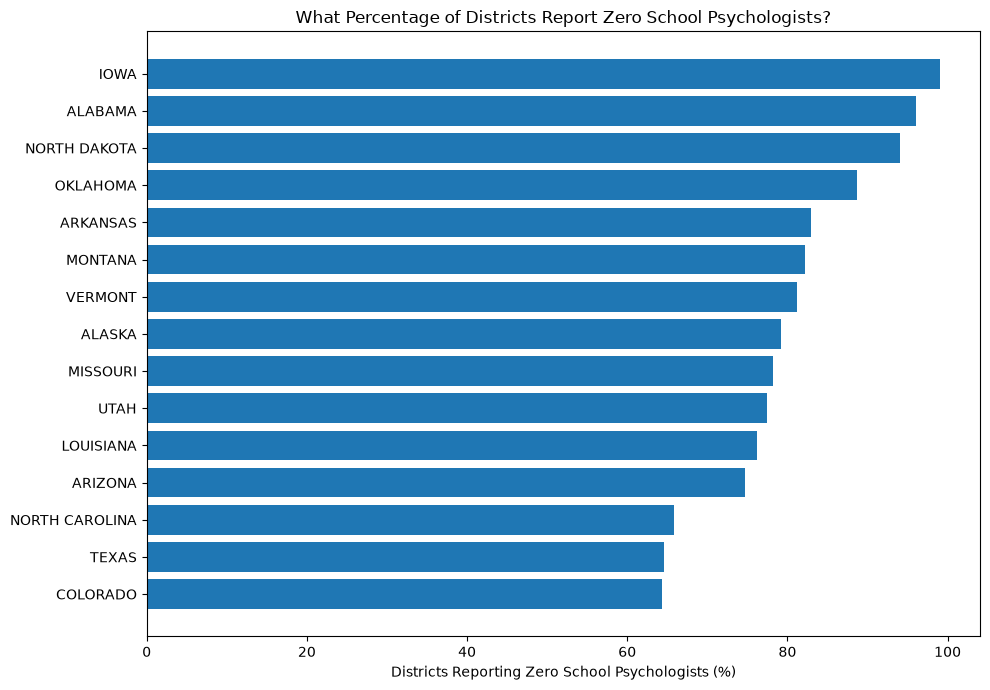

In [33]:
zero_psychologist_states = (
    state_staffing
    .sort_values("PCT_ZERO_PSYCHOLOGIST", ascending=False)
    .head(15)
    .sort_values("PCT_ZERO_PSYCHOLOGIST")
)

plt.figure(figsize=(10, 7))

plt.barh(
    zero_psychologist_states["STATENAME"],
    zero_psychologist_states["PCT_ZERO_PSYCHOLOGIST"]
)

plt.xlabel("Districts Reporting Zero School Psychologists (%)")
plt.ylabel("")
plt.title(
    "What Percentage of Districts Report Zero School Psychologists?"
)

plt.tight_layout()
plt.show()

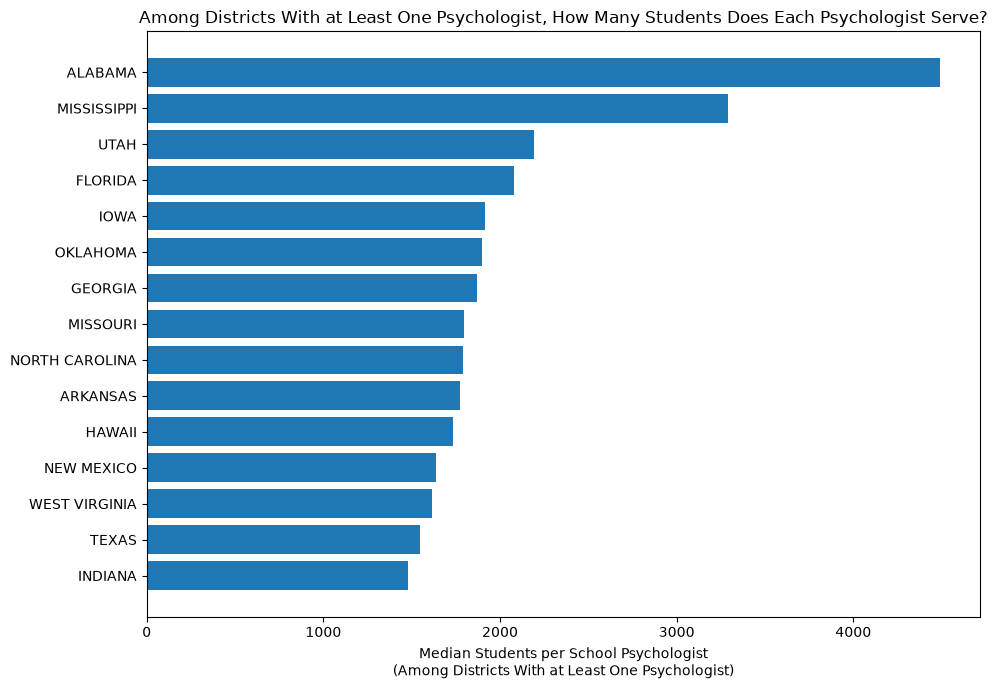

In [34]:
psychologist_capacity = (
    state_staffing
    .dropna(subset=["MEDIAN_STUDENTS_PER_PSYCHOLOGIST"])
    .sort_values(
        "MEDIAN_STUDENTS_PER_PSYCHOLOGIST",
        ascending=False
    )
)

top_psychologist_ratios = (
    psychologist_capacity
    .head(15)
    .sort_values("MEDIAN_STUDENTS_PER_PSYCHOLOGIST")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_psychologist_ratios["STATENAME"],
    top_psychologist_ratios["MEDIAN_STUDENTS_PER_PSYCHOLOGIST"]
)

plt.xlabel(
    "Median Students per School Psychologist\n"
    "(Among Districts With at Least One Psychologist)"
)
plt.ylabel("")
plt.title(
    "Among Districts With at Least One Psychologist, "
    "How Many Students Does Each Psychologist Serve?"
)

plt.tight_layout()
plt.show()

## School Psychologist Availability and Capacity

The two school psychologist charts measure **different aspects of staffing access and should not be interpreted as the same measure**.

### Districts Reporting Zero School Psychologists

The first chart shows the **percentage of school districts in each state that report zero school psychologists**.

A higher percentage means school psychologist availability is more limited across districts.

For example:

- **Iowa:** nearly 100% of districts report zero school psychologists.
- **Alabama:** approximately 96% of districts report zero school psychologists.
- **Louisiana:** approximately 76% of districts report zero school psychologists.
- **Texas:** approximately 65% of districts report zero school psychologists.

This measure answers:

**How often does a district report having no school psychologist at all?**

### Students per Psychologist Among Districts With At Least One

The second chart includes **only districts that report at least one school psychologist**.

It shows the median number of students served per psychologist within those staffed districts. A higher ratio means each psychologist is responsible for more students, indicating lower staffing capacity.

For example:

- **Alabama:** approximately 4,500 students per psychologist.
- **Mississippi:** approximately 3,300 students per psychologist.
- **Iowa:** approximately 1,900 students per psychologist.
- **Texas:** approximately 1,500 students per psychologist.

This measure answers:

**When a district does have a school psychologist, how many students does each psychologist serve?**

### Interpretation

These measures capture two different staffing problems:

- **Availability:** whether districts report having a school psychologist at all.
- **Capacity:** how many students each psychologist serves in districts where psychologists are present.

A state can therefore perform poorly on one or both measures.

For example, Iowa has an especially large **availability gap**, with nearly all districts reporting zero psychologists. Among the relatively small number of Iowa districts that do report at least one psychologist, the median psychologist serves roughly 1,900 students.

Alabama shows both an **availability and capacity problem**: most districts report zero psychologists, and psychologists in districts where they are present serve particularly large student populations.

These findings should not be interpreted as saying that every student in a state has the stated student-to-psychologist ratio. The ratio applies only to districts reporting at least one school psychologist.

## Guidance Counselor Capacity

Guidance counselor staffing is analyzed separately from school psychologist staffing.

Two measures are used:

- the percentage of districts reporting zero guidance counselors
- the median number of students per guidance counselor among districts reporting at least one guidance counselor

Together, these measures distinguish between counselor availability and counselor workload.

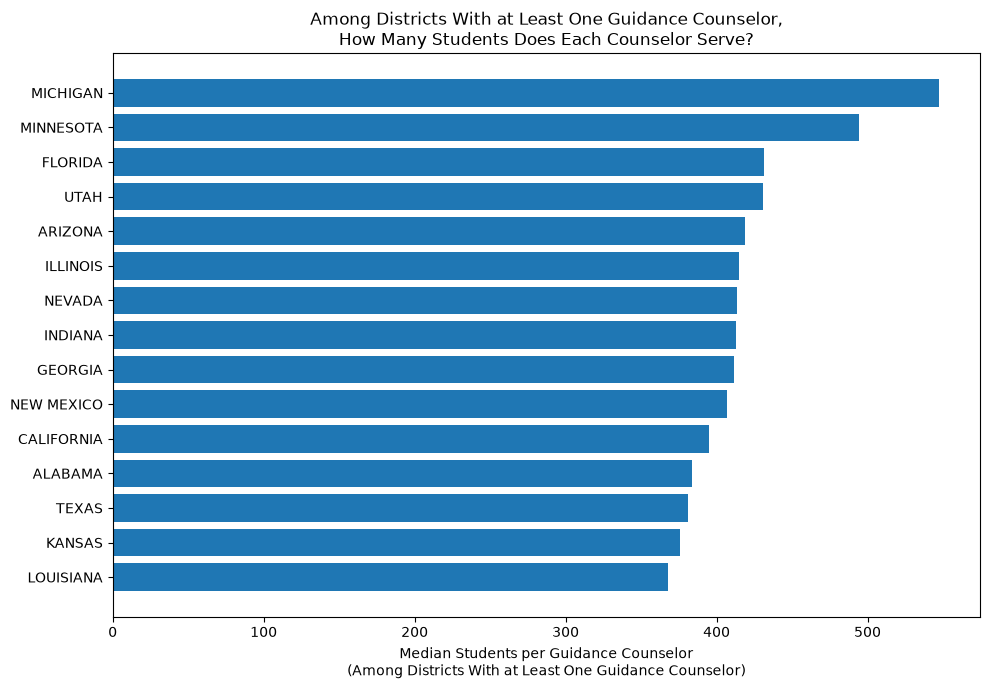

In [40]:
# States with the highest median students per guidance counselor

counselor_capacity = (
    state_staffing
    .dropna(subset=["MEDIAN_STUDENTS_PER_COUNSELOR"])
    .sort_values(
        "MEDIAN_STUDENTS_PER_COUNSELOR",
        ascending=False
    )
)

top_counselor_ratios = (
    counselor_capacity
    .head(15)
    .sort_values("MEDIAN_STUDENTS_PER_COUNSELOR")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_counselor_ratios["STATENAME"],
    top_counselor_ratios["MEDIAN_STUDENTS_PER_COUNSELOR"]
)

plt.xlabel(
    "Median Students per Guidance Counselor\n"
    "(Among Districts With at Least One Guidance Counselor)"
)

plt.ylabel("")

plt.title(
    "Among Districts With at Least One Guidance Counselor,\n"
    "How Many Students Does Each Counselor Serve?"
)

plt.tight_layout()
plt.show()

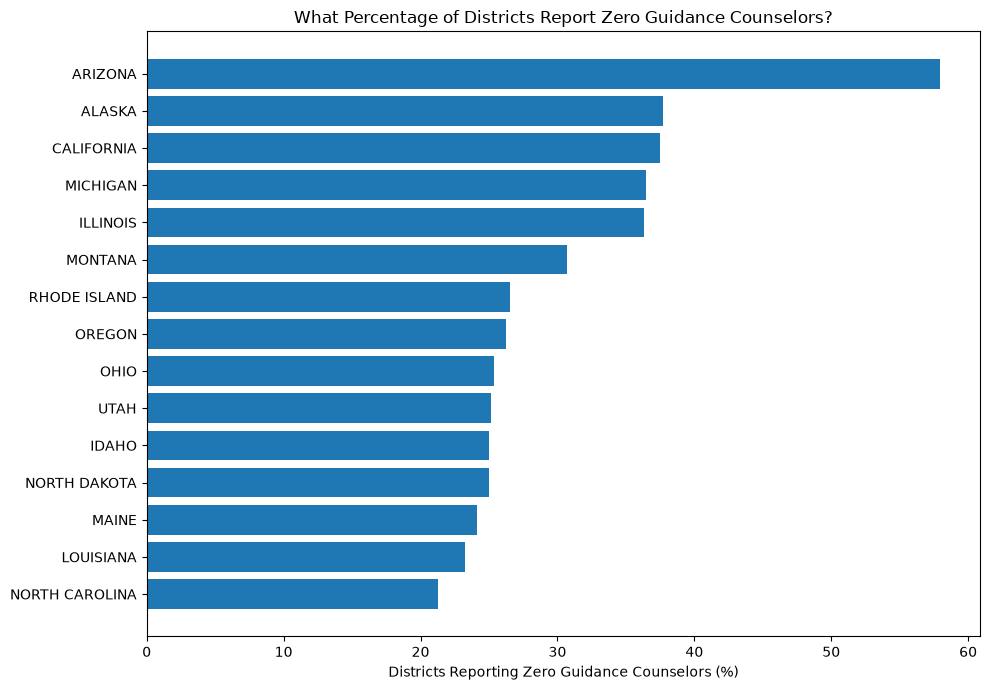

In [36]:
zero_counselor_states = (
    state_staffing
    .sort_values("PCT_ZERO_COUNSELOR", ascending=False)
    .head(15)
    .sort_values("PCT_ZERO_COUNSELOR")
)

plt.figure(figsize=(10, 7))

plt.barh(
    zero_counselor_states["STATENAME"],
    zero_counselor_states["PCT_ZERO_COUNSELOR"]
)

plt.xlabel("Districts Reporting Zero Guidance Counselors (%)")
plt.ylabel("")
plt.title(
    "What Percentage of Districts Report Zero Guidance Counselors?"
)

plt.tight_layout()
plt.show()

## Broader Student-Support Staffing

The NCES staffing data also identify student support services staff excluding psychologists.

This category provides a broader measure of student-facing support capacity beyond school psychologists and guidance counselors.

As with the other staffing categories, the analysis examines both availability and workload.

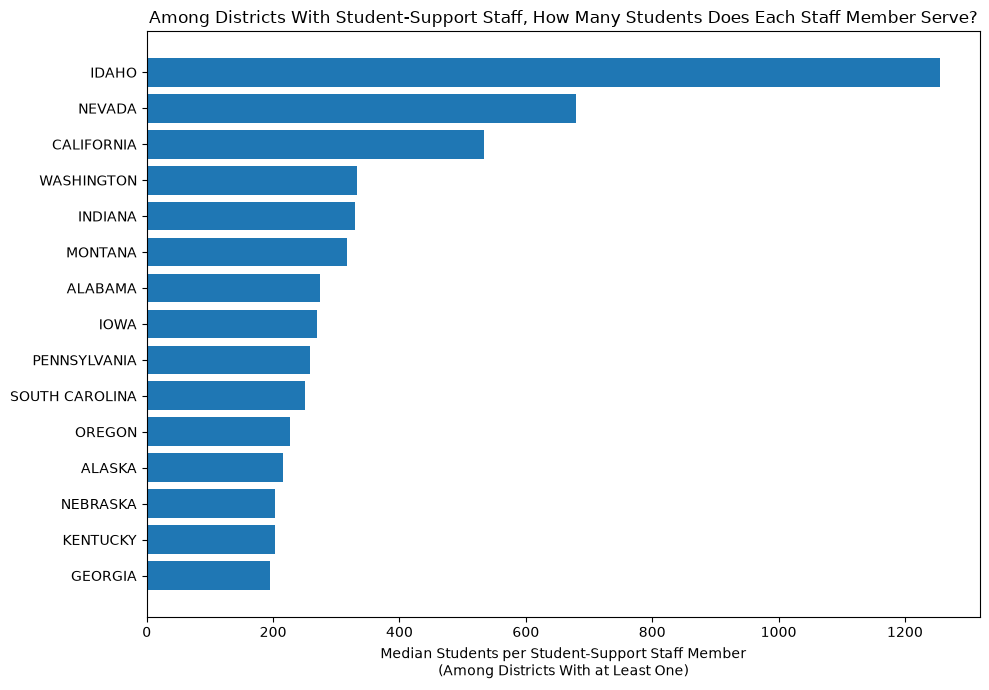

In [37]:
support_capacity = (
    state_staffing
    .dropna(subset=["MEDIAN_STUDENTS_PER_SUPPORT_STAFF"])
    .sort_values(
        "MEDIAN_STUDENTS_PER_SUPPORT_STAFF",
        ascending=False
    )
)

top_support_ratios = (
    support_capacity
    .head(15)
    .sort_values("MEDIAN_STUDENTS_PER_SUPPORT_STAFF")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_support_ratios["STATENAME"],
    top_support_ratios["MEDIAN_STUDENTS_PER_SUPPORT_STAFF"]
)

plt.xlabel(
    "Median Students per Student-Support Staff Member\n"
    "(Among Districts With at Least One)"
)
plt.ylabel("")
plt.title(
    "Among Districts With Student-Support Staff, "
    "How Many Students Does Each Staff Member Serve?"
)

plt.tight_layout()
plt.show()

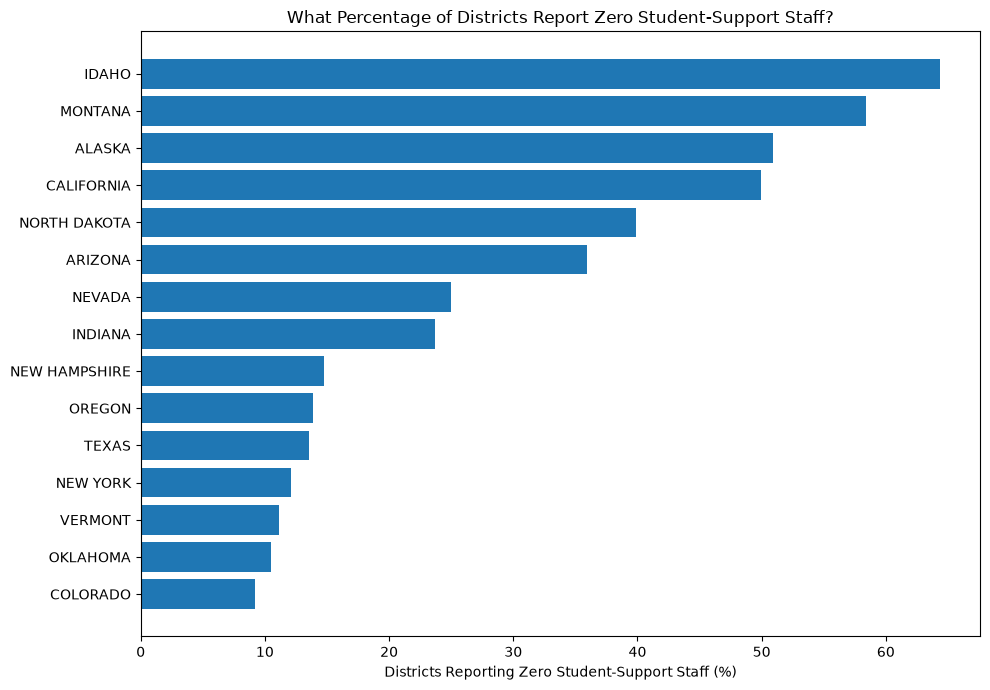

In [38]:
zero_support_states = (
    state_staffing
    .sort_values("PCT_ZERO_SUPPORT_STAFF", ascending=False)
    .head(15)
    .sort_values("PCT_ZERO_SUPPORT_STAFF")
)

plt.figure(figsize=(10, 7))

plt.barh(
    zero_support_states["STATENAME"],
    zero_support_states["PCT_ZERO_SUPPORT_STAFF"]
)

plt.xlabel("Districts Reporting Zero Student-Support Staff (%)")
plt.ylabel("")
plt.title(
    "What Percentage of Districts Report Zero Student-Support Staff?"
)

plt.tight_layout()
plt.show()

## Teacher Staffing Capacity

Teacher staffing provides broader school-system capacity context.

Unlike psychologists, counselors, and student-support staff, teachers are not a mental-health-specific resource. However, student-to-teacher ratios provide a useful comparison for understanding whether support-staff shortages occur within generally low-staffed school systems or are more specific to student-support roles.

In [39]:
teachers = (
    staff[
        staff["STAFF"] == "Teachers"
    ][
        ["LEAID", "STAFF_COUNT"]
    ]
    .rename(columns={"STAFF_COUNT": "TEACHERS"})
    .copy()
)

district_staffing = district_staffing.merge(
    teachers,
    on="LEAID",
    how="left"
)

district_staffing["STUDENTS_PER_TEACHER"] = np.where(
    (district_staffing["TEACHERS"] > 0) &
    (district_staffing["TOTAL_ENROLLMENT"] > 0),
    district_staffing["TOTAL_ENROLLMENT"] /
    district_staffing["TEACHERS"],
    np.nan
)

district_staffing[
    [
        "LEA_NAME",
        "STATENAME",
        "TOTAL_ENROLLMENT",
        "TEACHERS",
        "STUDENTS_PER_TEACHER"
    ]
].head()

,LEA_NAME,STATENAME,TOTAL_ENROLLMENT,TEACHERS,STUDENTS_PER_TEACHER
0,Alabama Youth Services,ALABAMA,NaN,NaN,NaN
1,Albertville City,ALABAMA,5910.0,321.50,18.382582
2,Marshall County,ALABAMA,6494.0,343.98,18.879005
3,Hoover City,ALABAMA,13632.0,939.20,14.514480
4,Madison City,ALABAMA,13046.0,774.60,16.842241


## Combined Student-Support Staffing Availability

To examine overall student-support staffing availability, each district is classified according to how many of three support categories are present:

- guidance counselors
- school psychologists
- broader student-support services staff

Each district receives a count from 0 to 3:

- **0:** none of the three staffing categories are present
- **1:** one staffing category is present
- **2:** two staffing categories are present
- **3:** all three staffing categories are present

This measure summarizes the breadth of student-support staffing available within each district. It does not measure staffing quality or workload.

In [41]:
# Count how many of the three support categories are present in each district

staffing_50["HAS_GUIDANCE_COUNSELOR"] = (
    staffing_50["GUIDANCE_COUNSELORS"] > 0
).astype(int)

staffing_50["HAS_PSYCHOLOGIST"] = (
    staffing_50["SCHOOL_PSYCHOLOGISTS"] > 0
).astype(int)

staffing_50["HAS_SUPPORT_STAFF"] = (
    staffing_50["STUDENT_SUPPORT_STAFF"] > 0
).astype(int)

staffing_50["SUPPORT_TYPES_PRESENT"] = (
    staffing_50["HAS_GUIDANCE_COUNSELOR"]
    + staffing_50["HAS_PSYCHOLOGIST"]
    + staffing_50["HAS_SUPPORT_STAFF"]
)

staffing_50["SUPPORT_TYPES_PRESENT"].value_counts().sort_index()

SUPPORT_TYPES_PRESENT
0    1836
1    2720
2    5997
3    7207
Name: count, dtype: int64

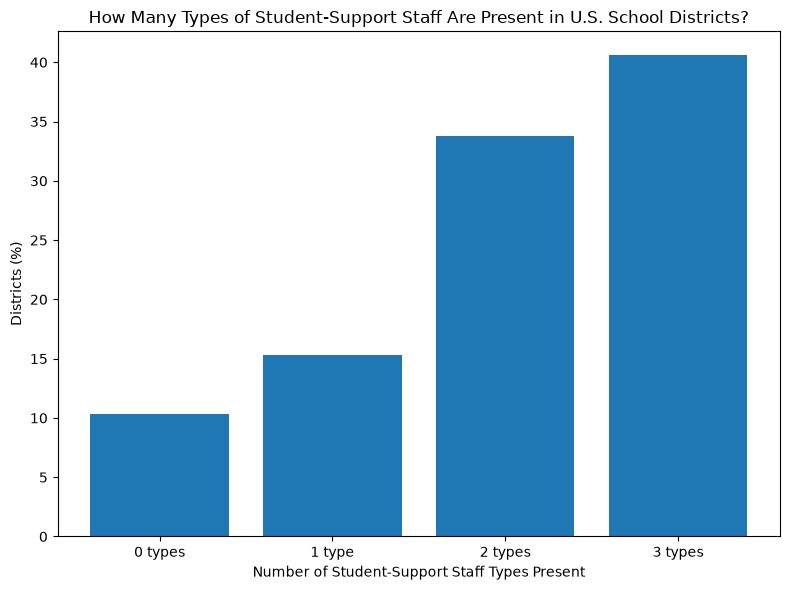

In [42]:
support_type_distribution = (
    staffing_50["SUPPORT_TYPES_PRESENT"]
    .value_counts()
    .sort_index()
)

support_type_pct = (
    support_type_distribution / support_type_distribution.sum() * 100
)

plt.figure(figsize=(8, 6))

plt.bar(
    ["0 types", "1 type", "2 types", "3 types"],
    support_type_pct.reindex([0, 1, 2, 3]).values
)

plt.xlabel("Number of Student-Support Staff Types Present")
plt.ylabel("Districts (%)")
plt.title(
    "How Many Types of Student-Support Staff Are Present in U.S. School Districts?"
)

plt.tight_layout()
plt.show()

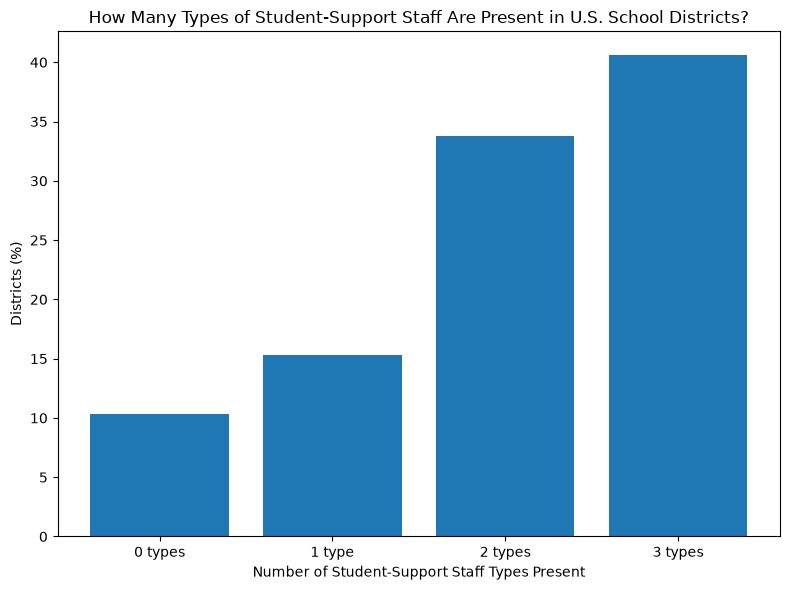

In [43]:
support_type_distribution = (
    staffing_50["SUPPORT_TYPES_PRESENT"]
    .value_counts()
    .sort_index()
)

support_type_pct = (
    support_type_distribution / support_type_distribution.sum() * 100
)

plt.figure(figsize=(8, 6))

plt.bar(
    ["0 types", "1 type", "2 types", "3 types"],
    support_type_pct.reindex([0, 1, 2, 3]).values
)

plt.xlabel("Number of Student-Support Staff Types Present")
plt.ylabel("Districts (%)")
plt.title(
    "How Many Types of Student-Support Staff Are Present in U.S. School Districts?"
)

plt.tight_layout()
plt.show()

In [44]:
state_support_breadth = (
    staffing_50
    .groupby("STATENAME")["SUPPORT_TYPES_PRESENT"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("PERCENT")
    .reset_index()
)

state_support_breadth_pivot = (
    state_support_breadth
    .pivot(
        index="STATENAME",
        columns="SUPPORT_TYPES_PRESENT",
        values="PERCENT"
    )
    .fillna(0)
)

state_support_breadth_pivot.columns = [
    f"{int(col)}_TYPES"
    for col in state_support_breadth_pivot.columns
]

state_support_breadth_pivot.head()

,0_TYPES,1_TYPES,2_TYPES,3_TYPES
STATENAME,,,,
ALABAMA,1.307190,2.614379,92.156863,3.921569
ALASKA,28.301887,30.188679,22.641509,18.867925
ARIZONA,37.784522,25.493171,20.637329,16.084977
ARKANSAS,0.380228,3.041825,79.847909,16.730038
CALIFORNIA,26.163968,17.611336,17.712551,38.512146


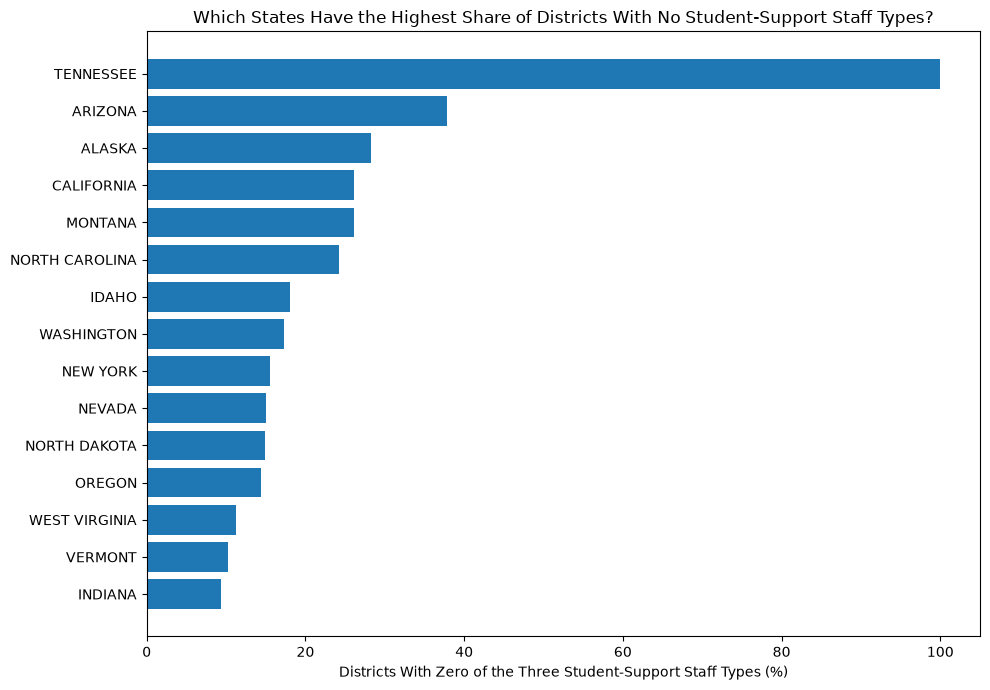

In [45]:
zero_support_types_states = (
    state_support_breadth_pivot
    .sort_values("0_TYPES", ascending=False)
    .head(15)
    .sort_values("0_TYPES")
)

plt.figure(figsize=(10, 7))

plt.barh(
    zero_support_types_states.index,
    zero_support_types_states["0_TYPES"]
)

plt.xlabel(
    "Districts With Zero of the Three Student-Support Staff Types (%)"
)
plt.ylabel("")
plt.title(
    "Which States Have the Highest Share of Districts With No Student-Support Staff Types?"
)

plt.tight_layout()
plt.show()

## Student Access to Multiple Support Roles

District staffing availability is also examined from the student perspective.

Each district is classified according to whether it reports positive staffing in three student-support categories:

- guidance counselors
- school psychologists
- broader student-support services staff

Districts are classified as having **0, 1, 2, or all 3 support-role types present**.

Student enrollment is then aggregated within these categories. This shows not only how many districts have different combinations of support roles, but how many students attend schools within those staffing environments.

This measure reflects the **breadth of reported support-role availability**, not the number of individual staff members or the quality of services provided.

In [46]:
staffing_50["HAS_GUIDANCE_COUNSELOR"] = (
    staffing_50["GUIDANCE_COUNSELORS"] > 0
).astype(int)

staffing_50["HAS_PSYCHOLOGIST"] = (
    staffing_50["SCHOOL_PSYCHOLOGISTS"] > 0
).astype(int)

staffing_50["HAS_SUPPORT_STAFF"] = (
    staffing_50["STUDENT_SUPPORT_STAFF"] > 0
).astype(int)

staffing_50["SUPPORT_TYPES_PRESENT"] = (
    staffing_50["HAS_GUIDANCE_COUNSELOR"]
    + staffing_50["HAS_PSYCHOLOGIST"]
    + staffing_50["HAS_SUPPORT_STAFF"]
)

staffing_50[
    ["LEA_NAME", "STATENAME", "TOTAL_ENROLLMENT", "SUPPORT_TYPES_PRESENT"]
].head()

,LEA_NAME,STATENAME,TOTAL_ENROLLMENT,SUPPORT_TYPES_PRESENT
1,Albertville City,ALABAMA,5910.0,2
2,Marshall County,ALABAMA,6494.0,2
3,Hoover City,ALABAMA,13632.0,2
4,Madison City,ALABAMA,13046.0,3
7,Leeds City,ALABAMA,2271.0,2


In [47]:
state_student_support_access = (
    staffing_50
    .dropna(subset=["TOTAL_ENROLLMENT"])
    .groupby(
        ["STATENAME", "SUPPORT_TYPES_PRESENT"],
        as_index=False
    )["TOTAL_ENROLLMENT"]
    .sum()
)

state_totals = (
    state_student_support_access
    .groupby("STATENAME")["TOTAL_ENROLLMENT"]
    .transform("sum")
)

state_student_support_access["STUDENT_PCT"] = (
    state_student_support_access["TOTAL_ENROLLMENT"]
    / state_totals
    * 100
)

state_student_support_access.head(10)

,STATENAME,SUPPORT_TYPES_PRESENT,TOTAL_ENROLLMENT,STUDENT_PCT
0,ALABAMA,0,757.0,0.100791
1,ALABAMA,1,8523.0,1.134796
2,ALABAMA,2,702123.0,93.484276
3,ALABAMA,3,39657.0,5.280137
4,ALASKA,0,3346.0,2.576304
5,ALASKA,1,7504.0,5.777819
6,ALASKA,2,24473.0,18.843358
7,ALASKA,3,94553.0,72.802519
8,ARIZONA,0,94770.0,8.594250
9,ARIZONA,1,61368.0,5.565178


In [48]:
student_access_pivot = (
    state_student_support_access
    .pivot(
        index="STATENAME",
        columns="SUPPORT_TYPES_PRESENT",
        values="STUDENT_PCT"
    )
    .fillna(0)
)

student_access_pivot = student_access_pivot.reindex(
    columns=[0, 1, 2, 3],
    fill_value=0
)

student_access_pivot.columns = [
    "0_ROLES",
    "1_ROLE",
    "2_ROLES",
    "3_ROLES"
]

student_access_pivot.round(1).head()

,0_ROLES,1_ROLE,2_ROLES,3_ROLES
STATENAME,,,,
ALABAMA,0.1,1.1,93.5,5.3
ALASKA,2.6,5.8,18.8,72.8
ARIZONA,8.6,5.6,14.0,71.8
ARKANSAS,0.0,1.8,47.3,50.8
CALIFORNIA,2.6,2.7,5.5,89.2


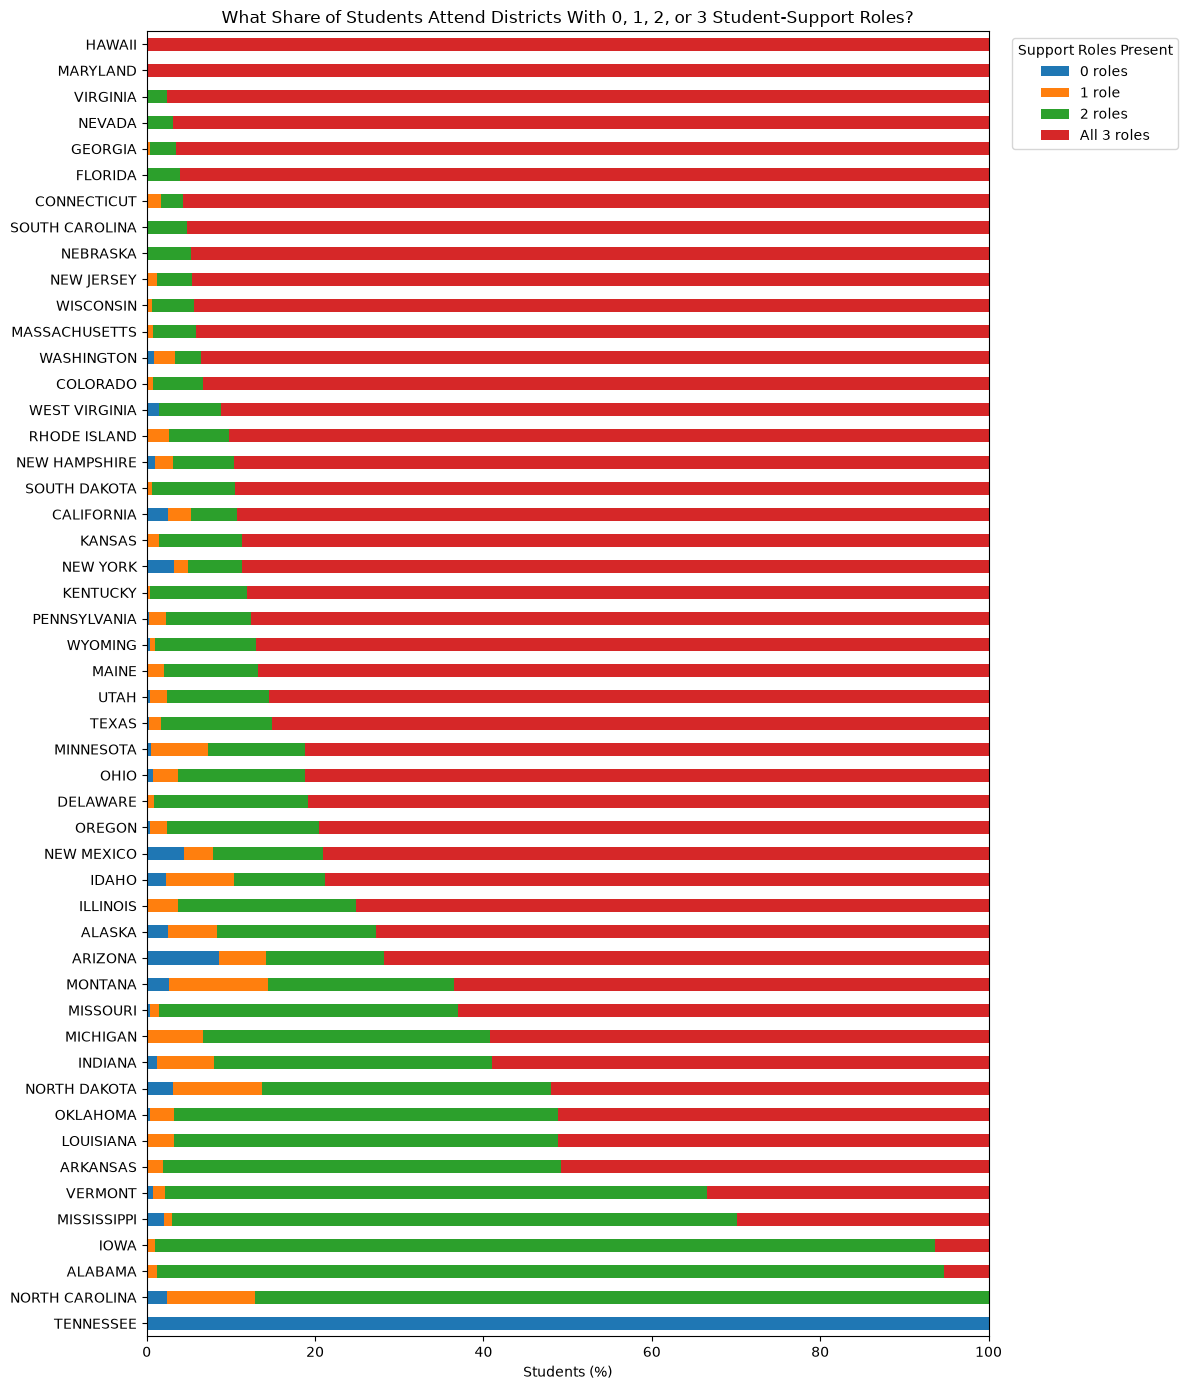

In [49]:
student_access_chart = (
    student_access_pivot
    .sort_values("3_ROLES", ascending=True)
)

ax = student_access_chart.plot(
    kind="barh",
    stacked=True,
    figsize=(12, 14)
)

plt.xlabel("Students (%)")
plt.ylabel("")
plt.title(
    "What Share of Students Attend Districts With 0, 1, 2, or 3 Student-Support Roles?"
)

plt.legend(
    [
        "0 roles",
        "1 role",
        "2 roles",
        "All 3 roles"
    ],
    title="Support Roles Present",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

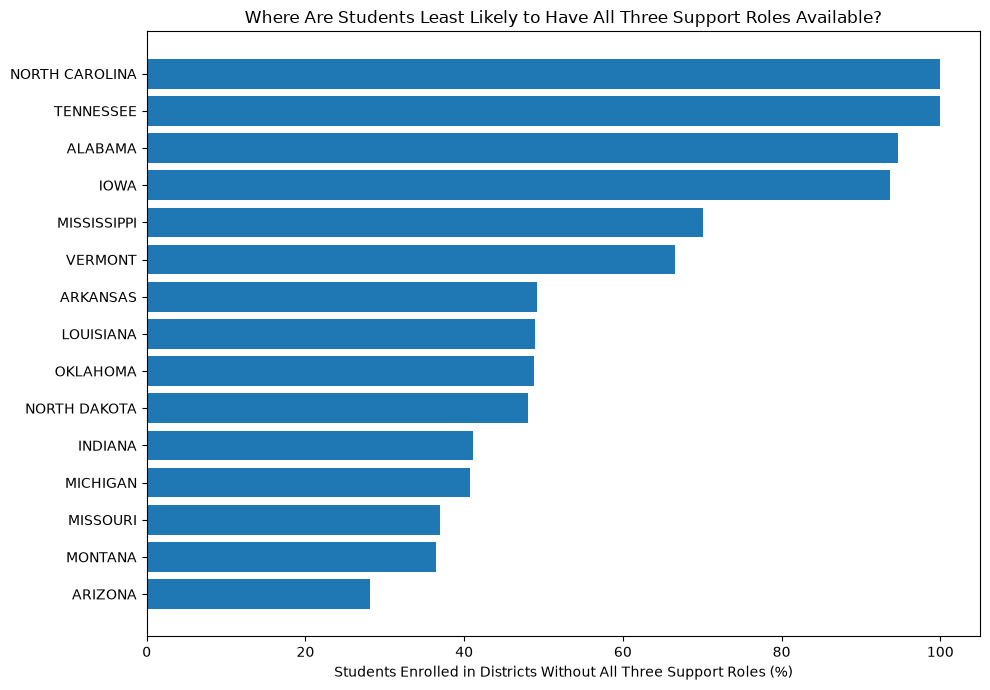

In [50]:
students_without_all_three = (
    student_access_pivot
    .assign(
        LESS_THAN_3_ROLES=lambda x:
        x["0_ROLES"] + x["1_ROLE"] + x["2_ROLES"]
    )
    .sort_values("LESS_THAN_3_ROLES", ascending=False)
    .head(15)
    .sort_values("LESS_THAN_3_ROLES")
)

plt.figure(figsize=(10, 7))

plt.barh(
    students_without_all_three.index,
    students_without_all_three["LESS_THAN_3_ROLES"]
)

plt.xlabel(
    "Students Enrolled in Districts Without All Three Support Roles (%)"
)
plt.ylabel("")

plt.title(
    "Where Are Students Least Likely to Have All Three Support Roles Available?"
)

plt.tight_layout()
plt.show()

## Specific Student-Support Role Combinations

The number of support-role types present does not identify which specific roles are available.

Districts with one support role may have a counselor, psychologist, or broader student-support staff member. Districts with two roles may also have different combinations.

To distinguish these staffing environments, districts are classified into eight possible combinations of the three support roles.

In [51]:
def support_combination(row):
    roles = []

    if row["HAS_GUIDANCE_COUNSELOR"] == 1:
        roles.append("Counselor")

    if row["HAS_PSYCHOLOGIST"] == 1:
        roles.append("Psychologist")

    if row["HAS_SUPPORT_STAFF"] == 1:
        roles.append("Support Staff")

    if len(roles) == 0:
        return "None"

    return " + ".join(roles)


staffing_50["SUPPORT_ROLE_COMBINATION"] = staffing_50.apply(
    support_combination,
    axis=1
)

staffing_50["SUPPORT_ROLE_COMBINATION"].value_counts()

SUPPORT_ROLE_COMBINATION
Counselor + Psychologist + Support Staff    7207
Counselor + Support Staff                   4920
None                                        1836
Support Staff                               1597
Counselor                                   1029
Psychologist + Support Staff                 724
Counselor + Psychologist                     353
Psychologist                                  94
Name: count, dtype: int64

In [52]:
student_combination_access = (
    staffing_50
    .dropna(subset=["TOTAL_ENROLLMENT"])
    .groupby(
        ["STATENAME", "SUPPORT_ROLE_COMBINATION"],
        as_index=False
    )["TOTAL_ENROLLMENT"]
    .sum()
)

state_enrollment_total = (
    student_combination_access
    .groupby("STATENAME")["TOTAL_ENROLLMENT"]
    .transform("sum")
)

student_combination_access["STUDENT_PCT"] = (
    student_combination_access["TOTAL_ENROLLMENT"]
    / state_enrollment_total
    * 100
)

student_combination_access.head()

,STATENAME,SUPPORT_ROLE_COMBINATION,TOTAL_ENROLLMENT,STUDENT_PCT
0,ALABAMA,Counselor,7950.0,1.058504
1,ALABAMA,Counselor + Psychologist + Support Staff,39657.0,5.280137
2,ALABAMA,Counselor + Support Staff,702123.0,93.484276
3,ALABAMA,None,757.0,0.100791
4,ALABAMA,Support Staff,573.0,0.076292


In [53]:
combination_pivot = (
    student_combination_access
    .pivot(
        index="STATENAME",
        columns="SUPPORT_ROLE_COMBINATION",
        values="STUDENT_PCT"
    )
    .fillna(0)
)

combination_pivot.round(1)

SUPPORT_ROLE_COMBINATION,Counselor,Counselor + Psychologist,Counselor + Psychologist + Support Staff,Counselor + Support Staff,None,Psychologist,Psychologist + Support Staff,Support Staff
STATENAME,,,,,,,,
ALABAMA,1.1,0.0,5.3,93.5,0.1,0.0,0.0,0.1
ALASKA,5.0,0.3,72.8,18.6,2.6,0.0,0.0,0.8
ARIZONA,0.6,0.0,71.8,9.7,8.6,0.0,4.3,5.0
ARKANSAS,1.1,0.0,50.8,47.2,0.0,0.0,0.1,0.8
CALIFORNIA,1.9,2.3,89.2,0.9,2.6,0.5,2.2,0.3
COLORADO,0.2,0.0,93.3,5.9,0.1,0.0,0.0,0.5
CONNECTICUT,0.0,0.0,95.6,1.4,0.0,0.0,1.2,1.7
DELAWARE,0.0,0.0,80.8,17.8,0.0,0.0,0.5,0.9
FLORIDA,0.0,0.0,96.0,3.9,0.0,0.0,0.1,0.0


## Student Access by Specific Support-Role Combination

The previous analysis counted how many support-role types were present. This analysis identifies the specific combination of roles available to students.

Each state's bar represents 100% of students and is divided according to the staffing combination reported by their district.

This makes it possible to distinguish, for example, students in districts with two roles consisting of counselor + psychologist from students in districts with counselor + broader support staff.

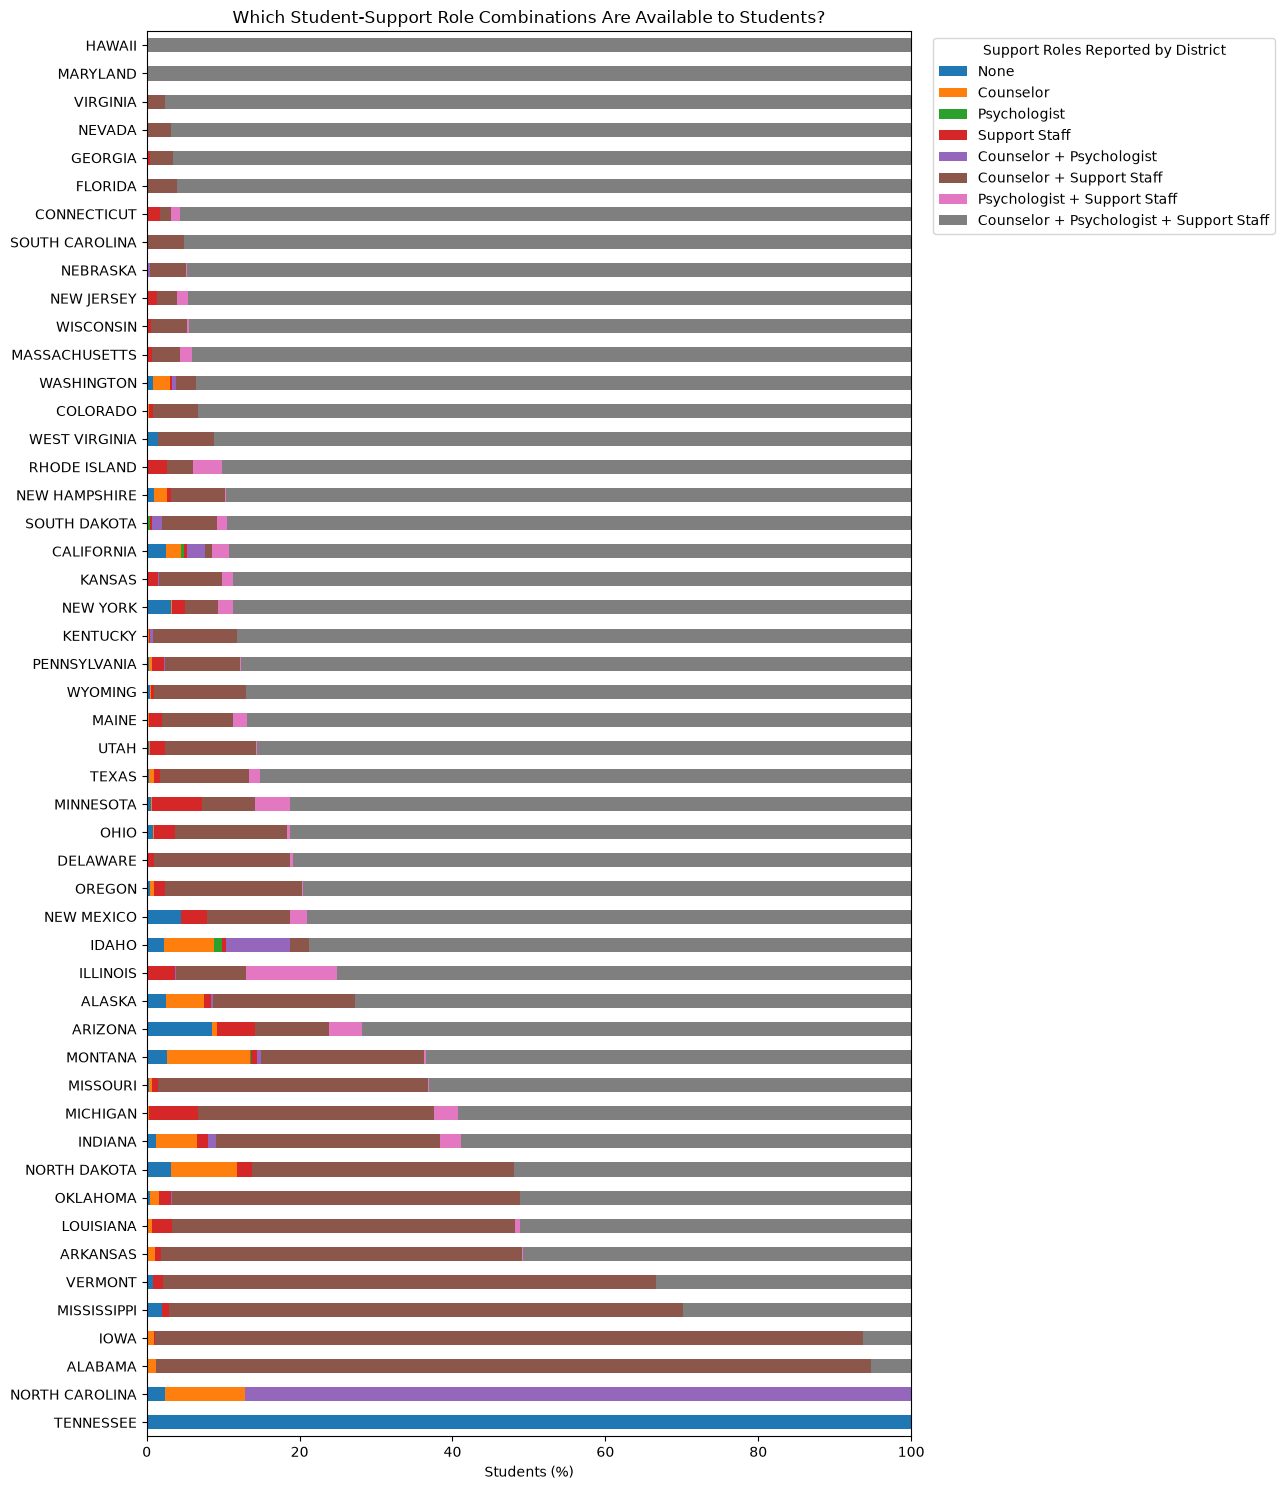

In [54]:
# Put combinations in a logical order

combination_order = [
    "None",
    "Counselor",
    "Psychologist",
    "Support Staff",
    "Counselor + Psychologist",
    "Counselor + Support Staff",
    "Psychologist + Support Staff",
    "Counselor + Psychologist + Support Staff"
]

# Make sure every possible combination exists as a column
combination_chart = combination_pivot.reindex(
    columns=combination_order,
    fill_value=0
)

# Sort states by percentage of students with all 3 roles
combination_chart = combination_chart.sort_values(
    "Counselor + Psychologist + Support Staff",
    ascending=True
)

ax = combination_chart.plot(
    kind="barh",
    stacked=True,
    figsize=(13, 15)
)

plt.xlabel("Students (%)")
plt.ylabel("")

plt.title(
    "Which Student-Support Role Combinations Are Available to Students?"
)

plt.legend(
    title="Support Roles Reported by District",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xlim(0, 100)

plt.tight_layout()
plt.show()

## Statistical Relationships Among District Staffing Measures

Correlation analysis is used to examine whether different student-support staffing measures tend to vary together across school districts.

The analysis focuses on:

- students per guidance counselor
- students per school psychologist
- students per broader student-support staff member
- students per teacher
- district enrollment

Higher student-to-staff ratios indicate lower staffing capacity.

In [55]:
nonfiscal_corr_vars = [
    "TOTAL_ENROLLMENT",
    "STUDENTS_PER_GUIDANCE_COUNSELOR",
    "STUDENTS_PER_PSYCHOLOGIST",
    "STUDENTS_PER_SUPPORT_STAFF",
    "STUDENTS_PER_TEACHER"
]

nonfiscal_correlations = (
    district_staffing[nonfiscal_corr_vars]
    .corr()
    .round(2)
)

nonfiscal_correlations

,TOTAL_ENROLLMENT,STUDENTS_PER_GUIDANCE_COUNSELOR,STUDENTS_PER_PSYCHOLOGIST,STUDENTS_PER_SUPPORT_STAFF,STUDENTS_PER_TEACHER
TOTAL_ENROLLMENT,1.00,-0.00,0.06,0.00,0.02
STUDENTS_PER_GUIDANCE_COUNSELOR,-0.00,1.00,0.06,0.02,0.05
STUDENTS_PER_PSYCHOLOGIST,0.06,0.06,1.00,0.03,0.04
STUDENTS_PER_SUPPORT_STAFF,0.00,0.02,0.03,1.00,0.13
STUDENTS_PER_TEACHER,0.02,0.05,0.04,0.13,1.00


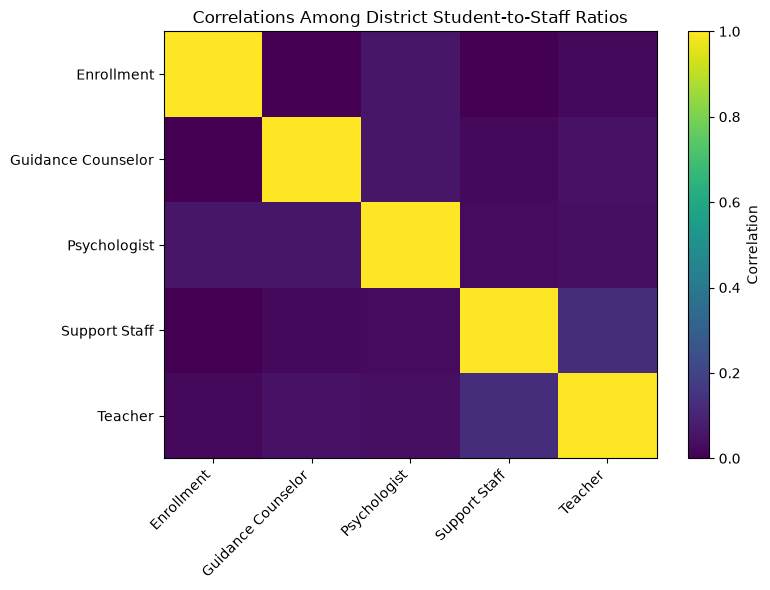

In [56]:
plt.figure(figsize=(8, 6))

plt.imshow(
    nonfiscal_correlations,
    aspect="auto"
)

plt.colorbar(label="Correlation")

labels = [
    "Enrollment",
    "Guidance Counselor",
    "Psychologist",
    "Support Staff",
    "Teacher"
]

plt.xticks(
    range(len(labels)),
    labels,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(labels)),
    labels
)

plt.title(
    "Correlations Among District Student-to-Staff Ratios"
)

plt.tight_layout()
plt.show()

In [57]:
import nbformat
from pathlib import Path
from copy import deepcopy

source_path = Path("04_nces_nonfiscal_data_analysis.ipynb")
final_path = Path("../Final_Data_Analysis/07_full_project_analysis.ipynb")

# Load notebooks
with open(source_path, "r", encoding="utf-8") as f:
    source_nb = nbformat.read(f, as_version=4)

with open(final_path, "r", encoding="utf-8") as f:
    final_nb = nbformat.read(f, as_version=4)

# Find the NCES Nonfiscal section in the final notebook
start_idx = None
end_idx = None

for i, cell in enumerate(final_nb.cells):
    if cell.cell_type == "markdown":
        text = cell.source.lower()

        if "nces nonfiscal" in text or "nces non-fiscal" in text:
            start_idx = i
            break

if start_idx is None:
    raise ValueError("Could not find the NCES Nonfiscal section in the final notebook.")

# Find the next major dataset section
for i in range(start_idx + 1, len(final_nb.cells)):
    cell = final_nb.cells[i]

    if cell.cell_type == "markdown" and cell.source.startswith("# "):
        end_idx = i
        break

if end_idx is None:
    end_idx = len(final_nb.cells)

# Copy the completed Nonfiscal notebook cells
new_cells = [deepcopy(cell) for cell in source_nb.cells]

# Replace the placeholder section
final_nb.cells[start_idx:end_idx] = new_cells

# Save
with open(final_path, "w", encoding="utf-8") as f:
    nbformat.write(final_nb, f)

print("NCES Nonfiscal cells inserted:", len(new_cells))
print("Saved final notebook:", final_path)

NCES Nonfiscal cells inserted: 59
Saved final notebook: ..\Final_Data_Analysis\07_full_project_analysis.ipynb


# HRSA Mental Health Professional Shortage Area (HPSA) Data Analysis

## Purpose

The Health Resources and Services Administration (HRSA) Health Professional Shortage Area data identify communities with shortages of mental health professionals.

For this project, the HPSA data provide a healthcare-access and provider-capacity perspective that complements the child, family, community, school, and school-funding measures examined in the other datasets.

The analysis focuses on:

- where mental health professional shortages are located
- how shortage severity varies across communities and states
- population affected by mental health professional shortages
- differences in provider need and existing capacity
- states and communities with particularly high shortage burden

These measures help identify communities where children and families may face structural barriers to obtaining mental health care even when care is needed.

In [1]:
from pathlib import Path

cleaned_dir = Path("../../data/cleaned")

hpsa_files = list(cleaned_dir.glob("*HPSA*")) + list(cleaned_dir.glob("*hpsa*"))

for file in hpsa_files:
    print(file.name)

HPSA_20206_snapshot_mental_health_cleaned.csv
HPSA_20206_snapshot_mental_health_cleaned.csv


In [2]:
import pandas as pd
from pathlib import Path

cleaned_dir = Path("../../data/cleaned")

hpsa_path = cleaned_dir / "HPSA_20206_snapshot_mental_health_cleaned.csv"

hpsa = pd.read_csv(hpsa_path)

print("Shape:", hpsa.shape)
print()
print("Columns:")
for col in hpsa.columns:
    print(col)

Shape: (13836, 26)

Columns:
HPSA ID
HPSA Name
Designation Type
HPSA Discipline Class
HPSA Score
HPSA Status
HPSA Designation Date
HPSA Designation Last Update Date
Primary State Abbreviation
Common State FIPS Code
Common County Name
Common State County FIPS Code
HPSA Geography Identification Number
Latitude
Longitude
HPSA Designation Population
HPSA Estimated Served Population
HPSA Estimated Underserved Population
% of Population Below 100% Poverty
HPSA Population Type
HPSA FTE
HPSA Formal Ratio
HPSA Provider Ratio Goal
HPSA Shortage
Rural Status
Metropolitan Indicator


In [3]:
hpsa.head()

,HPSA ID,HPSA Name,Designation Type,HPSA Discipline Class,HPSA Score,HPSA Status,HPSA Designation Date,HPSA Designation Last Update Date,Primary State Abbreviation,Common State FIPS Code,...,HPSA Estimated Served Population,HPSA Estimated Underserved Population,% of Population Below 100% Poverty,HPSA Population Type,HPSA FTE,HPSA Formal Ratio,HPSA Provider Ratio Goal,HPSA Shortage,Rural Status,Metropolitan Indicator
0,7568613844,Southwest Wyoming,High Needs Geographic HPSA,Mental Health,18,Designated,2012-03-20,2025-09-22,WY,56,...,21000.0,92486.0,9.5,Geographic Population,1.05,108082:1,20000:1,6.52,Rural,Unknown
1,7568613844,Southwest Wyoming,High Needs Geographic HPSA,Mental Health,18,Designated,2012-03-20,2025-09-22,WY,56,...,21000.0,92486.0,9.5,Geographic Population,1.05,108082:1,20000:1,6.52,Rural,Unknown
2,7568613844,Southwest Wyoming,High Needs Geographic HPSA,Mental Health,18,Designated,2012-03-20,2025-09-22,WY,56,...,21000.0,92486.0,9.5,Geographic Population,1.05,108082:1,20000:1,6.52,Rural,Unknown
3,7568613844,Southwest Wyoming,High Needs Geographic HPSA,Mental Health,18,Designated,2012-03-20,2025-09-22,WY,56,...,21000.0,92486.0,9.5,Geographic Population,1.05,108082:1,20000:1,6.52,Rural,Unknown
4,7568613844,Southwest Wyoming,High Needs Geographic HPSA,Mental Health,18,Designated,2012-03-20,2025-09-22,WY,56,...,21000.0,92486.0,9.5,Geographic Population,1.05,108082:1,20000:1,6.52,Rural,Unknown


In [4]:
hpsa.info()

<class 'pandas.DataFrame'>
RangeIndex: 13836 entries, 0 to 13835
Data columns (total 26 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   HPSA ID                                13836 non-null  str    
 1   HPSA Name                              13836 non-null  str    
 2   Designation Type                       13836 non-null  str    
 3   HPSA Discipline Class                  13836 non-null  str    
 4   HPSA Score                             13836 non-null  int64  
 5   HPSA Status                            13836 non-null  str    
 6   HPSA Designation Date                  13836 non-null  str    
 7   HPSA Designation Last Update Date      13836 non-null  str    
 8   Primary State Abbreviation             13836 non-null  str    
 9   Common State FIPS Code                 13836 non-null  int64  
 10  Common County Name                     13836 non-null  str    
 11  Common State 

## Dataset Structure and Designation Records

The cleaned HPSA dataset contains 13,836 records and 26 variables describing designated mental health professional shortage areas.

Key measures include:

- **HPSA Score** — shortage severity score
- **HPSA Designation Population** — population included in the shortage designation
- **HPSA Estimated Served Population** — population estimated to have access to available providers
- **HPSA Estimated Underserved Population** — population estimated to remain underserved
- **HPSA FTE** — estimated full-time-equivalent provider capacity
- **HPSA Shortage** — additional provider capacity needed to meet the designated population-to-provider goal
- **poverty, rural status, and metropolitan status** — community context for interpreting shortage patterns

Because a single HPSA designation can appear across multiple geographic records, the analysis first examines the structure of repeated HPSA IDs before aggregating shortage measures.

In [5]:
print("Rows:", len(hpsa))
print("Unique HPSA IDs:", hpsa["HPSA ID"].nunique())
print()

print("HPSA statuses:")
print(hpsa["HPSA Status"].value_counts())
print()

print("Designation types:")
print(hpsa["Designation Type"].value_counts())
print()

print("Rows per HPSA ID:")
print(
    hpsa.groupby("HPSA ID")
    .size()
    .describe()
)

Rows: 13836
Unique HPSA IDs: 6420

HPSA statuses:
HPSA Status
Designated    13836
Name: count, dtype: int64

Designation types:
Designation Type
HPSA Population                                                                5793
Geographic HPSA                                                                1931
Rural Health Clinic                                                            1835
Federally Qualified Health Center                                              1351
High Needs Geographic HPSA                                                     1195
Indian Health Service, Tribal Health, and Urban Indian Health Organizations     928
Correctional Facility                                                           576
Federally Qualified Health Center Look A Like                                   171
State Mental Hospital                                                            34
Other Facility                                                                   22
Name: count, dt

In [6]:
hpsa.groupby("HPSA ID").agg(
    ROWS=("HPSA ID", "size"),
    STATES=("Primary State Abbreviation", "nunique"),
    COUNTIES=("Common State County FIPS Code", "nunique"),
    SCORE_VALUES=("HPSA Score", "nunique"),
    POPULATION_VALUES=("HPSA Designation Population", "nunique"),
    SHORTAGE_VALUES=("HPSA Shortage", "nunique")
).sort_values("ROWS", ascending=False).head(15)

,ROWS,STATES,COUNTIES,SCORE_VALUES,POPULATION_VALUES,SHORTAGE_VALUES
HPSA ID,,,,,,
7066901765,151,1,1,1,1,1
7171440011,129,1,1,1,1,1
7442010579,126,1,1,1,1,1
7552391298,122,1,1,1,1,1
7329101749,114,1,1,1,1,1
7362607440,110,1,1,1,1,1
7266584666,104,1,1,1,1,1
7265464602,99,1,1,1,1,1
7365289316,93,1,1,1,1,1


## HPSA-Level Analysis Dataset

The raw cleaned file contains 13,836 geographic records but only 6,420 unique HPSA designations.

Most HPSA IDs appear once, but some designations are represented by many geographic records. The largest designation appears 151 times. Examination of these repeated records shows that core designation-level measures such as HPSA score, designation population, and provider shortage remain constant within the repeated HPSA ID.

To avoid counting the same shortage designation multiple times, subsequent analyses use one record per unique HPSA ID.

In [7]:
# Create one record per unique HPSA designation

hpsa_unique = (
    hpsa
    .sort_values("HPSA ID")
    .drop_duplicates(subset="HPSA ID", keep="first")
    .copy()
)

print("Original rows:", len(hpsa))
print("Unique HPSA analysis rows:", len(hpsa_unique))
print("Duplicate HPSA IDs remaining:", hpsa_unique["HPSA ID"].duplicated().sum())

Original rows: 13836
Unique HPSA analysis rows: 6420
Duplicate HPSA IDs remaining: 0


In [8]:
shortage_measures = [
    "HPSA Score",
    "HPSA Designation Population",
    "HPSA Estimated Served Population",
    "HPSA Estimated Underserved Population",
    "HPSA FTE",
    "HPSA Shortage",
    "% of Population Below 100% Poverty"
]

hpsa_unique[shortage_measures].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
HPSA Score,6420.0,16.36,3.60,0.0,15.00,17.00,19.00,25.00
HPSA Designation Population,6397.0,74065.48,125055.79,23.0,8785.00,33279.00,85557.00,1762049.00
HPSA Estimated Served Population,1503.0,23326.63,63110.26,0.0,0.00,0.00,20015.00,924000.00
HPSA Estimated Underserved Population,1503.0,42590.54,65392.08,51.0,9775.00,21833.00,49899.00,867776.00
HPSA FTE,2113.0,0.87,2.69,0.0,0.00,0.00,0.75,55.85
HPSA Shortage,2079.0,2.56,4.42,0.0,0.56,1.19,2.76,70.80
% of Population Below 100% Poverty,1503.0,16.72,9.27,1.7,11.35,14.50,18.80,80.00


## Measure Availability by HPSA Designation Type

Not all HPSA measures are reported for every designation type.

While HPSA Score is available for all unique designations, provider-capacity, underserved-population, and poverty measures are available for smaller subsets of the data.

Before comparing shortage measures across communities or states, the analysis examines which designation types contain these measures. This prevents missing values from being interpreted as zero shortage or zero provider capacity.

In [9]:
measure_availability = (
    hpsa_unique
    .groupby("Designation Type")
    .agg(
        HPSA_COUNT=("HPSA ID", "size"),
        SCORE_AVAILABLE=("HPSA Score", "count"),
        POPULATION_AVAILABLE=("HPSA Designation Population", "count"),
        UNDERSERVED_AVAILABLE=("HPSA Estimated Underserved Population", "count"),
        FTE_AVAILABLE=("HPSA FTE", "count"),
        SHORTAGE_AVAILABLE=("HPSA Shortage", "count"),
        POVERTY_AVAILABLE=("% of Population Below 100% Poverty", "count")
    )
    .sort_values("HPSA_COUNT", ascending=False)
)

measure_availability

,HPSA_COUNT,SCORE_AVAILABLE,POPULATION_AVAILABLE,UNDERSERVED_AVAILABLE,FTE_AVAILABLE,SHORTAGE_AVAILABLE,POVERTY_AVAILABLE
Designation Type,,,,,,,
Rural Health Clinic,1835,1835,1835,0,0,0,0
Federally Qualified Health Center,1351,1351,1351,0,0,0,0
"Indian Health Service, Tribal Health, and Urban Indian Health Organizations",928,928,927,0,0,0,0
HPSA Population,661,661,661,661,661,661,661
Correctional Facility,576,576,576,0,576,576,0
Geographic HPSA,481,481,481,481,481,481,481
High Needs Geographic HPSA,361,361,361,361,361,361,361
Federally Qualified Health Center Look A Like,171,171,171,0,0,0,0
State Mental Hospital,34,34,34,0,34,0,0


## Community-Based Mental Health Shortage Areas

Detailed population and community-context measures are available for three designation types:

- HPSA Population
- Geographic HPSA
- High Needs Geographic HPSA

Together, these account for 1,503 unique HPSA designations.

These records include estimated underserved population, provider capacity, provider shortage, and poverty measures, making them the primary subset for examining community-level mental health access barriers.

Facility-based designations remain part of the broader HPSA landscape but are not directly comparable on these population-based measures.

In [10]:
community_types = [
    "HPSA Population",
    "Geographic HPSA",
    "High Needs Geographic HPSA"
]

hpsa_community = (
    hpsa_unique[
        hpsa_unique["Designation Type"].isin(community_types)
    ]
    .copy()
)

print("Community-based HPSAs:", len(hpsa_community))

print()
print(hpsa_community["Designation Type"].value_counts())

Community-based HPSAs: 1503

Designation Type
HPSA Population               661
Geographic HPSA               481
High Needs Geographic HPSA    361
Name: count, dtype: int64


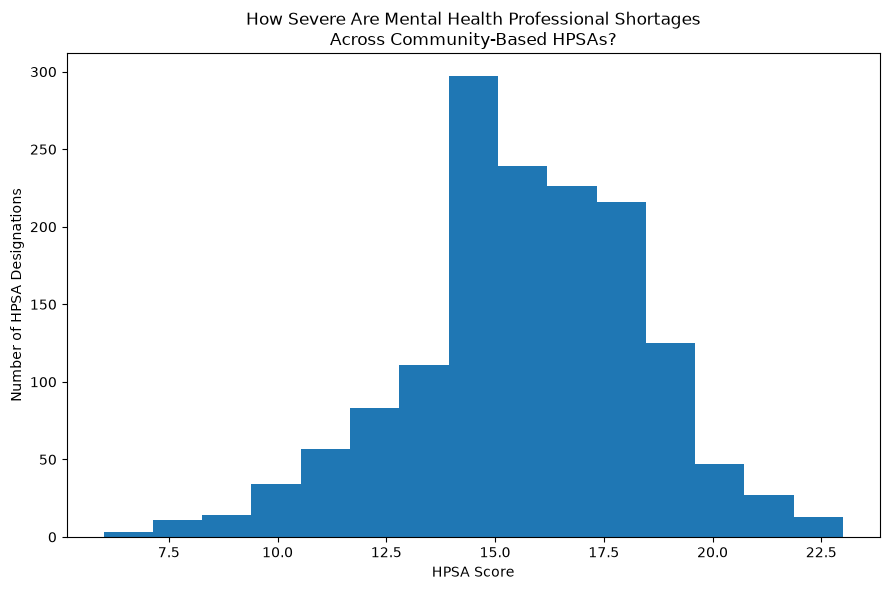

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

plt.hist(
    hpsa_community["HPSA Score"].dropna(),
    bins=15
)

plt.xlabel("HPSA Score")
plt.ylabel("Number of HPSA Designations")

plt.title(
    "How Severe Are Mental Health Professional Shortages\n"
    "Across Community-Based HPSAs?"
)

plt.tight_layout()
plt.show()

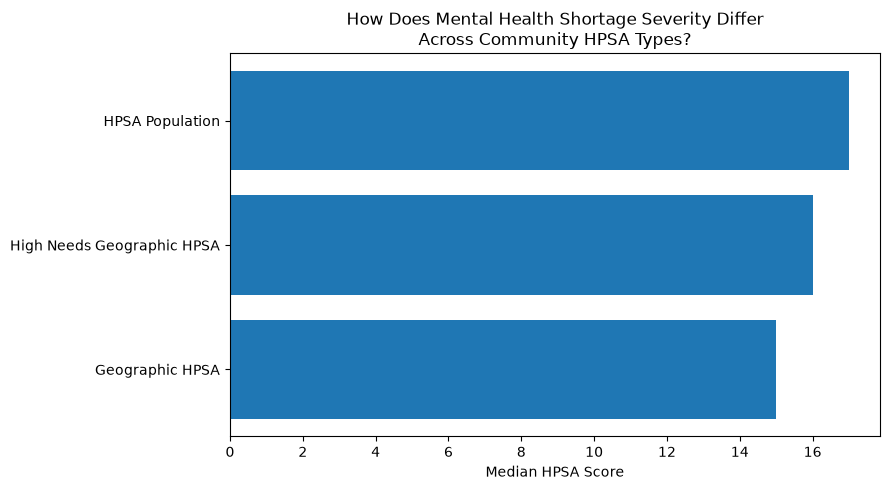

In [12]:
score_by_type = (
    hpsa_community
    .groupby("Designation Type")["HPSA Score"]
    .median()
    .sort_values()
)

plt.figure(figsize=(9, 5))

plt.barh(
    score_by_type.index,
    score_by_type.values
)

plt.xlabel("Median HPSA Score")
plt.ylabel("")

plt.title(
    "How Does Mental Health Shortage Severity Differ\n"
    "Across Community HPSA Types?"
)

plt.tight_layout()
plt.show()

## State-Level Mental Health Shortage Burden

Community-based HPSA designations are summarized by state to identify where mental health professional shortages are most concentrated.

State comparisons focus on:

- number of community-based mental health HPSA designations
- median HPSA shortage severity score
- total estimated underserved population
- median provider shortage

Formal state comparisons include the 50 U.S. states only.

In [21]:
states_50_abbr = [
    "AL","AK","AZ","AR","CA","CO","CT","DE","FL","GA",
    "HI","ID","IL","IN","IA","KS","KY","LA","ME","MD",
    "MA","MI","MN","MS","MO","MT","NE","NV","NH","NJ",
    "NM","NY","NC","ND","OH","OK","OR","PA","RI","SC",
    "SD","TN","TX","UT","VT","VA","WA","WV","WI","WY"
]

hpsa_50 = hpsa_community[
    hpsa_community["Primary State Abbreviation"].isin(states_50_abbr)
].copy()

print("Community HPSAs in 50 states:", len(hpsa_50))
print("States represented:", hpsa_50["Primary State Abbreviation"].nunique())

Community HPSAs in 50 states: 1438
States represented: 49


In [22]:
missing_states = sorted(
    set(states_50_abbr)
    - set(hpsa_50["Primary State Abbreviation"].dropna().unique())
)

print("States with no community-based HPSA records:")
print(missing_states)

States with no community-based HPSA records:
['VT']


Formal state comparisons are restricted to the 50 U.S. states. Of those, 49 have at least one community-based mental health HPSA designation in this dataset.

In [23]:
state_hpsa = (
    hpsa_50
    .groupby("Primary State Abbreviation")
    .agg(
        HPSA_COUNT=("HPSA ID", "size"),
        MEDIAN_HPSA_SCORE=("HPSA Score", "median"),
        TOTAL_UNDERSERVED_POPULATION=(
            "HPSA Estimated Underserved Population",
            "sum"
        ),
        MEDIAN_PROVIDER_SHORTAGE=("HPSA Shortage", "median"),
        MEDIAN_POVERTY=(
            "% of Population Below 100% Poverty",
            "median"
        )
    )
    .reset_index()
)

state_hpsa.head()

,Primary State Abbreviation,HPSA_COUNT,MEDIAN_HPSA_SCORE,TOTAL_UNDERSERVED_POPULATION,MEDIAN_PROVIDER_SHORTAGE,MEDIAN_POVERTY
0,AK,16,15.0,221866.0,0.520,10.90
1,AL,10,17.0,633822.0,3.891,17.90
2,AR,11,18.0,445820.0,3.590,17.30
3,AZ,70,16.0,1524783.0,0.848,15.95
4,CA,42,16.0,1872541.0,1.765,14.90


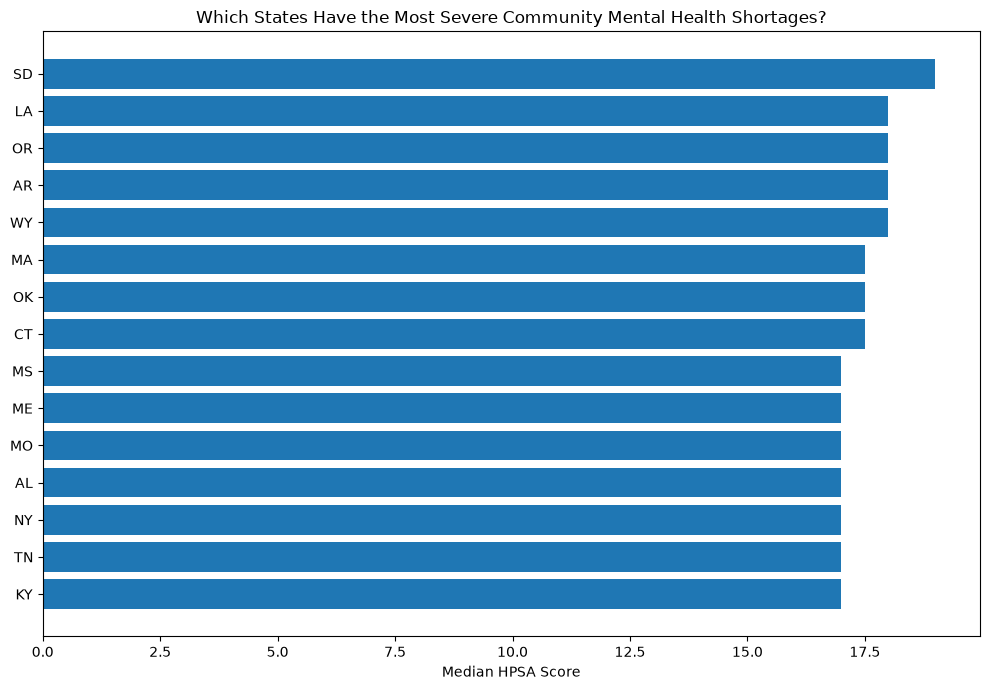

In [24]:
highest_score_states = (
    state_hpsa
    .sort_values("MEDIAN_HPSA_SCORE", ascending=False)
    .head(15)
    .sort_values("MEDIAN_HPSA_SCORE")
)

plt.figure(figsize=(10, 7))

plt.barh(
    highest_score_states["Primary State Abbreviation"],
    highest_score_states["MEDIAN_HPSA_SCORE"]
)

plt.xlabel("Median HPSA Score")
plt.ylabel("")

plt.title(
    "Which States Have the Most Severe Community Mental Health Shortages?"
)

plt.tight_layout()
plt.show()

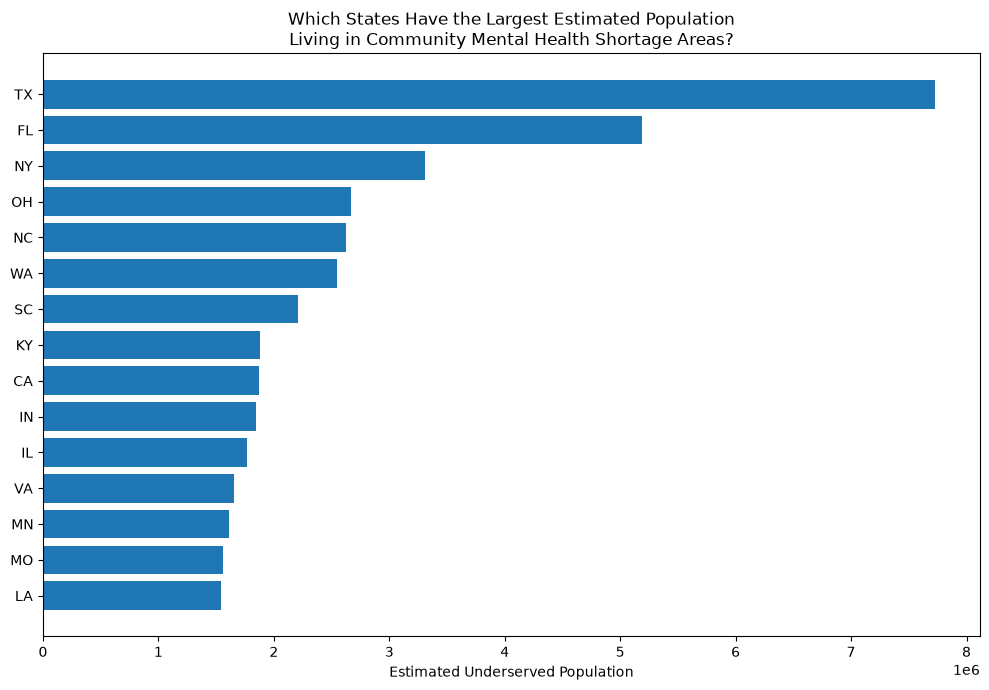

In [25]:
highest_underserved_states = (
    state_hpsa
    .sort_values("TOTAL_UNDERSERVED_POPULATION", ascending=False)
    .head(15)
    .sort_values("TOTAL_UNDERSERVED_POPULATION")
)

plt.figure(figsize=(10, 7))

plt.barh(
    highest_underserved_states["Primary State Abbreviation"],
    highest_underserved_states["TOTAL_UNDERSERVED_POPULATION"]
)

plt.xlabel("Estimated Underserved Population")
plt.ylabel("")

plt.title(
    "Which States Have the Largest Estimated Population\n"
    "Living in Community Mental Health Shortage Areas?"
)

plt.tight_layout()
plt.show()

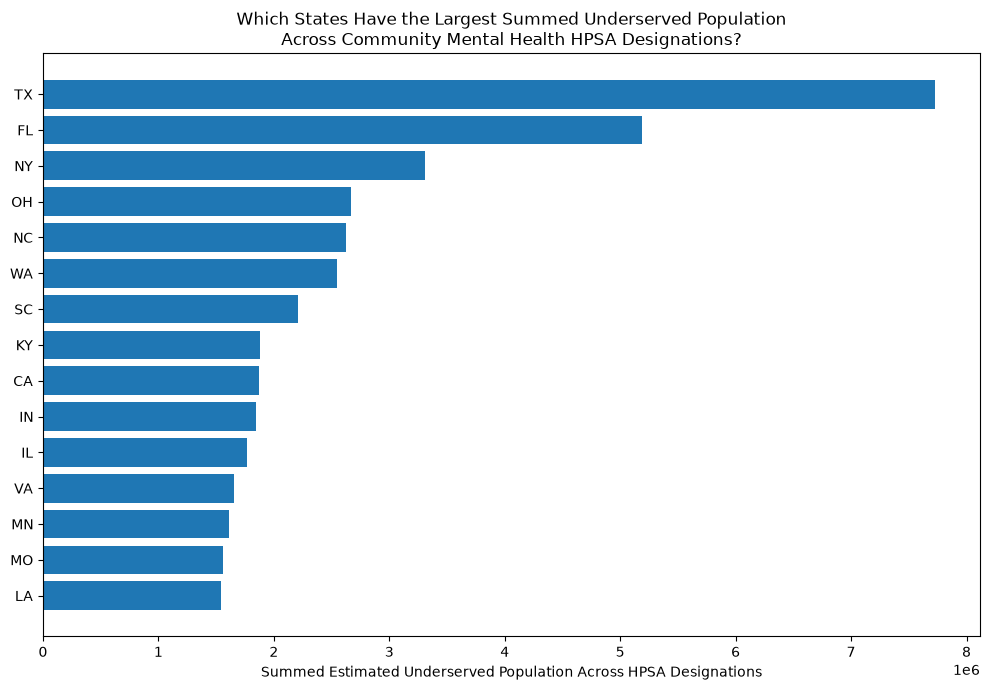

In [26]:
highest_underserved_states = (
    state_hpsa
    .sort_values("TOTAL_UNDERSERVED_POPULATION", ascending=False)
    .head(15)
    .sort_values("TOTAL_UNDERSERVED_POPULATION")
)

plt.figure(figsize=(10, 7))

plt.barh(
    highest_underserved_states["Primary State Abbreviation"],
    highest_underserved_states["TOTAL_UNDERSERVED_POPULATION"]
)

plt.xlabel("Summed Estimated Underserved Population Across HPSA Designations")
plt.ylabel("")

plt.title(
    "Which States Have the Largest Summed Underserved Population\n"
    "Across Community Mental Health HPSA Designations?"
)

plt.tight_layout()
plt.show()

### State-Level Findings

State-level HPSA patterns differ depending on whether shortage **severity** or shortage **scale** is examined.

South Dakota had the highest median community HPSA score, followed by a group of states including Louisiana, Oregon, Arkansas, and Wyoming. These results indicate that the typical community-based shortage designation in these states is relatively severe.

A different pattern appears when examining the summed estimated underserved population across HPSA designations. Texas had by far the largest total, followed by Florida and New York. North Carolina, South Carolina, and Louisiana also appeared among the states with the largest summed underserved populations.

This distinction is important: a state may have highly severe shortage areas without having the largest population affected, while populous states may have a large shortage burden even when their median HPSA severity score is lower.

Summed underserved-population estimates represent totals across HPSA designations and should not be interpreted as a count of unique state residents because designations may overlap.

## Statistical Relationships Among Community HPSA Measures

Because several HPSA measures are strongly skewed, Spearman rank correlations are used to examine whether higher shortage severity tends to occur alongside greater provider shortage, larger underserved populations, and higher poverty levels.

The analysis focuses on:

- HPSA Score
- HPSA Shortage
- HPSA FTE
- estimated underserved population
- designation population
- percent of population below 100% of the federal poverty level

Spearman correlation measures whether variables tend to increase or decrease together based on their ranked values rather than assuming a linear relationship.

In [27]:
hpsa_corr_vars = [
    "HPSA Score",
    "HPSA Shortage",
    "HPSA FTE",
    "HPSA Estimated Underserved Population",
    "HPSA Designation Population",
    "% of Population Below 100% Poverty"
]

hpsa_spearman = (
    hpsa_50[hpsa_corr_vars]
    .corr(method="spearman")
    .round(2)
)

hpsa_spearman

,HPSA Score,HPSA Shortage,HPSA FTE,HPSA Estimated Underserved Population,HPSA Designation Population,% of Population Below 100% Poverty
HPSA Score,1.00,0.28,-0.15,0.38,0.16,0.37
HPSA Shortage,0.28,1.00,0.62,0.95,0.96,-0.05
HPSA FTE,-0.15,0.62,1.00,0.48,0.76,-0.12
HPSA Estimated Underserved Population,0.38,0.95,0.48,1.00,0.89,-0.05
HPSA Designation Population,0.16,0.96,0.76,0.89,1.00,-0.09
% of Population Below 100% Poverty,0.37,-0.05,-0.12,-0.05,-0.09,1.00


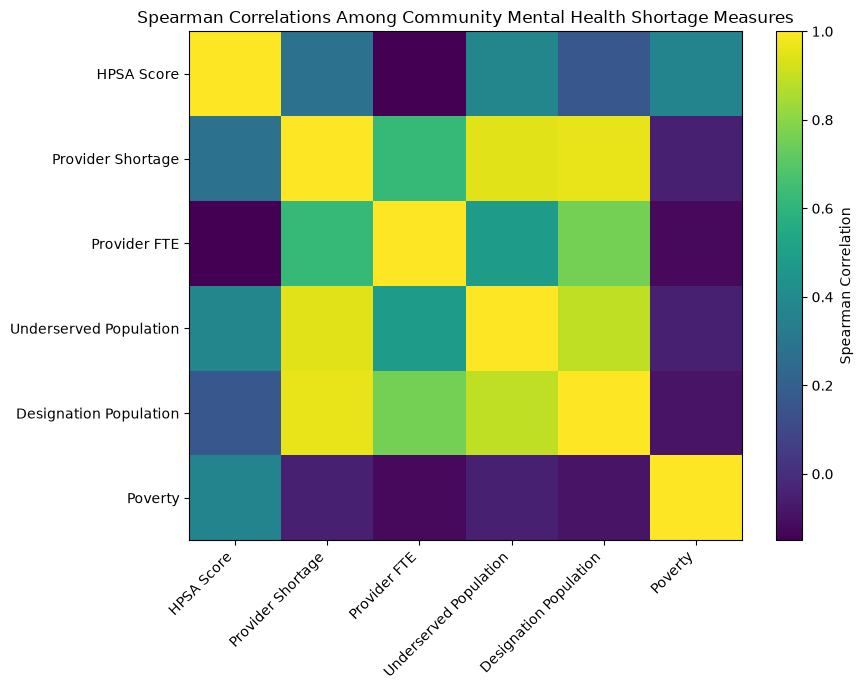

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 7))

plt.imshow(
    hpsa_spearman,
    aspect="auto"
)

plt.colorbar(label="Spearman Correlation")

labels = [
    "HPSA Score",
    "Provider Shortage",
    "Provider FTE",
    "Underserved Population",
    "Designation Population",
    "Poverty"
]

plt.xticks(
    range(len(labels)),
    labels,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(labels)),
    labels
)

plt.title(
    "Spearman Correlations Among Community Mental Health Shortage Measures"
)

plt.tight_layout()
plt.show()

In [29]:
score_correlations = (
    hpsa_spearman["HPSA Score"]
    .drop("HPSA Score")
    .sort_values(key=abs, ascending=False)
)

score_correlations

HPSA Estimated Underserved Population    0.38
% of Population Below 100% Poverty       0.37
HPSA Shortage                            0.28
HPSA Designation Population              0.16
HPSA FTE                                -0.15
Name: HPSA Score, dtype: float64

### States With Lower Median HPSA Severity

To provide context for the highest-severity states, the analysis also examines states with the lowest median HPSA scores among those represented in the community-based HPSA subset.

A lower median HPSA score indicates that the typical designated shortage area in that state is less severe relative to states with higher scores. It does not mean the state has no mental health access problems or no shortage areas.

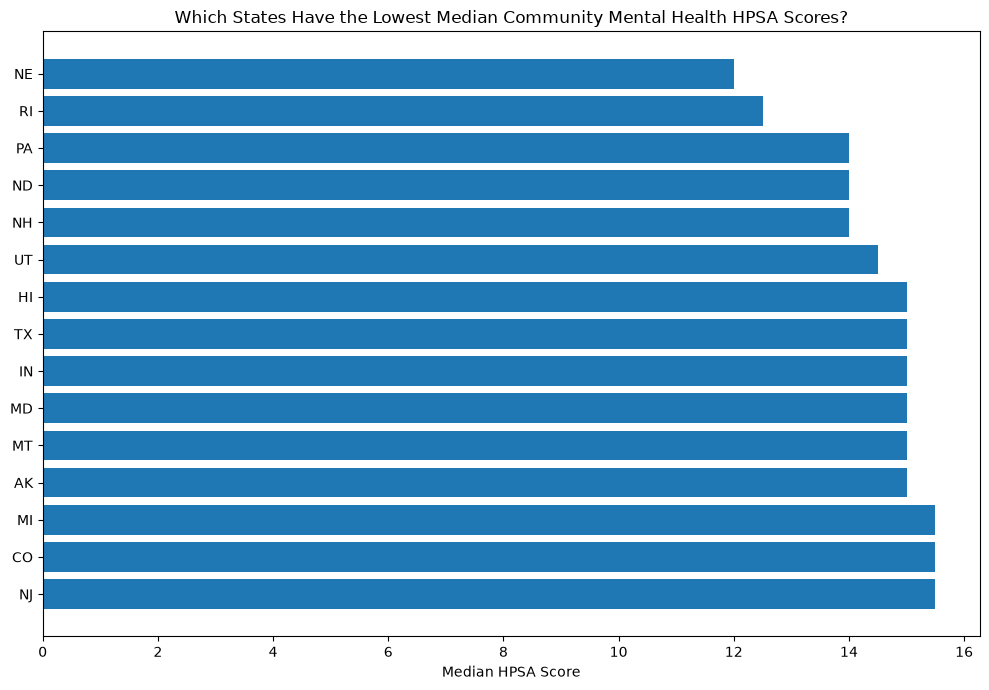

In [30]:
lowest_score_states = (
    state_hpsa
    .sort_values("MEDIAN_HPSA_SCORE", ascending=True)
    .head(15)
    .sort_values("MEDIAN_HPSA_SCORE", ascending=False)
)

plt.figure(figsize=(10, 7))

plt.barh(
    lowest_score_states["Primary State Abbreviation"],
    lowest_score_states["MEDIAN_HPSA_SCORE"]
)

plt.xlabel("Median HPSA Score")
plt.ylabel("")

plt.title(
    "Which States Have the Lowest Median Community Mental Health HPSA Scores?"
)

plt.tight_layout()
plt.show()

### Statistical Findings

Spearman correlation analysis was used because several HPSA measures are strongly skewed.

The results show that HPSA shortage severity is related to several measures of provider capacity and community need, but the relationships vary in strength.

Key patterns include:

- **HPSA Score and provider shortage:** [insert correlation]
- **HPSA Score and underserved population:** [insert correlation]
- **HPSA Score and designation population:** [insert correlation]
- **HPSA Score and poverty:** [insert correlation]
- **HPSA Score and provider FTE:** [insert correlation]

Positive correlations indicate that higher values on one measure tend to occur alongside higher values on the other. Negative correlations indicate that higher values on one measure tend to occur alongside lower values on the other.

These relationships are associations between characteristics of designated shortage areas and should not be interpreted as evidence that one factor causes another.

## HPSA Analysis Summary

The HRSA Mental Health Professional Shortage Area data add a healthcare-provider access perspective to the broader pediatric mental health analysis.

### Key Findings

- The cleaned file contained **13,836 geographic records representing 6,420 unique HPSA designations**. Because some HPSA IDs appeared across multiple geographic records, the analysis used one record per unique designation to avoid double-counting designation-level measures.

- Detailed community measures were available for **1,503 community-based mental health HPSAs**, consisting of HPSA Population, Geographic HPSA, and High Needs Geographic HPSA designations.

- Community-based HPSAs varied substantially in shortage severity. State-level comparisons showed that **South Dakota had the highest median community HPSA score**, with Louisiana, Oregon, Arkansas, and Wyoming also among the higher-severity states.

- States with lower median HPSA scores provide an important comparison group. A lower score indicates that the typical designated shortage area is less severe relative to higher-scoring states, but does not indicate an absence of mental health access barriers.

- Shortage **severity and scale are not the same measure**. Texas had the largest summed estimated underserved population across community HPSA designations, followed by Florida and New York, even though these states were not necessarily the states with the highest median HPSA scores.

- North Carolina, South Carolina, and Louisiana also appeared among states with relatively large summed underserved populations, connecting provider-access concerns with community and school-resource patterns explored in the ACS and NCES datasets.

- Community-based HPSA records were present for **49 of the 50 states**. Vermont had no records among the three community designation types included in this analysis and was therefore excluded from those state comparisons.

- Spearman correlation analysis was used to evaluate relationships among HPSA score, provider shortage, provider capacity, underserved population, designation population, and poverty because several of these measures were strongly skewed.

### Interpretation

The HPSA analysis demonstrates that mental health provider access has multiple dimensions. Some communities experience particularly severe shortages, while others contribute to a much larger total population potentially affected by provider scarcity.

For the larger pediatric mental health project, HPSA measures therefore provide indicators of the **structural availability of mental health care**. These measures can be considered alongside child and family risk factors from NSCH, community vulnerability from ACS, and school-based support capacity from NCES.

HPSA designations identify provider-shortage environments rather than individual children's experiences of care. Results should therefore be interpreted as community-level access conditions and not as evidence that a specific child did or did not receive mental health services.

# YRBSS 2023 Data Analysis

## Purpose

The Youth Risk Behavior Surveillance System (YRBSS) provides self-reported information about adolescent mental health, safety, school experiences, family context, and health behaviors.

For this project, YRBSS adds an adolescent perspective to the pediatric mental health analysis. While NSCH reflects parent-reported child health and care access, YRBSS captures high school students' own reports of emotional distress, suicidality, adverse experiences, school conditions, and protective factors.

The analysis focuses on:

- poor mental health and persistent sadness or hopelessness
- suicidal thoughts and behaviors
- adverse childhood and household experiences
- bullying, school safety, and school connectedness
- family and adult protective factors
- behavioral and lifestyle factors
- demographic differences in mental health outcomes

Because YRBSS uses a complex survey design, survey weights and design fields are retained for interpretation and later weighted analyses.

In [1]:
import pandas as pd
from pathlib import Path

cleaned_dir = Path("../../data/cleaned")

yrbss_path = cleaned_dir / "yrbss_2023_cleaned.csv"

yrbss = pd.read_csv(yrbss_path)

print("Shape:", yrbss.shape)
print()
print("Columns:")
for col in yrbss.columns:
    print(col)

Shape: (17838, 33)

Columns:
age
sex
grade
race_ethnicity
persistent_sadness_hopelessness
considered_suicide
made_suicide_plan
attempted_suicide
suicide_attempt_injury
poor_mental_health
missed_school_due_to_safety
experienced_racism_at_school
bullied_at_school
electronically_bullied
school_connectedness
unfair_discipline_at_school
adult_met_basic_needs
parental_monitoring
physical_activity
sports_team
social_media_use
sleep
weight
stratum
psu
sexual_abuse
emotional_abuse
physical_abuse
witnessed_intimate_partner_violence
household_substance_use
household_poor_mental_health
parent_guardian_incarceration
difficulty_concentrating_remembering_deciding


C:\Users\akila\AppData\Local\Temp\ipykernel_87464\1139043845.py:8: DtypeWarning: Columns (0: poor_mental_health, 1: school_connectedness, 2: unfair_discipline_at_school, 3: parental_monitoring, 4: sports_team, 5: sexual_abuse, 6: emotional_abuse, 7: physical_abuse, 8: witnessed_intimate_partner_violence, 9: household_substance_use, 10: household_poor_mental_health, 11: parent_guardian_incarceration, 12: difficulty_concentrating_remembering_deciding) have mixed types. Specify dtype option on import or set low_memory=False.
  yrbss = pd.read_csv(yrbss_path)


In [2]:
yrbss.head()

,age,sex,grade,race_ethnicity,persistent_sadness_hopelessness,considered_suicide,made_suicide_plan,attempted_suicide,suicide_attempt_injury,poor_mental_health,...,stratum,psu,sexual_abuse,emotional_abuse,physical_abuse,witnessed_intimate_partner_violence,household_substance_use,household_poor_mental_health,parent_guardian_incarceration,difficulty_concentrating_remembering_deciding
0,14 years old,Female,9th grade,NaN,Yes,No,No,0 times,Did not attempt suicide,Never,...,103,16294,No,NaN,Never,Never,No,Yes,No,No
1,15 years old,Male,9th grade,White,No,No,No,0 times,Did not attempt suicide,Sometimes,...,103,16294,No,Rarely,Rarely,Rarely,No,No,No,Yes
2,16 years old,Male,11th grade,White,Yes,No,No,0 times,Did not attempt suicide,Rarely,...,103,16294,No,Sometimes,Rarely,Rarely,No,No,Yes,No
3,17 years old,Female,10th grade,White,Yes,No,No,0 times,Did not attempt suicide,Sometimes,...,103,16294,Yes,Never,Never,Never,No,No,No,Yes
4,14 years old,Male,9th grade,White,Yes,No,Yes,0 times,Did not attempt suicide,Sometimes,...,103,16294,No,Never,Never,Never,No,No,No,No


In [3]:
yrbss.info()

<class 'pandas.DataFrame'>
RangeIndex: 17838 entries, 0 to 17837
Data columns (total 33 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   age                                            17838 non-null  str    
 1   sex                                            17696 non-null  str    
 2   grade                                          17679 non-null  str    
 3   race_ethnicity                                 17526 non-null  str    
 4   persistent_sadness_hopelessness                17640 non-null  str    
 5   considered_suicide                             17464 non-null  str    
 6   made_suicide_plan                              16321 non-null  str    
 7   attempted_suicide                              17146 non-null  str    
 8   suicide_attempt_injury                         12816 non-null  str    
 9   poor_mental_health                             13867 non-null

In [5]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency

## 1. Load and Validate the Cleaned Dataset

The cleaned YRBSS dataset is loaded below. Basic checks are performed to confirm the dataset dimensions, column names, and overall structure before beginning exploratory analysis.

In [8]:
file_path = "C:\\Users\\akila\\pediatric-mental-health-analysis\\data\\cleaned\\yrbss_2023_cleaned.csv"

yrbss = pd.read_csv(file_path)

print("Dataset shape:", yrbss.shape)
print("\nColumns:")
print(yrbss.columns.tolist())

yrbss.head()

Dataset shape: (17838, 33)

Columns:
['age', 'sex', 'grade', 'race_ethnicity', 'persistent_sadness_hopelessness', 'considered_suicide', 'made_suicide_plan', 'attempted_suicide', 'suicide_attempt_injury', 'poor_mental_health', 'missed_school_due_to_safety', 'experienced_racism_at_school', 'bullied_at_school', 'electronically_bullied', 'school_connectedness', 'unfair_discipline_at_school', 'adult_met_basic_needs', 'parental_monitoring', 'physical_activity', 'sports_team', 'social_media_use', 'sleep', 'weight', 'stratum', 'psu', 'sexual_abuse', 'emotional_abuse', 'physical_abuse', 'witnessed_intimate_partner_violence', 'household_substance_use', 'household_poor_mental_health', 'parent_guardian_incarceration', 'difficulty_concentrating_remembering_deciding']


C:\Users\akila\AppData\Local\Temp\ipykernel_87464\523500028.py:3: DtypeWarning: Columns (0: poor_mental_health, 1: school_connectedness, 2: unfair_discipline_at_school, 3: parental_monitoring, 4: sports_team, 5: sexual_abuse, 6: emotional_abuse, 7: physical_abuse, 8: witnessed_intimate_partner_violence, 9: household_substance_use, 10: household_poor_mental_health, 11: parent_guardian_incarceration, 12: difficulty_concentrating_remembering_deciding) have mixed types. Specify dtype option on import or set low_memory=False.
  yrbss = pd.read_csv(file_path)


,age,sex,grade,race_ethnicity,persistent_sadness_hopelessness,considered_suicide,made_suicide_plan,attempted_suicide,suicide_attempt_injury,poor_mental_health,...,stratum,psu,sexual_abuse,emotional_abuse,physical_abuse,witnessed_intimate_partner_violence,household_substance_use,household_poor_mental_health,parent_guardian_incarceration,difficulty_concentrating_remembering_deciding
0,14 years old,Female,9th grade,NaN,Yes,No,No,0 times,Did not attempt suicide,Never,...,103,16294,No,NaN,Never,Never,No,Yes,No,No
1,15 years old,Male,9th grade,White,No,No,No,0 times,Did not attempt suicide,Sometimes,...,103,16294,No,Rarely,Rarely,Rarely,No,No,No,Yes
2,16 years old,Male,11th grade,White,Yes,No,No,0 times,Did not attempt suicide,Rarely,...,103,16294,No,Sometimes,Rarely,Rarely,No,No,Yes,No
3,17 years old,Female,10th grade,White,Yes,No,No,0 times,Did not attempt suicide,Sometimes,...,103,16294,Yes,Never,Never,Never,No,No,No,Yes
4,14 years old,Male,9th grade,White,Yes,No,Yes,0 times,Did not attempt suicide,Sometimes,...,103,16294,No,Never,Never,Never,No,No,No,No


## Exploratory Data Analysis

This section examines the distribution of the analysis sample and key adolescent mental health outcomes before testing relationships between mental health and potential risk or protective factors.

In [9]:
# Basic dataset summary

print("Number of respondents:", len(yrbss))
print("Number of variables:", yrbss.shape[1])

print("\nMissing values by variable:")
missing_summary = (
    yrbss.isna()
    .sum()
    .sort_values(ascending=False)
)

missing_summary

Number of respondents: 17838
Number of variables: 33

Missing values by variable:


unfair_discipline_at_school                      8688
parental_monitoring                              8454
difficulty_concentrating_remembering_deciding    8375
school_connectedness                             8158
sports_team                                      6578
household_substance_use                          6166
household_poor_mental_health                     6102
parent_guardian_incarceration                    6079
witnessed_intimate_partner_violence              5724
sexual_abuse                                     5668
physical_abuse                                   5587
emotional_abuse                                  5584
suicide_attempt_injury                           5022
social_media_use                                 4462
poor_mental_health                               3971
adult_met_basic_needs                            3857
sleep                                            2346
experienced_racism_at_school                     1600
made_suicide_plan           

### Missing Data Interpretation

Missingness varies substantially across variables. Several school, family, household, and adverse-experience measures have large numbers of missing responses because not all YRBSS questions were administered to every respondent.

Core demographic variables and several primary mental-health outcomes have relatively high completeness, while analyses involving variables with greater missingness will use the available valid responses for those specific measures.

Missing values will therefore be handled on an analysis-by-analysis basis rather than removing respondents with any missing data across the full dataset.

### Sample Characteristics

The distributions of age, sex, grade, and race/ethnicity are examined to describe the adolescent sample before analyzing mental-health outcomes.

In [11]:
demographic_vars = [
    "age",
    "sex",
    "grade",
    "race_ethnicity"
]

for col in demographic_vars:
    print(f"\n--- {col} ---")
    print(yrbss[col].value_counts(dropna=False))


--- age ---
age
15 years old               5526
16 years old               5208
17 years old               4458
14 years old               2569
12 years old or younger      44
13 years old                 33
Name: count, dtype: int64

--- sex ---
sex
Female    8887
Male      8809
NaN        142
Name: count, dtype: int64

--- grade ---
grade
9th grade                  5659
10th grade                 5374
11th grade                 4647
12th grade                 1962
NaN                         159
Ungraded or other grade      37
Name: count, dtype: int64

--- race_ethnicity ---
race_ethnicity
White                                        8600
Multiple race - Hispanic                     2466
Multiple race - Non-Hispanic                 1626
Black or African American                    1595
American Indian or Alaska Native             1128
Hispanic/Latino                              1119
Asian                                         897
NaN                                           312

### Sample Characteristics Interpretation

The analysis sample includes 17,838 adolescents and is concentrated primarily among respondents ages 15 to 17. The sex distribution is nearly even between female and male respondents.

Most respondents are enrolled in grades 9 through 11, while the number of 12th-grade respondents is smaller. The sample includes adolescents from multiple racial and ethnic groups, with White respondents representing the largest group.

Missing demographic information is relatively limited, allowing these variables to be used for subgroup comparisons later in the analysis.

### Mental Health and Suicidality Outcomes

The distributions of key mental-health and suicidality measures are examined to establish the prevalence and severity of adolescent mental-health concerns in the analysis sample.

In [12]:
mental_health_vars = [
    "persistent_sadness_hopelessness",
    "poor_mental_health",
    "considered_suicide",
    "made_suicide_plan",
    "attempted_suicide",
    "suicide_attempt_injury"
]

for col in mental_health_vars:
    print(f"\n--- {col} ---")
    print(yrbss[col].value_counts(dropna=False))


--- persistent_sadness_hopelessness ---
persistent_sadness_hopelessness
No     10457
Yes     7183
NaN      198
Name: count, dtype: int64

--- poor_mental_health ---
poor_mental_health
Sometimes           4172
NaN                 3971
Most of the time    3006
Rarely              2931
Never               2479
Always              1279
Name: count, dtype: int64

--- considered_suicide ---
considered_suicide
No     13739
Yes     3725
NaN      374
Name: count, dtype: int64

--- made_suicide_plan ---
made_suicide_plan
No     13471
Yes     2850
NaN     1517
Name: count, dtype: int64

--- attempted_suicide ---
attempted_suicide
0 times            15371
1 time               982
NaN                  692
2 or 3 times         566
6 or more times      134
4 or 5 times          93
Name: count, dtype: int64

--- suicide_attempt_injury ---
suicide_attempt_injury
Did not attempt suicide    11509
NaN                         5022
No                           981
Yes                          326
Name: cou

### Mental Health Outcome Interpretation

Mental-health concerns were common among respondents with valid responses. Approximately 40.7% reported persistent sadness or hopelessness, while 21.3% reported seriously considering suicide and 17.5% reported making a suicide plan.

Approximately 10.4% of respondents with valid suicide-attempt data reported at least one suicide attempt. The broader poor-mental-health measure also showed substantial variation, with respondents reporting experiences ranging from never to always.

Because missingness differs across YRBSS measures, percentages are calculated using the valid responses available for each individual question rather than the full analysis sample.

### Prevalence of Key Mental Health Outcomes

Valid-response percentages are calculated for the primary binary mental-health and suicidality outcomes to make comparisons across measures easier to interpret.

In [13]:
# Calculate prevalence among valid responses

binary_outcomes = {
    "Persistent sadness or hopelessness": "persistent_sadness_hopelessness",
    "Seriously considered suicide": "considered_suicide",
    "Made a suicide plan": "made_suicide_plan"
}

prevalence_results = []

for label, col in binary_outcomes.items():
    valid = yrbss[col].dropna()
    yes_count = (valid == "Yes").sum()
    valid_n = len(valid)
    percent = (yes_count / valid_n) * 100

    prevalence_results.append({
        "Outcome": label,
        "Yes (n)": yes_count,
        "Valid responses (n)": valid_n,
        "Percent": round(percent, 1)
    })

# Suicide attempt requires a separate calculation because it is multi-category
attempt_valid = yrbss["attempted_suicide"].dropna()
attempt_count = (attempt_valid != "0 times").sum()
attempt_percent = (attempt_count / len(attempt_valid)) * 100

prevalence_results.append({
    "Outcome": "Attempted suicide at least once",
    "Yes (n)": attempt_count,
    "Valid responses (n)": len(attempt_valid),
    "Percent": round(attempt_percent, 1)
})

prevalence_df = pd.DataFrame(prevalence_results)

prevalence_df

,Outcome,Yes (n),Valid responses (n),Percent
0,Persistent sadness or hopelessness,7183,17640,40.7
1,Seriously considered suicide,3725,17464,21.3
2,Made a suicide plan,2850,16321,17.5
3,Attempted suicide at least once,1775,17146,10.4


### Mental Health Outcomes by Age

Mental-health outcomes are compared across age groups to examine whether reported sadness, suicidality, and suicide attempts vary across adolescence.

In [14]:
age_outcomes = [
    "persistent_sadness_hopelessness",
    "considered_suicide",
    "made_suicide_plan"
]

for col in age_outcomes:
    age_table = pd.crosstab(
        yrbss["age"],
        yrbss[col],
        normalize="index"
    ) * 100

    print(f"\n--- {col} by age (%) ---")
    print(age_table.round(1))


--- persistent_sadness_hopelessness by age (%) ---
persistent_sadness_hopelessness    No   Yes
age                                        
12 years old or younger          40.5  59.5
13 years old                     86.7  13.3
14 years old                     61.7  38.3
15 years old                     60.0  40.0
16 years old                     59.0  41.0
17 years old                     57.4  42.6

--- considered_suicide by age (%) ---
considered_suicide         No   Yes
age                                
12 years old or younger  40.0  60.0
13 years old             87.1  12.9
14 years old             79.1  20.9
15 years old             79.2  20.8
16 years old             77.6  22.4
17 years old             79.3  20.7

--- made_suicide_plan by age (%) ---
made_suicide_plan          No   Yes
age                                
12 years old or younger  54.8  45.2
13 years old             92.0   8.0
14 years old             83.2  16.8
15 years old             82.2  17.8
16 years old   

In [15]:
attempt_age = yrbss[["age", "attempted_suicide"]].dropna().copy()

attempt_age["attempted_at_least_once"] = (
    attempt_age["attempted_suicide"] != "0 times"
)

attempt_age_table = (
    attempt_age.groupby("age")["attempted_at_least_once"]
    .mean()
    .mul(100)
    .round(1)
)

print("\n--- Attempted suicide at least once by age (%) ---")
print(attempt_age_table)


--- Attempted suicide at least once by age (%) ---
age
12 years old or younger    57.9
13 years old               16.1
14 years old               10.2
15 years old               10.4
16 years old               10.9
17 years old                9.2
Name: attempted_at_least_once, dtype: float64


### Age Comparison Interpretation

Mental-health outcomes were relatively consistent across the larger age groups from ages 14 through 17. Persistent sadness or hopelessness increased gradually from 38.3% at age 14 to 42.6% at age 17, while suicidal ideation and suicide-plan prevalence remained broadly similar across these ages.

The very high percentages observed among respondents age 12 or younger should not be interpreted as evidence of substantially greater mental-health risk because this age group contains very few respondents. Percentages based on small groups are unstable and can change substantially with only a few responses.

For this reason, subgroup sample sizes are considered alongside percentages when interpreting age differences.

In [16]:
# Show valid sample size and positive-response percentage by age

for col in age_outcomes:
    temp = yrbss[["age", col]].dropna()

    age_summary = (
        temp.groupby("age")[col]
        .agg(
            valid_n="count",
            yes_n=lambda x: (x == "Yes").sum()
        )
    )

    age_summary["yes_percent"] = (
        age_summary["yes_n"] / age_summary["valid_n"] * 100
    ).round(1)

    print(f"\n--- {col} by age ---")
    print(age_summary)


--- persistent_sadness_hopelessness by age ---
                         valid_n  yes_n  yes_percent
age                                                 
12 years old or younger       42     25         59.5
13 years old                  30      4         13.3
14 years old                2539    973         38.3
15 years old                5462   2184         40.0
16 years old                5144   2111         41.0
17 years old                4423   1886         42.6

--- considered_suicide by age ---
                         valid_n  yes_n  yes_percent
age                                                 
12 years old or younger       40     24         60.0
13 years old                  31      4         12.9
14 years old                2507    524         20.9
15 years old                5403   1125         20.8
16 years old                5103   1141         22.4
17 years old                4380    907         20.7

--- made_suicide_plan by age ---
                         valid_n  y

### Mental Health Outcomes by Sex

Mental-health outcomes are compared by respondent sex to examine whether the prevalence of persistent sadness, suicidal ideation, suicide planning, and suicide attempts differs between female and male adolescents.

In [17]:
for col in age_outcomes:
    sex_table = pd.crosstab(
        yrbss["sex"],
        yrbss[col],
        normalize="index"
    ) * 100

    print(f"\n--- {col} by sex (%) ---")
    print(sex_table.round(1))


--- persistent_sadness_hopelessness by sex (%) ---
persistent_sadness_hopelessness    No   Yes
sex                                        
Female                           47.1  52.9
Male                             71.7  28.3

--- considered_suicide by sex (%) ---
considered_suicide    No   Yes
sex                           
Female              72.1  27.9
Male                85.5  14.5

--- made_suicide_plan by sex (%) ---
made_suicide_plan    No   Yes
sex                          
Female             77.3  22.7
Male               87.9  12.1


In [19]:
attempt_sex = yrbss[["sex", "attempted_suicide"]].dropna().copy()

attempt_sex["attempted_at_least_once"] = (
    attempt_sex["attempted_suicide"] != "0 times"
)

attempt_sex_table = (
    attempt_sex.groupby("sex")["attempted_at_least_once"]
    .mean()
    .mul(100)
    .round(1)
)

print("\n--- Attempted suicide at least once by sex (%) ---")
print(attempt_sex_table)


--- Attempted suicide at least once by sex (%) ---
sex
Female    13.7
Male       6.9
Name: attempted_at_least_once, dtype: float64


### Sex Comparison Interpretation

Mental-health outcomes differed substantially by sex. Female respondents reported persistent sadness or hopelessness at nearly twice the rate of male respondents, 52.9% compared with 28.3%.

Female respondents also reported higher levels of suicidality. Approximately 27.9% of female respondents seriously considered suicide compared with 14.5% of male respondents, while 22.7% of female respondents reported making a suicide plan compared with 12.1% of male respondents.

Suicide attempts followed a similar pattern, with 13.7% of female respondents reporting at least one attempt compared with 6.9% of male respondents.

These descriptive differences suggest that sex may be an important factor associated with adolescent mental-health outcomes and should be examined statistically later in the analysis.

### Adverse Childhood Experiences and Household Adversity

This section examines the prevalence of adverse childhood experiences and household adversity among respondents. These factors are later compared with adolescent mental-health outcomes to assess whether exposure is associated with persistent sadness, suicidality, and suicide attempts.

In [20]:
ace_vars = [
    "sexual_abuse",
    "emotional_abuse",
    "physical_abuse",
    "witnessed_intimate_partner_violence",
    "household_substance_use",
    "household_poor_mental_health",
    "parent_guardian_incarceration"
]

for col in ace_vars:
    print(f"\n--- {col} ---")
    print(yrbss[col].value_counts(dropna=False))


--- sexual_abuse ---
sexual_abuse
No     11155
NaN     5668
Yes     1015
Name: count, dtype: int64

--- emotional_abuse ---
emotional_abuse
NaN                 5584
Never               4728
Rarely              3198
Sometimes           2760
Most of the time    1093
Always               475
Name: count, dtype: int64

--- physical_abuse ---
physical_abuse
Never               8276
NaN                 5587
Rarely              2465
Sometimes           1169
Most of the time     231
Always               110
Name: count, dtype: int64

--- witnessed_intimate_partner_violence ---
witnessed_intimate_partner_violence
Never               9482
NaN                 5724
Rarely              1513
Sometimes            813
Most of the time     213
Always                93
Name: count, dtype: int64

--- household_substance_use ---
household_substance_use
No     8297
NaN    6166
Yes    3375
Name: count, dtype: int64

--- household_poor_mental_health ---
household_poor_mental_health
No     7961
NaN    6102
Y

### School and Peer Environment

School and peer experiences are examined as potential social and environmental factors related to adolescent mental health.

In [21]:
school_peer_vars = [
    "bullied_at_school",
    "electronically_bullied",
    "missed_school_due_to_safety",
    "experienced_racism_at_school",
    "unfair_discipline_at_school",
    "school_connectedness",
    "social_media_use"
]

for col in school_peer_vars:
    print(f"\n--- {col} ---")
    print(yrbss[col].value_counts(dropna=False))


--- bullied_at_school ---
bullied_at_school
No     13990
Yes     3675
NaN      173
Name: count, dtype: int64

--- electronically_bullied ---
electronically_bullied
No     14581
Yes     3083
NaN      174
Name: count, dtype: int64

--- missed_school_due_to_safety ---
missed_school_due_to_safety
0 days            14815
1 day               994
NaN                 992
2 or 3 days         592
6 or more days      293
4 or 5 days         152
Name: count, dtype: int64

--- experienced_racism_at_school ---
experienced_racism_at_school
Never               11082
Rarely               2559
Sometimes            1807
NaN                  1600
Most of the time      420
Always                370
Name: count, dtype: int64

--- unfair_discipline_at_school ---
unfair_discipline_at_school
NaN    8688
No     7204
Yes    1946
Name: count, dtype: int64

--- school_connectedness ---
school_connectedness
NaN                  8158
Agree                3841
Not sure             2403
Strongly agree       1432
Disa

### Protective and Behavioral Factors

Potential protective and behavioral factors are examined to understand conditions that may be associated with better or worse adolescent mental-health outcomes.

In [22]:
protective_vars = [
    "adult_met_basic_needs",
    "parental_monitoring",
    "sleep",
    "physical_activity",
    "sports_team"
]

for col in protective_vars:
    print(f"\n--- {col} ---")
    print(yrbss[col].value_counts(dropna=False))


--- adult_met_basic_needs ---
adult_met_basic_needs
Always              10335
NaN                  3857
Most of the time     1751
Never                 895
Sometimes             622
Rarely                378
Name: count, dtype: int64

--- parental_monitoring ---
parental_monitoring
NaN                 8454
Always              4638
Most of the time    3264
Sometimes            797
Rarely               387
Never                298
Name: count, dtype: int64

--- sleep ---
sleep
7 hours             4338
6 hours             3819
8 hours             2721
NaN                 2346
5 hours             2229
4 or less hours     1465
9 hours              683
10 or more hours     237
Name: count, dtype: int64

--- physical_activity ---
physical_activity
7 days    4300
0 days    2467
5 days    2376
3 days    1873
4 days    1692
2 days    1524
6 days    1367
1 day     1166
NaN       1073
Name: count, dtype: int64

--- sports_team ---
sports_team
NaN                6578
0 teams            5387
1 team

### Persistent Sadness or Hopelessness Across Risk and Protective Factors

Persistent sadness or hopelessness is used as an initial mental-health outcome to examine how adolescent mental health varies across adverse experiences, school and peer conditions, and potentially protective factors.

Percentages are calculated among respondents with valid responses for both the mental-health outcome and the factor being examined.

In [23]:
binary_factor_vars = [
    "sexual_abuse",
    "household_substance_use",
    "household_poor_mental_health",
    "parent_guardian_incarceration",
    "bullied_at_school",
    "electronically_bullied",
    "unfair_discipline_at_school"
]

for factor in binary_factor_vars:
    temp = yrbss[[factor, "persistent_sadness_hopelessness"]].dropna()

    table = pd.crosstab(
        temp[factor],
        temp["persistent_sadness_hopelessness"],
        normalize="index"
    ) * 100

    print(f"\n--- Persistent sadness/hopelessness by {factor} (%) ---")
    print(table.round(1))
    print("Valid n:", len(temp))


--- Persistent sadness/hopelessness by sexual_abuse (%) ---
persistent_sadness_hopelessness    No   Yes
sexual_abuse                               
No                               61.0  39.0
Yes                              21.6  78.4
Valid n: 12064

--- Persistent sadness/hopelessness by household_substance_use (%) ---
persistent_sadness_hopelessness    No   Yes
household_substance_use                    
No                               65.8  34.2
Yes                              35.8  64.2
Valid n: 11580

--- Persistent sadness/hopelessness by household_poor_mental_health (%) ---
persistent_sadness_hopelessness    No   Yes
household_poor_mental_health               
No                               68.7  31.3
Yes                              33.2  66.8
Valid n: 11641

--- Persistent sadness/hopelessness by parent_guardian_incarceration (%) ---
persistent_sadness_hopelessness    No   Yes
parent_guardian_incarceration              
No                               61.0  39.0
Yes    

### Binary Risk Factor Interpretation

Persistent sadness or hopelessness was substantially more common among adolescents reporting several adverse experiences.

The largest descriptive differences were observed for sexual abuse, electronic bullying, household poor mental health, bullying at school, and household substance use. For example, 78.4% of respondents reporting sexual abuse also reported persistent sadness or hopelessness, compared with 39.0% of respondents who did not report sexual abuse. Similarly, persistent sadness or hopelessness was reported by 70.4% of adolescents who experienced electronic bullying compared with 34.4% of those who did not.

Higher prevalence was also observed among adolescents reporting household poor mental health, bullying at school, household substance use, parent or guardian incarceration, and unfair school discipline.

These descriptive comparisons indicate potential associations but do not establish causation. Statistical tests are used later to assess the strength and significance of these relationships.

### Persistent Sadness or Hopelessness Across Ordered Risk and Protective Factors

Several YRBSS measures contain ordered response categories that preserve information about frequency, intensity, or degree of exposure. These variables are examined without collapsing their response categories to identify whether persistent sadness or hopelessness changes systematically across levels of risk or protection.

In [24]:
ordered_factor_vars = [
    "emotional_abuse",
    "physical_abuse",
    "witnessed_intimate_partner_violence",
    "missed_school_due_to_safety",
    "experienced_racism_at_school",
    "school_connectedness",
    "adult_met_basic_needs",
    "parental_monitoring",
    "sleep",
    "physical_activity",
    "sports_team"
]

for factor in ordered_factor_vars:
    temp = yrbss[[factor, "persistent_sadness_hopelessness"]].dropna()

    table = pd.crosstab(
        temp[factor],
        temp["persistent_sadness_hopelessness"],
        normalize="index"
    ) * 100

    print(f"\n--- Persistent sadness/hopelessness by {factor} (%) ---")

    if "Yes" in table.columns:
        print(table[["Yes"]].round(1))
    else:
        print(table.round(1))

    print("Valid n:", len(temp))


--- Persistent sadness/hopelessness by emotional_abuse (%) ---
persistent_sadness_hopelessness   Yes
emotional_abuse                      
Always                           80.0
Most of the time                 79.8
Never                            21.4
Rarely                           40.5
Sometimes                        60.4
Valid n: 12143

--- Persistent sadness/hopelessness by physical_abuse (%) ---
persistent_sadness_hopelessness   Yes
physical_abuse                       
Always                           70.5
Most of the time                 77.7
Never                            34.1
Rarely                           55.7
Sometimes                        67.4
Valid n: 12143

--- Persistent sadness/hopelessness by witnessed_intimate_partner_violence (%) ---
persistent_sadness_hopelessness       Yes
witnessed_intimate_partner_violence      
Always                               70.7
Most of the time                     79.2
Never                                35.9
Rarely           

### Ordered Risk and Protective Factor Interpretation

Several ordered risk and protective factors showed clear gradients in persistent sadness or hopelessness.

More frequent emotional abuse, physical abuse, exposure to intimate partner violence, and school absence due to safety concerns were generally associated with progressively higher levels of persistent sadness or hopelessness. School connectedness showed a similarly strong pattern in the opposite direction: 33.5% of respondents who strongly agreed that they felt connected at school reported persistent sadness or hopelessness, compared with 70.2% of respondents who strongly disagreed.

Behavioral factors also showed notable gradients. Persistent sadness or hopelessness declined from 64.1% among respondents reporting four or fewer hours of sleep to 25.2% among those reporting eight hours. Greater physical activity and participation on more sports teams were also associated with progressively lower prevalence of persistent sadness or hopelessness.

Not all ordered variables followed a consistent gradient. Adult basic-needs support and parental monitoring showed less uniform patterns across response categories and should therefore be interpreted cautiously and examined further before drawing conclusions.

These findings are descriptive and do not establish causal relationships.

## 3. Statistical Analysis

Statistical tests are used to evaluate whether the descriptive relationships observed during exploratory analysis are unlikely to be explained by random variation alone.

Because the primary YRBSS variables analyzed here are categorical, chi-square tests of independence are used to evaluate associations between mental-health outcomes and selected demographic, adverse-experience, school, and behavioral factors. Cramér's V is calculated alongside each chi-square test to estimate the strength of the association.

In [25]:
test_factors = [
    "sex",
    "sexual_abuse",
    "emotional_abuse",
    "household_poor_mental_health",
    "bullied_at_school",
    "electronically_bullied",
    "school_connectedness",
    "sleep",
    "physical_activity",
    "sports_team"
]

### Chi-Square Tests and Cramér's V

Chi-square tests of independence are used to evaluate whether selected demographic, adverse-experience, school, and behavioral factors are statistically associated with persistent sadness or hopelessness.

Because statistical significance can be influenced by large sample sizes, Cramér's V is also calculated to estimate the strength of each association.

In [26]:
from scipy.stats import chi2_contingency
import numpy as np
import pandas as pd

test_factors = [
    "sex",
    "sexual_abuse",
    "emotional_abuse",
    "household_poor_mental_health",
    "bullied_at_school",
    "electronically_bullied",
    "school_connectedness",
    "sleep",
    "physical_activity",
    "sports_team"
]

outcome = "persistent_sadness_hopelessness"

results = []

for factor in test_factors:

    # Keep only valid responses for the factor and outcome
    temp = yrbss[[factor, outcome]].dropna()

    # Create contingency table
    contingency_table = pd.crosstab(
        temp[factor],
        temp[outcome]
    )

    # Chi-square test
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    # Cramér's V
    n = contingency_table.to_numpy().sum()
    min_dim = min(contingency_table.shape) - 1

    if min_dim > 0:
        cramers_v = np.sqrt(chi2 / (n * min_dim))
    else:
        cramers_v = np.nan

    results.append({
        "Factor": factor,
        "Valid N": n,
        "Chi-square": round(chi2, 2),
        "df": dof,
        "p-value": p,
        "Cramer's V": round(cramers_v, 3)
    })

chi_square_results = pd.DataFrame(results)

# Rank strongest associations first
chi_square_results = chi_square_results.sort_values(
    "Cramer's V",
    ascending=False
).reset_index(drop=True)

chi_square_results

,Factor,Valid N,Chi-square,df,p-value,Cramer's V
0,emotional_abuse,12143,2103.13,4,0.000000e+00,0.416
1,household_poor_mental_health,11641,1312.33,1,2.359306e-287,0.336
2,electronically_bullied,17510,1350.97,1,9.459492e-296,0.278
3,bullied_at_school,17502,1177.68,1,4.325872e-258,0.259
4,sleep,15344,970.01,6,2.731093e-206,0.251
5,sex,17508,1095.03,1,3.971629e-240,0.250
6,school_connectedness,9592,505.07,4,5.365855e-108,0.229
7,sexual_abuse,12064,585.55,1,2.323859e-129,0.220
8,physical_activity,16612,325.65,7,2.001192e-66,0.140
9,sports_team,11132,148.59,3,5.310726e-32,0.116


### Associations Across Multiple Mental Health Outcomes

The selected risk and protective factors are tested across multiple adolescent mental-health outcomes to determine whether the strongest associations observed for persistent sadness or hopelessness are also present for suicidal ideation, suicide planning, and suicide attempts.

In [27]:
outcomes_to_test = [
    "persistent_sadness_hopelessness",
    "considered_suicide",
    "made_suicide_plan"
]

all_results = []

for outcome in outcomes_to_test:

    for factor in test_factors:

        temp = yrbss[[factor, outcome]].dropna()

        contingency_table = pd.crosstab(
            temp[factor],
            temp[outcome]
        )

        chi2, p, dof, expected = chi2_contingency(contingency_table)

        n = contingency_table.to_numpy().sum()
        min_dim = min(contingency_table.shape) - 1

        if min_dim > 0:
            cramers_v = np.sqrt(chi2 / (n * min_dim))
        else:
            cramers_v = np.nan

        all_results.append({
            "Outcome": outcome,
            "Factor": factor,
            "Valid N": n,
            "Chi-square": round(chi2, 2),
            "df": dof,
            "p-value": p,
            "Cramer's V": round(cramers_v, 3)
        })

all_outcome_results = pd.DataFrame(all_results)

all_outcome_results = all_outcome_results.sort_values(
    ["Outcome", "Cramer's V"],
    ascending=[True, False]
).reset_index(drop=True)

all_outcome_results

,Outcome,Factor,Valid N,Chi-square,df,p-value,Cramer's V
0,considered_suicide,emotional_abuse,12003,1802.52,4,0.000000e+00,0.388
1,considered_suicide,household_poor_mental_health,11498,1069.96,1,1.116825e-234,0.305
2,considered_suicide,electronically_bullied,17341,1278.06,1,6.608697e-280,0.271
3,considered_suicide,bullied_at_school,17360,1221.01,1,1.655225e-267,0.265
4,considered_suicide,sexual_abuse,11923,812.50,1,1.033212e-178,0.261
5,considered_suicide,sleep,15231,691.68,6,3.826708e-146,0.213
6,considered_suicide,school_connectedness,9543,373.62,4,1.387714e-79,0.198
7,considered_suicide,sex,17342,459.98,1,4.856438e-102,0.163
8,considered_suicide,physical_activity,16478,173.64,7,4.283629e-34,0.103
9,considered_suicide,sports_team,11040,73.12,3,9.151352e-16,0.081


### Multiple-Outcome Statistical Interpretation

The statistical results showed consistent associations between adolescent mental-health outcomes and several adverse experiences.

Emotional abuse had the strongest association across persistent sadness or hopelessness, serious consideration of suicide, and making a suicide plan. Household poor mental health, electronic bullying, bullying at school, and sexual abuse also showed comparatively strong and consistent associations across outcomes.

Sleep and school connectedness were significantly associated with all three mental-health outcomes and showed moderate relationships, particularly with persistent sadness or hopelessness. Physical activity and sports participation were also statistically significant but had smaller effect sizes.

Because nearly all tested relationships were statistically significant in this large sample, Cramér's V provides a more useful comparison of their relative strength than p-values alone.

In [29]:
# Create binary suicide-attempt outcome

yrbss["attempted_at_least_once"] = pd.NA

yrbss.loc[
    yrbss["attempted_suicide"] == "0 times",
    "attempted_at_least_once"
] = "No"

yrbss.loc[
    yrbss["attempted_suicide"].notna()
    & (yrbss["attempted_suicide"] != "0 times"),
    "attempted_at_least_once"
] = "Yes"

In [30]:
attempt_results = []

for factor in test_factors:

    temp = yrbss[[factor, "attempted_at_least_once"]].dropna()

    contingency_table = pd.crosstab(
        temp[factor],
        temp["attempted_at_least_once"]
    )

    chi2, p, dof, expected = chi2_contingency(contingency_table)

    n = contingency_table.to_numpy().sum()
    min_dim = min(contingency_table.shape) - 1

    if min_dim > 0:
        cramers_v = np.sqrt(chi2 / (n * min_dim))
    else:
        cramers_v = np.nan

    attempt_results.append({
        "Factor": factor,
        "Valid N": n,
        "Chi-square": round(chi2, 2),
        "df": dof,
        "p-value": p,
        "Cramer's V": round(cramers_v, 3)
    })

attempt_results_df = pd.DataFrame(attempt_results)

attempt_results_df = attempt_results_df.sort_values(
    "Cramer's V",
    ascending=False
).reset_index(drop=True)

attempt_results_df

,Factor,Valid N,Chi-square,df,p-value,Cramer's V
0,emotional_abuse,12037,1069.39,4,3.267889e-230,0.298
1,sexual_abuse,12029,844.51,1,1.132561e-185,0.265
2,electronically_bullied,17021,958.31,1,2.068225e-210,0.237
3,household_poor_mental_health,11551,554.06,1,1.645738e-122,0.219
4,bullied_at_school,17011,660.56,1,1.127720e-145,0.197
5,sleep,14944,548.19,6,3.473450e-115,0.192
6,school_connectedness,9519,227.64,4,4.250488e-48,0.155
7,sex,17016,212.87,1,3.251717e-48,0.112
8,physical_activity,16161,110.81,7,6.227351e-21,0.083
9,sports_team,10959,17.61,3,5.284603e-04,0.040


### Suicide Attempt Statistical Interpretation

Suicide attempts showed a pattern similar to the other mental-health outcomes. Emotional abuse had the strongest association with attempting suicide at least once, followed by sexual abuse, electronic bullying, household poor mental health, and bullying at school.

Sleep and school connectedness were also significantly associated with suicide attempts, although their effect sizes were smaller than those observed for the strongest adverse-experience variables.

Physical activity and sports-team participation showed comparatively weak associations with suicide attempts despite reaching statistical significance.

Overall, the findings suggest that adverse childhood experiences, household mental-health conditions, and bullying are more strongly associated with severe adolescent mental-health outcomes than the behavioral factors examined here.

### Association Strength Heatmap

A heatmap of Cramér's V values is used to compare the relative strength of associations between selected risk and protective factors and adolescent mental-health outcomes.

Because the variables examined are primarily categorical, Cramér's V is used rather than a traditional Pearson correlation coefficient.

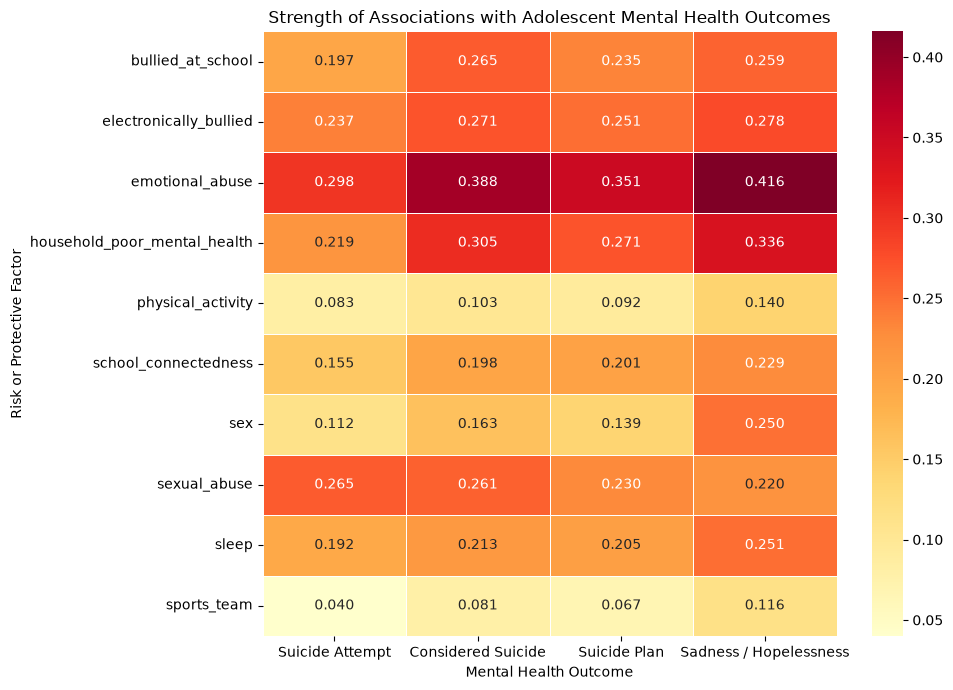

In [31]:
# Add suicide-attempt results to the multi-outcome results

attempt_heatmap_results = attempt_results_df.copy()
attempt_heatmap_results["Outcome"] = "attempted_at_least_once"

heatmap_results = pd.concat(
    [
        all_outcome_results[["Outcome", "Factor", "Cramer's V"]],
        attempt_heatmap_results[["Outcome", "Factor", "Cramer's V"]]
    ],
    ignore_index=True
)

# Create factor x outcome matrix
cramers_heatmap = heatmap_results.pivot(
    index="Factor",
    columns="Outcome",
    values="Cramer's V"
)

# Rename outcomes for readability
cramers_heatmap = cramers_heatmap.rename(
    columns={
        "persistent_sadness_hopelessness": "Sadness / Hopelessness",
        "considered_suicide": "Considered Suicide",
        "made_suicide_plan": "Suicide Plan",
        "attempted_at_least_once": "Suicide Attempt"
    }
)

# Plot heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    cramers_heatmap,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    linewidths=0.5
)

plt.title("Strength of Associations with Adolescent Mental Health Outcomes")
plt.xlabel("Mental Health Outcome")
plt.ylabel("Risk or Protective Factor")
plt.tight_layout()

plt.show()

### Heatmap Interpretation

The Cramér's V heatmap shows a consistent pattern across adolescent mental-health outcomes. Emotional abuse had the strongest association across all four outcomes and was particularly strongly associated with persistent sadness or hopelessness and seriously considering suicide.

Household poor mental health, electronic bullying, bullying at school, and sexual abuse also showed consistently elevated associations across multiple outcomes.

Sleep and school connectedness showed moderate associations across the mental-health outcomes, supporting their potential relevance as modifiable or protective factors. Physical activity and sports participation showed comparatively weaker associations.

Overall, the visualization reinforces the broader statistical findings: adverse childhood and household experiences and bullying show the strongest and most consistent relationships with adolescent mental-health outcomes, while several school and behavioral factors may represent additional intervention opportunities.

## Key Findings

* Mental-health concerns were common in the national YRBSS sample. Approximately 40.7% of respondents with valid data reported persistent sadness or hopelessness, 21.3% seriously considered suicide, 17.5% made a suicide plan, and 10.4% reported at least one suicide attempt.

* Female respondents reported substantially higher levels of persistent sadness or hopelessness, suicidal ideation, suicide planning, and suicide attempts than male respondents. Age differences were comparatively modest among the larger 14- to 17-year-old groups.

* Adverse childhood and household experiences showed some of the strongest relationships with adolescent mental-health outcomes. **Emotional abuse was the strongest and most consistent factor across all four outcomes examined**, with Cramér's V values of 0.416 for persistent sadness or hopelessness, 0.388 for considering suicide, 0.351 for making a suicide plan, and 0.298 for attempting suicide.

* Household poor mental health was also consistently associated with worse outcomes, including relatively strong associations with persistent sadness or hopelessness (V = 0.336) and considering suicide (V = 0.305). Sexual abuse was particularly notable for suicide attempts (V = 0.265).

* Bullying represented another consistent risk pattern. Electronic bullying and bullying at school were associated with persistent sadness or hopelessness, suicidal ideation, suicide planning, and suicide attempts. Electronic bullying generally showed slightly stronger associations than in-school bullying.

* Several adverse experiences also showed clear exposure gradients. Persistent sadness or hopelessness generally increased as emotional abuse, physical abuse, exposure to intimate partner violence, and school absence due to safety concerns became more frequent.

* School connectedness and sleep emerged as potentially important protective or modifiable factors. Stronger school connectedness was associated with lower prevalence of persistent sadness or hopelessness, while sadness or hopelessness declined from 64.1% among respondents reporting four or fewer hours of sleep to 25.2% among those reporting eight hours.

* Sleep remained associated with all four mental-health outcomes, with Cramér's V values ranging from 0.192 for suicide attempts to 0.251 for persistent sadness or hopelessness. School connectedness also showed consistent associations across outcomes, although its effect sizes were smaller than those observed for the strongest adverse-experience variables.

* Physical activity and sports-team participation generally corresponded with lower levels of persistent sadness or hopelessness, but their statistical associations were comparatively weak. Sports-team participation had the weakest association with suicide attempts among the selected factors (V = 0.040).

* The Cramér's V heatmap reinforced the overall pattern across outcomes: **adverse childhood experiences, household mental-health conditions, and bullying formed the strongest and most consistent cluster of associations**, while sleep and school connectedness occupied a middle tier of potentially modifiable factors and physical activity and sports participation showed weaker relationships.

* Because the national YRBSS sample is large, nearly all tested relationships reached statistical significance. Cramér's V was therefore used alongside chi-square tests to compare the relative strength of associations rather than relying on p-values alone.

Overall, the national YRBSS analysis suggests that adolescent mental-health outcomes are most strongly associated with adverse childhood experiences, household mental-health conditions, and bullying. School connectedness and sleep also show consistent relationships with mental health and may represent more actionable targets for prevention or early intervention. These national findings provide a behavioral and risk-factor framework that can later be interpreted alongside geographic YRBSS results and the project's healthcare-access, school-resource, and community-level datasets.


# YRBSS Geographic Data Analysis

## 1. Load and Validate Cleaned State and District Data

## 2. State-Level EDA
- 2023 mental-health prevalence by state
- 2019 → 2021 → 2023 trends
- bullying / sleep / selected adversity context
- identify high-burden states

## 3. District-Level EDA
- 2023 mental-health prevalence by district
- recent trends where repeated district data exist
- identify high-burden local jurisdictions

## 4. Statistical Analysis
- test whether mental-health outcomes differ across jurisdictions
- examine associations between selected geographic risk/protective measures and mental-health outcomes
- use survey-weighted prevalence where appropriate
- use effect sizes / appropriate categorical methods rather than forcing Pearson correlation onto categorical data

## 5. State vs District Context

## 6. Geographic Key Findings

In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load and Validate Cleaned Geographic Data

In [3]:
cleaned_dir = Path("../../data/cleaned")

district_path = cleaned_dir / "yrbss_2019_2023_district_cleaned.csv"
state_path = cleaned_dir / "yrbss_2019_2023_state_cleaned.csv"

district = pd.read_csv(district_path)
state = pd.read_csv(state_path)

print("District shape:", district.shape)
print("State shape:", state.shape)

print("\nDistrict years:")
print(district["year"].value_counts().sort_index())

print("\nState years:")
print(state["year"].value_counts().sort_index())

C:\Users\akila\AppData\Local\Temp\ipykernel_84952\2541450432.py:6: DtypeWarning: Columns (0: poor_mental_health, 1: adult_met_basic_needs, 2: emotional_abuse, 3: parent_guardian_incarceration, 4: witnessed_intimate_partner_violence, 5: physical_abuse, 6: sexual_abuse) have mixed types. Specify dtype option on import or set low_memory=False.
  district = pd.read_csv(district_path)
C:\Users\akila\AppData\Local\Temp\ipykernel_84952\2541450432.py:7: DtypeWarning: Columns (0: adult_met_basic_needs, 1: emotional_abuse, 2: parent_guardian_incarceration, 3: witnessed_intimate_partner_violence, 4: physical_abuse, 5: sexual_abuse) have mixed types. Specify dtype option on import or set low_memory=False.
  state = pd.read_csv(state_path)


District shape: (99808, 25)
State shape: (403042, 26)

District years:
year
2019    47305
2021    30375
2023    22128
Name: count, dtype: int64

State years:
year
2019    159198
2021    130025
2023    113819
Name: count, dtype: int64


## Survey-Weighted Prevalence

YRBSS records include survey weights that account for the survey sampling design. Geographic prevalence estimates are therefore calculated using respondent weights rather than simple unweighted percentages.

In [4]:
def weighted_prevalence(df, outcome, positive_value="Yes"):
    """
    Calculate survey-weighted prevalence for a categorical outcome.
    Missing outcome values and missing weights are excluded.
    """

    temp = df[[outcome, "weight"]].dropna().copy()

    temp["weight"] = pd.to_numeric(
        temp["weight"],
        errors="coerce"
    )

    temp = temp.dropna(subset=["weight"])

    positive = temp[outcome] == positive_value

    prevalence = (
        temp.loc[positive, "weight"].sum()
        / temp["weight"].sum()
        * 100
    )

    return prevalence

In [5]:
for year in [2019, 2021, 2023]:

    temp = state[state["year"] == year]

    prevalence = weighted_prevalence(
        temp,
        "persistent_sadness_hopelessness"
    )

    print(
        f"{year}: "
        f"{prevalence:.1f}% "
        "persistent sadness/hopelessness"
    )

2019: 36.7% persistent sadness/hopelessness
2021: 41.0% persistent sadness/hopelessness
2023: 39.6% persistent sadness/hopelessness


### Core Mental Health Trends

In [6]:
core_outcomes = {
    "persistent_sadness_hopelessness": "Sadness/Hopelessness",
    "considered_suicide": "Considered Suicide",
    "made_suicide_plan": "Made Suicide Plan",
    "attempted_suicide": "Attempted Suicide",
}

trend_rows = []

for year in [2019, 2021, 2023]:
    year_df = state[state["year"] == year]

    for variable, label in core_outcomes.items():

        positive_value = (
            "0 times"
            if variable == "attempted_suicide"
            else "Yes"
        )

        if variable == "attempted_suicide":
            temp = year_df[[variable, "weight"]].dropna().copy()
            temp["weight"] = pd.to_numeric(
                temp["weight"],
                errors="coerce"
            )
            temp = temp.dropna(subset=["weight"])

            positive = temp[variable] != "0 times"

            prevalence = (
                temp.loc[positive, "weight"].sum()
                / temp["weight"].sum()
                * 100
            )

        else:
            prevalence = weighted_prevalence(
                year_df,
                variable,
                positive_value="Yes"
            )

        trend_rows.append({
            "year": year,
            "outcome": label,
            "prevalence": prevalence
        })

state_trends = pd.DataFrame(trend_rows)

print(
    state_trends
    .pivot(
        index="year",
        columns="outcome",
        values="prevalence"
    )
    .round(1)
)

outcome  Attempted Suicide  Considered Suicide  Made Suicide Plan  \
year                                                                
2019                   9.1                19.4               15.6   
2021                  10.8                21.2               17.6   
2023                  10.1                19.8               16.3   

outcome  Sadness/Hopelessness  
year                           
2019                     36.7  
2021                     41.0  
2023                     39.6  


### Mental Health Trends Over Time

Survey-weighted prevalence is visualized across the 2019, 2021, and 2023 survey cycles to examine changes in core youth mental-health outcomes.

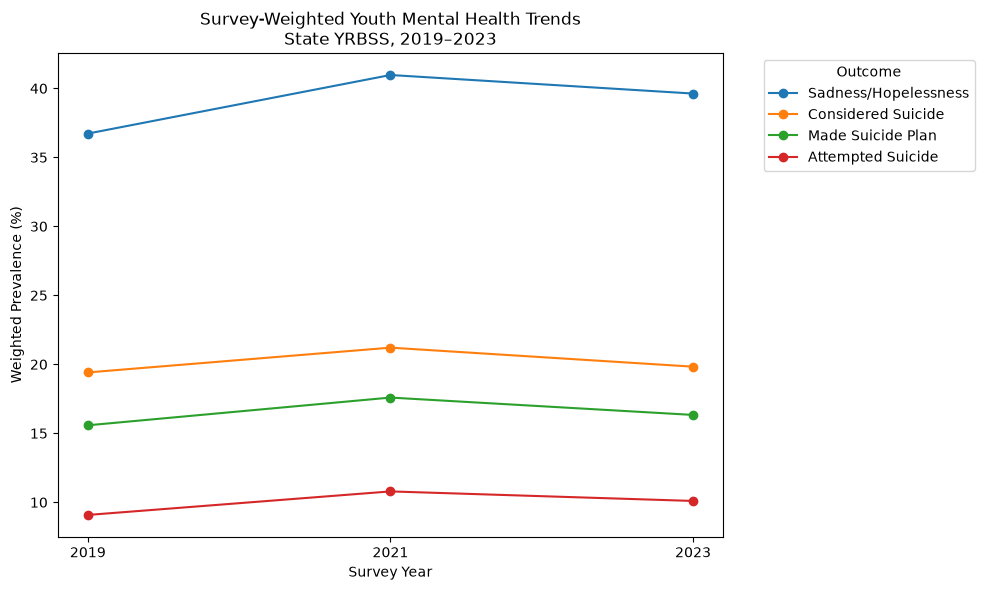

In [7]:
plt.figure(figsize=(10, 6))

for outcome in state_trends["outcome"].unique():
    temp = state_trends[
        state_trends["outcome"] == outcome
    ]

    plt.plot(
        temp["year"],
        temp["prevalence"],
        marker="o",
        label=outcome
    )

plt.title(
    "Survey-Weighted Youth Mental Health Trends\n"
    "State YRBSS, 2019–2023"
)

plt.xlabel("Survey Year")
plt.ylabel("Weighted Prevalence (%)")

plt.xticks([2019, 2021, 2023])

plt.legend(
    title="Outcome",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Related Risk and Protective Trends

To complement the core mental-health outcomes, survey-weighted trends were examined for bullying, electronic bullying, sleep, and poor mental health. These measures provide context on potentially modifiable or intervention-relevant factors associated with youth mental health.

In [8]:
# Build weighted trends for related risk/protective measures

context_rows = []

# Binary outcomes that use Yes as the positive category
binary_context = {
    "bullied_at_school": "Bullied at School",
    "electronically_bullied": "Electronically Bullied",
}

for year in [2019, 2021, 2023]:
    year_df = state[state["year"] == year]

    for variable, label in binary_context.items():
        prevalence = weighted_prevalence(
            year_df,
            variable,
            positive_value="Yes"
        )

        context_rows.append({
            "year": year,
            "measure": label,
            "prevalence": prevalence
        })

# Poor mental health only has useful coverage in 2021 and 2023
# Treat Sometimes / Most of the time / Always as elevated poor mental health
for year in [2021, 2023]:
    year_df = state[state["year"] == year]

    temp = year_df[
        ["poor_mental_health", "weight"]
    ].dropna().copy()

    temp["weight"] = pd.to_numeric(
        temp["weight"],
        errors="coerce"
    )

    temp = temp.dropna(subset=["weight"])

    elevated_categories = [
        "Sometimes",
        "Most of the time",
        "Always"
    ]

    elevated = temp["poor_mental_health"].isin(
        elevated_categories
    )

    prevalence = (
        temp.loc[elevated, "weight"].sum()
        / temp["weight"].sum()
        * 100
    )

    context_rows.append({
        "year": year,
        "measure": "Poor Mental Health",
        "prevalence": prevalence
    })


context_trends = pd.DataFrame(context_rows)

print(
    context_trends
    .pivot(
        index="year",
        columns="measure",
        values="prevalence"
    )
    .round(1)
)

measure  Bullied at School  Electronically Bullied  Poor Mental Health
year                                                                  
2019                  18.9                    14.5                 NaN
2021                  15.4                    15.0                58.5
2023                  19.2                    16.3                57.4


In [9]:
# Calculate weighted prevalence of insufficient sleep (< 8 hours)

insufficient_sleep_categories = [
    "4 or fewer hours",
    "5 hours",
    "6 hours",
    "7 hours"
]

sleep_rows = []

for year in [2019, 2021, 2023]:

    temp = state[
        state["year"] == year
    ][["sleep", "weight"]].dropna().copy()

    temp["weight"] = pd.to_numeric(
        temp["weight"],
        errors="coerce"
    )

    temp = temp.dropna(subset=["weight"])

    insufficient = temp["sleep"].isin(
        insufficient_sleep_categories
    )

    prevalence = (
        temp.loc[insufficient, "weight"].sum()
        / temp["weight"].sum()
        * 100
    )

    sleep_rows.append({
        "year": year,
        "measure": "Less Than 8 Hours Sleep",
        "prevalence": prevalence
    })

sleep_trends = pd.DataFrame(sleep_rows)

print(sleep_trends.round(1))

   year                  measure  prevalence
0  2019  Less Than 8 Hours Sleep        78.1
1  2021  Less Than 8 Hours Sleep        77.8
2  2023  Less Than 8 Hours Sleep        79.0


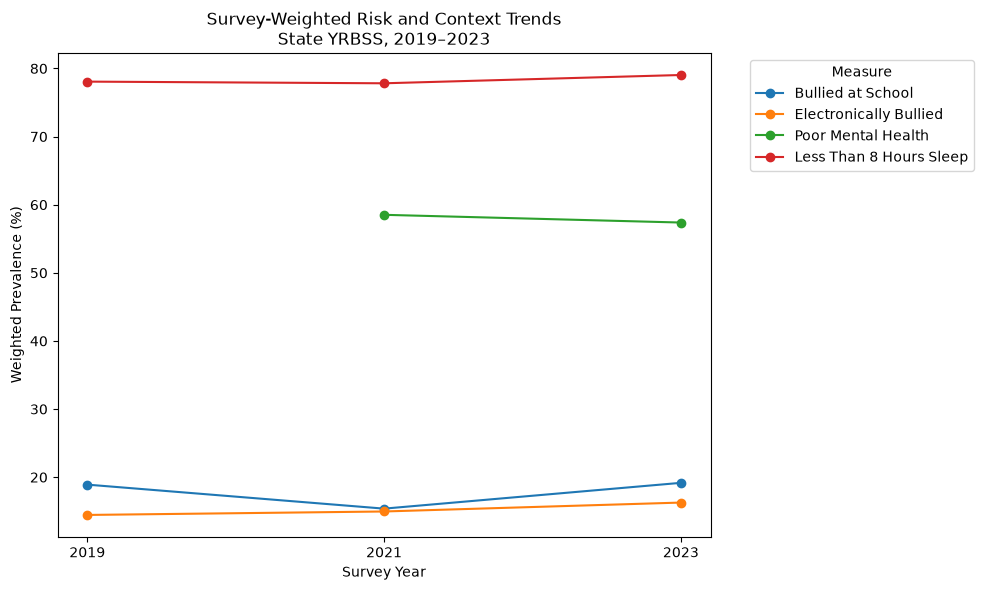

In [10]:
context_plot = pd.concat(
    [
        context_trends,
        sleep_trends
    ],
    ignore_index=True
)

plt.figure(figsize=(10, 6))

for measure in context_plot["measure"].unique():

    temp = context_plot[
        context_plot["measure"] == measure
    ]

    plt.plot(
        temp["year"],
        temp["prevalence"],
        marker="o",
        label=measure
    )

plt.title(
    "Survey-Weighted Risk and Context Trends\n"
    "State YRBSS, 2019–2023"
)

plt.xlabel("Survey Year")
plt.ylabel("Weighted Prevalence (%)")

plt.xticks([2019, 2021, 2023])

plt.legend(
    title="Measure",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Interpretation

The related risk and context measures show different patterns from the core mental-health outcomes.

Insufficient sleep was by far the most common condition across all three survey cycles. Nearly four in five students reported fewer than eight hours of sleep, and prevalence remained consistently high from 2019 through 2023.

School bullying declined between 2019 and 2021 before returning to approximately its pre-2021 level in 2023. Electronic bullying changed relatively little between 2019 and 2021 but increased in 2023.

Poor mental health, which is only available with sufficient coverage for 2021 and 2023, declined slightly between the two survey cycles but remained common among respondents with valid data.

Together, these trends suggest that the partial improvement seen in several mental-health outcomes in 2023 did not correspond to improvement across all potentially modifiable conditions. In particular, insufficient sleep remained highly prevalent, while bullying measures increased from their 2021 levels.

## State-Level Geographic Variation

The next analysis examines how youth mental-health burden varies across participating states. Survey-weighted prevalence estimates are calculated separately for each state so that high-burden jurisdictions can be identified.

In [11]:
# Calculate 2023 survey-weighted prevalence for each participating state

state_2023 = state[state["year"] == 2023].copy()

state_outcomes = {
    "persistent_sadness_hopelessness": "Sadness/Hopelessness",
    "considered_suicide": "Considered Suicide",
    "made_suicide_plan": "Made Suicide Plan",
    "attempted_suicide": "Attempted Suicide",
}

state_results = []

for state_name, group in state_2023.groupby("sitename"):

    row = {
        "state": state_name,
        "n": len(group)
    }

    for variable, label in state_outcomes.items():

        if variable == "attempted_suicide":
            temp = group[[variable, "weight"]].dropna().copy()

            temp["weight"] = pd.to_numeric(
                temp["weight"],
                errors="coerce"
            )

            temp = temp.dropna(subset=["weight"])

            if len(temp) > 0:
                positive = temp[variable] != "0 times"

                prevalence = (
                    temp.loc[positive, "weight"].sum()
                    / temp["weight"].sum()
                    * 100
                )
            else:
                prevalence = np.nan

        else:
            prevalence = weighted_prevalence(
                group,
                variable,
                positive_value="Yes"
            )

        row[label] = prevalence

    state_results.append(row)

state_2023_prevalence = pd.DataFrame(state_results)

state_2023_prevalence = (
    state_2023_prevalence
    .sort_values(
        "Sadness/Hopelessness",
        ascending=False
    )
)

print(
    state_2023_prevalence
    .round(1)
    .to_string(index=False)
)

                         state     n  Sadness/Hopelessness  Considered Suicide  Made Suicide Plan  Attempted Suicide
                  Indiana (IN)  1043                  47.0                25.2               23.6               15.7
                 Arkansas (AR)   706                  45.1                24.4               21.6               14.6
                 Oklahoma (OK)  1748                  44.9                23.3               18.4               12.1
                 Missouri (MO)   662                  44.3                25.6                NaN                NaN
                   Nevada (NV)  1471                  44.1                20.9               19.4               10.3
                  Montana (MT)  3610                  43.3                26.1               21.4               11.3
                   Alaska (AK)  1170                  43.2                22.6               20.5               19.0
                Tennessee (TN)  1573                  42.7      

C:\Users\akila\AppData\Local\Temp\ipykernel_84952\1561279083.py:19: RuntimeWarning: invalid value encountered in scalar divide
  temp.loc[positive, "weight"].sum()
C:\Users\akila\AppData\Local\Temp\ipykernel_84952\1561279083.py:19: RuntimeWarning: invalid value encountered in scalar divide
  temp.loc[positive, "weight"].sum()
C:\Users\akila\AppData\Local\Temp\ipykernel_84952\1561279083.py:19: RuntimeWarning: invalid value encountered in scalar divide
  temp.loc[positive, "weight"].sum()


In [12]:
def weighted_prevalence(df, outcome, positive_value="Yes"):
    """
    Calculate survey-weighted prevalence for a categorical outcome.
    Returns NaN when no valid weighted responses are available.
    """

    temp = df[[outcome, "weight"]].dropna().copy()

    temp["weight"] = pd.to_numeric(
        temp["weight"],
        errors="coerce"
    )

    temp = temp.dropna(subset=["weight"])

    if temp.empty or temp["weight"].sum() == 0:
        return np.nan

    positive = temp[outcome] == positive_value

    return (
        temp.loc[positive, "weight"].sum()
        / temp["weight"].sum()
        * 100
    )

### 2023 State Mental Health Burden

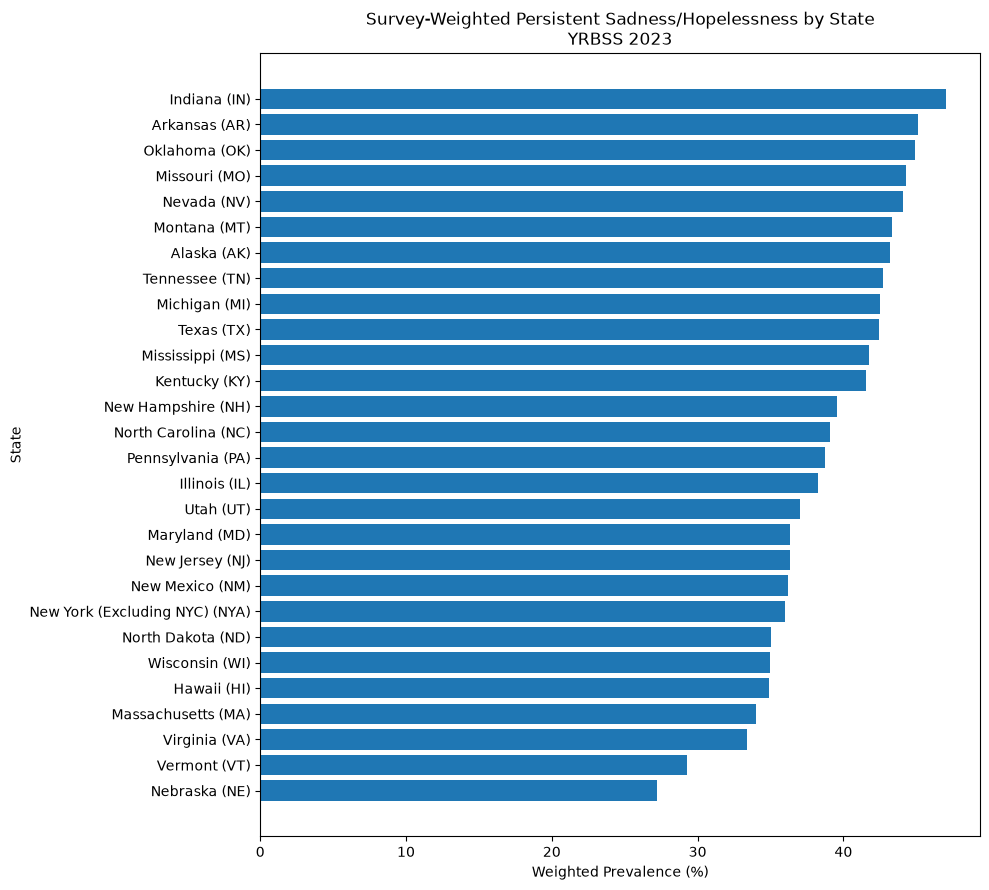

In [13]:
plot_states = (
    state_2023_prevalence
    .dropna(subset=["Sadness/Hopelessness"])
    .sort_values("Sadness/Hopelessness")
)

plt.figure(figsize=(10, 9))

plt.barh(
    plot_states["state"],
    plot_states["Sadness/Hopelessness"]
)

plt.title(
    "Survey-Weighted Persistent Sadness/Hopelessness by State\n"
    "YRBSS 2023"
)

plt.xlabel("Weighted Prevalence (%)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

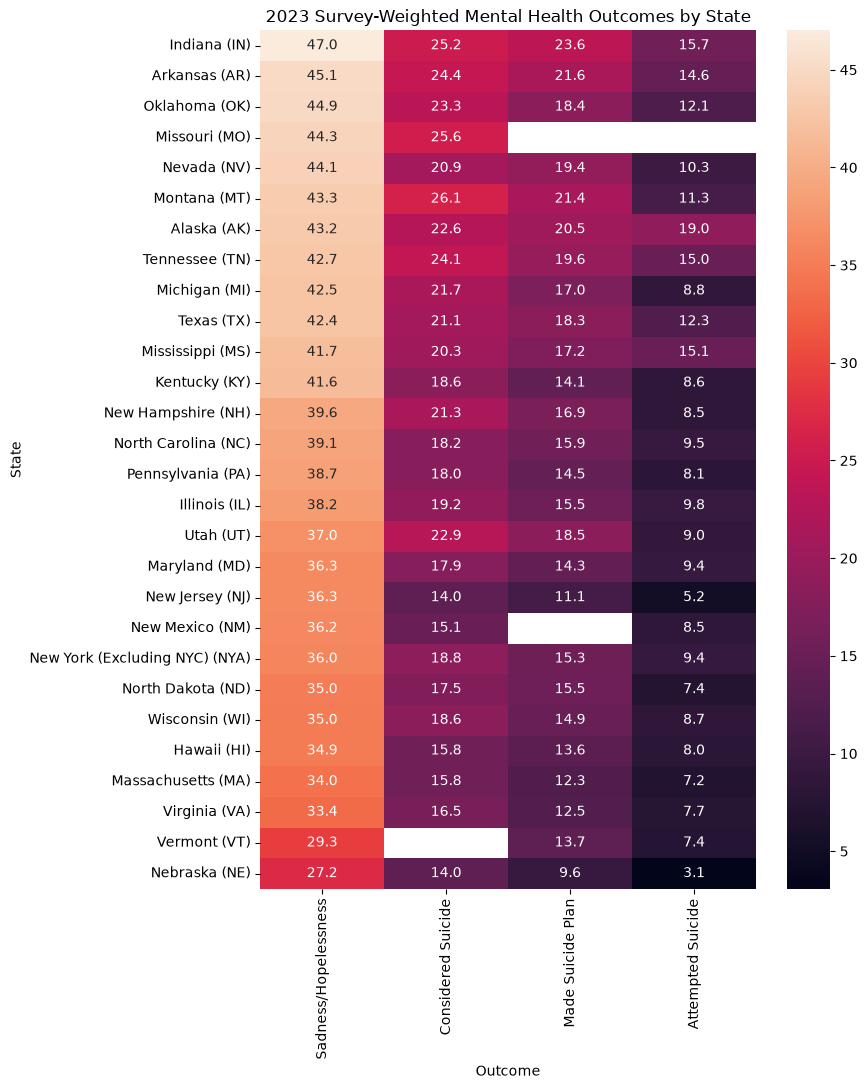

In [14]:
heatmap_data = (
    state_2023_prevalence
    .set_index("state")[
        [
            "Sadness/Hopelessness",
            "Considered Suicide",
            "Made Suicide Plan",
            "Attempted Suicide"
        ]
    ]
)

plt.figure(figsize=(9, 11))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f"
)

plt.title(
    "2023 Survey-Weighted Mental Health Outcomes by State"
)

plt.xlabel("Outcome")
plt.ylabel("State")

plt.tight_layout()
plt.show()

### Interpretation

Mental-health burden varied substantially across participating states in 2023.

Indiana had the highest survey-weighted prevalence of persistent sadness or hopelessness at 47.0%, followed by Arkansas at 45.1% and Oklahoma at 44.9%. Several of the states with high sadness/hopelessness also ranked highly across suicide-related outcomes, suggesting that elevated burden was not limited to a single measure.

However, the pattern was not identical across outcomes. Montana had the highest prevalence of considering suicide among the participating states shown at 26.1%, while Alaska had the highest prevalence of suicide attempts at 19.0%.

The heatmap highlights clusters of states with elevated burden across multiple mental-health outcomes while also showing that individual jurisdictions can have distinct outcome profiles. Missing cells reflect outcomes without sufficient available survey data for that state and should not be interpreted as zero prevalence.

## District-Level Geographic Variation

District-level YRBSS data provide the most local geographic view available in the combined survey files. Survey-weighted prevalence estimates are calculated separately for each participating district to identify local jurisdictions with elevated youth mental-health burden.

Because district participation varies across survey years, 2023 is used as the primary local snapshot.

In [15]:
# Calculate 2023 survey-weighted prevalence for each participating district

district_2023 = district[district["year"] == 2023].copy()

district_outcomes = {
    "persistent_sadness_hopelessness": "Sadness/Hopelessness",
    "considered_suicide": "Considered Suicide",
    "made_suicide_plan": "Made Suicide Plan",
    "attempted_suicide": "Attempted Suicide",
}

district_results = []

for district_name, group in district_2023.groupby("sitename"):

    row = {
        "district": district_name,
        "n": len(group)
    }

    for variable, label in district_outcomes.items():

        if variable == "attempted_suicide":
            temp = group[[variable, "weight"]].dropna().copy()

            temp["weight"] = pd.to_numeric(
                temp["weight"],
                errors="coerce"
            )

            temp = temp.dropna(subset=["weight"])

            if temp.empty or temp["weight"].sum() == 0:
                prevalence = np.nan
            else:
                positive = temp[variable] != "0 times"

                prevalence = (
                    temp.loc[positive, "weight"].sum()
                    / temp["weight"].sum()
                    * 100
                )

        else:
            prevalence = weighted_prevalence(
                group,
                variable,
                positive_value="Yes"
            )

        row[label] = prevalence

    district_results.append(row)

district_2023_prevalence = pd.DataFrame(
    district_results
)

district_2023_prevalence = (
    district_2023_prevalence
    .sort_values(
        "Sadness/Hopelessness",
        ascending=False
    )
)

print(
    district_2023_prevalence
    .round(1)
    .to_string(index=False)
)

                   district    n  Sadness/Hopelessness  Considered Suicide  Made Suicide Plan  Attempted Suicide
      Philadelphia, PA (PH) 1010                  46.0                21.4               19.1               13.2
       Los Angeles, CA (LO) 1323                  42.7                14.8               14.4               10.2
           Chicago, IL (CH) 1448                  40.6                15.7               12.1                7.3
         San Diego, CA (SA) 1488                  40.3                21.0                NaN               10.0
Spartanburg County, SC (SP) 1112                  37.5                 NaN               15.1                NaN
       Albuquerque, NM (AB) 3428                  36.8                14.5                NaN                8.0
    New York City, NY (NYC) 8338                  35.5                17.9                NaN               13.6
          Portland, OR (PO) 1343                  33.5                14.5               10.7   

### Interpretation

District-level results reveal substantial local variation within the 2023 YRBSS.

Philadelphia had the highest survey-weighted prevalence of persistent sadness or hopelessness among participating districts at 46.0%, followed by Los Angeles at 42.7%. Chicago and San Diego also exceeded 40%.

Philadelphia also showed elevated suicide-related burden, including 21.4% considering suicide, 19.1% making a suicide plan, and 13.2% attempting suicide.

However, district profiles were not uniform across outcomes. New York City had a lower sadness/hopelessness prevalence than several other districts at 35.5%, but its suicide-attempt prevalence was comparatively high at 13.6%.

These differences illustrate why district-level analysis adds value beyond state-level estimates. Local jurisdictions can show distinct combinations of mental-health burden even when they are located within the same broader state context.

Missing values indicate district-outcome combinations without sufficient available survey data and should not be interpreted as zero prevalence.

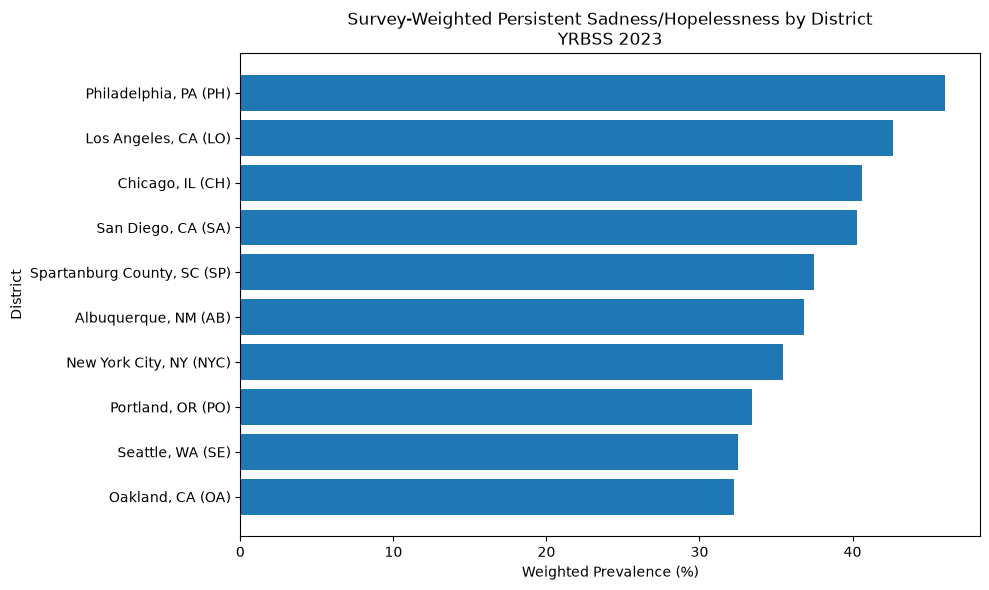

In [16]:
plot_districts = (
    district_2023_prevalence
    .dropna(subset=["Sadness/Hopelessness"])
    .sort_values("Sadness/Hopelessness")
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_districts["district"],
    plot_districts["Sadness/Hopelessness"]
)

plt.title(
    "Survey-Weighted Persistent Sadness/Hopelessness by District\n"
    "YRBSS 2023"
)

plt.xlabel("Weighted Prevalence (%)")
plt.ylabel("District")

plt.tight_layout()
plt.show()

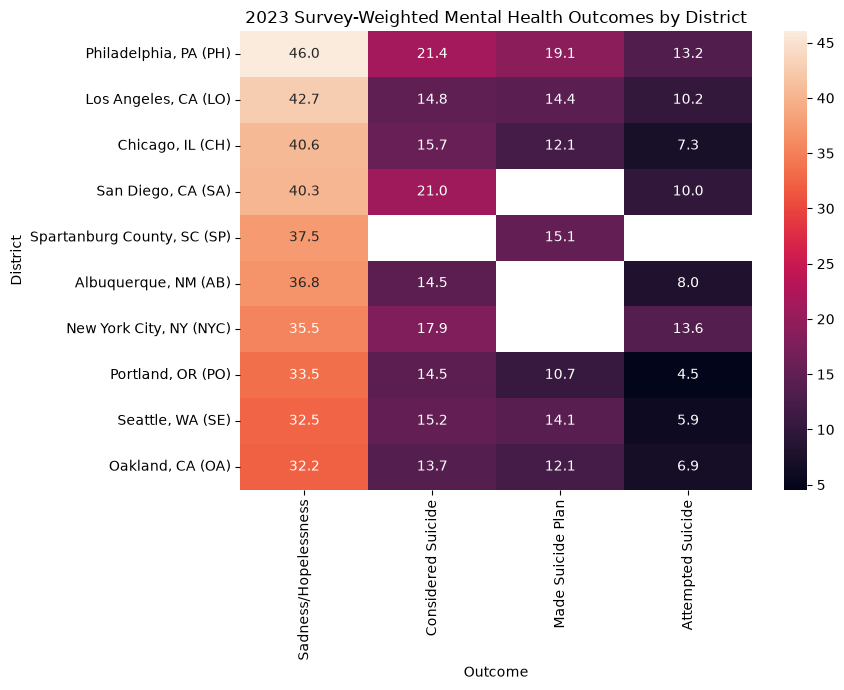

In [17]:
district_heatmap = (
    district_2023_prevalence
    .set_index("district")[
        [
            "Sadness/Hopelessness",
            "Considered Suicide",
            "Made Suicide Plan",
            "Attempted Suicide"
        ]
    ]
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    district_heatmap,
    annot=True,
    fmt=".1f"
)

plt.title(
    "2023 Survey-Weighted Mental Health Outcomes by District"
)

plt.xlabel("Outcome")
plt.ylabel("District")

plt.tight_layout()
plt.show()

### District Trends Across Survey Years

To examine local change over time, district-level trends are calculated only for jurisdictions represented in multiple survey cycles. This avoids comparing different sets of districts as though they were the same local populations.

In [18]:
# Identify districts represented in at least two survey years

district_year_counts = (
    district
    .groupby("sitename")["year"]
    .nunique()
    .sort_values(ascending=False)
)

repeated_districts = district_year_counts[
    district_year_counts >= 2
].index.tolist()

print("Districts represented in at least two survey years:")
print(len(repeated_districts))

for name in repeated_districts:
    years = sorted(
        district.loc[
            district["sitename"] == name,
            "year"
        ].unique()
    )
    
    print(f"{name}: {years}")

Districts represented in at least two survey years:
17
Albuquerque, NM (AB): [np.int64(2019), np.int64(2021), np.int64(2023)]
New York City, NY (NYC): [np.int64(2019), np.int64(2021), np.int64(2023)]
Seattle, WA (SE): [np.int64(2019), np.int64(2021), np.int64(2023)]
San Diego, CA (SA): [np.int64(2019), np.int64(2021), np.int64(2023)]
Portland, OR (PO): [np.int64(2019), np.int64(2021), np.int64(2023)]
Philadelphia, PA (PH): [np.int64(2019), np.int64(2021), np.int64(2023)]
Oakland, CA (OA): [np.int64(2019), np.int64(2021), np.int64(2023)]
Los Angeles, CA (LO): [np.int64(2019), np.int64(2021), np.int64(2023)]
Chicago, IL (CH): [np.int64(2019), np.int64(2021), np.int64(2023)]
Spartanburg County, SC (SP): [np.int64(2019), np.int64(2021), np.int64(2023)]
Duval County, FL (DU): [np.int64(2019), np.int64(2021)]
Fort Worth, TX (FW): [np.int64(2019), np.int64(2021)]
Hillsborough County, FL (HL): [np.int64(2019), np.int64(2021)]
Broward County, FL (FT): [np.int64(2019), np.int64(2021)]
Orange Cou

In [19]:
# Calculate district-level sadness/hopelessness trends
# for jurisdictions represented in multiple survey years

district_trend_rows = []

for district_name in repeated_districts:

    district_subset = district[
        district["sitename"] == district_name
    ]

    for year in sorted(district_subset["year"].unique()):

        year_group = district_subset[
            district_subset["year"] == year
        ]

        prevalence = weighted_prevalence(
            year_group,
            "persistent_sadness_hopelessness",
            positive_value="Yes"
        )

        district_trend_rows.append({
            "district": district_name,
            "year": year,
            "prevalence": prevalence
        })

district_sadness_trends = pd.DataFrame(
    district_trend_rows
)

print(
    district_sadness_trends
    .pivot(
        index="district",
        columns="year",
        values="prevalence"
    )
    .round(1)
    .to_string()
)

year                          2019  2021  2023
district                                      
Albuquerque, NM (AB)          40.0  43.4  36.8
Broward County, FL (FT)       36.9  41.8   NaN
Chicago, IL (CH)              38.2  43.0  40.6
Duval County, FL (DU)         39.6  45.1   NaN
Fort Worth, TX (FW)           33.5  40.7   NaN
Hillsborough County, FL (HL)  37.6  48.9   NaN
Los Angeles, CA (LO)          34.0  40.9  42.7
New York City, NY (NYC)       35.9  38.2  35.5
Oakland, CA (OA)              31.6  44.4  32.2
Orange County, FL (OL)        37.1  41.7   NaN
Palm Beach County, FL (PB)    34.5  41.5   NaN
Pasco County, FL (PS)         42.2  45.2   NaN
Philadelphia, PA (PH)         40.3  44.6  46.0
Portland, OR (PO)             33.7  38.3  33.5
San Diego, CA (SA)            35.1  42.5  40.3
Seattle, WA (SE)              27.8  38.0  32.5
Spartanburg County, SC (SP)   35.4  38.8  37.5


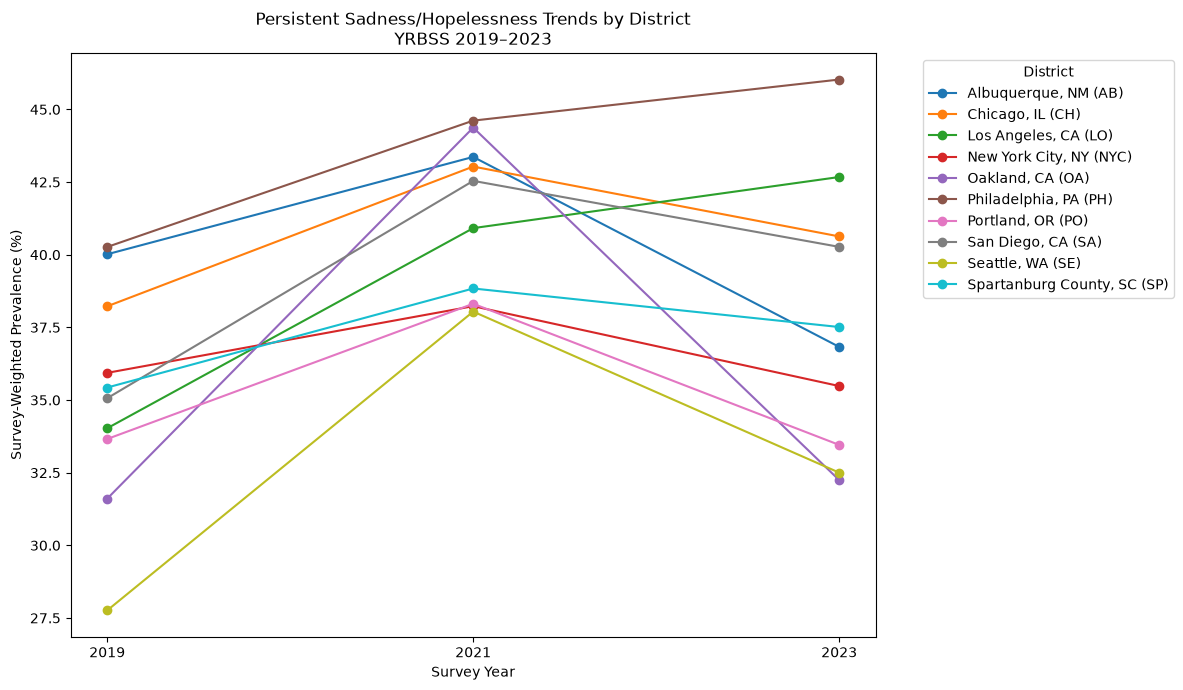

In [20]:
# Keep only districts represented in all three survey years

complete_districts = (
    district
    .groupby("sitename")["year"]
    .nunique()
)

complete_districts = complete_districts[
    complete_districts == 3
].index.tolist()

complete_trends = district_sadness_trends[
    district_sadness_trends["district"].isin(
        complete_districts
    )
].copy()

plt.figure(figsize=(12, 7))

for district_name in complete_districts:

    temp = complete_trends[
        complete_trends["district"] == district_name
    ]

    plt.plot(
        temp["year"],
        temp["prevalence"],
        marker="o",
        label=district_name
    )

plt.title(
    "Persistent Sadness/Hopelessness Trends by District\n"
    "YRBSS 2019–2023"
)

plt.xlabel("Survey Year")
plt.ylabel("Survey-Weighted Prevalence (%)")

plt.xticks([2019, 2021, 2023])

plt.legend(
    title="District",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Interpretation

Among the ten districts represented in all three survey cycles, local trends varied considerably.

Philadelphia and Los Angeles showed sustained increases in persistent sadness or hopelessness from 2019 through 2023. Philadelphia increased from 40.3% in 2019 to 46.0% in 2023, while Los Angeles increased from 34.0% to 42.7%.

Several districts followed the broader state-level pattern of worsening in 2021 followed by partial improvement in 2023. Chicago, San Diego, Seattle, and Spartanburg County remained above their 2019 levels in 2023, although below their 2021 peaks.

Other districts returned close to or below their 2019 levels. Oakland declined from a 2021 peak of 44.4% to 32.2% in 2023, while New York City and Portland returned approximately to their 2019 prevalence levels. Albuquerque declined below its 2019 estimate by 2023.

These differences suggest that the post-2021 trajectory was not geographically uniform. Some local jurisdictions experienced substantial recovery while others showed persistent or increasing mental-health burden.

## Statistical Analysis

To test whether geographic differences in youth mental-health burden are statistically meaningful, categorical association tests are applied to 2023 state and district data.

Chi-square tests are used because the primary outcomes are categorical. Cramér’s V is reported as an effect-size measure so that the strength of geographic association can be interpreted in addition to statistical significance.

In [21]:
from scipy.stats import chi2_contingency

In [22]:
def cramers_v(contingency_table):
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    n = contingency_table.to_numpy().sum()

    if n == 0:
        return np.nan, p

    r, k = contingency_table.shape

    phi2 = chi2 / n

    correction = ((k - 1) * (r - 1)) / (n - 1)

    phi2corr = max(
        0,
        phi2 - correction
    )

    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)

    denominator = min(
        kcorr - 1,
        rcorr - 1
    )

    if denominator <= 0:
        return np.nan, p

    v = np.sqrt(
        phi2corr / denominator
    )

    return v, p

In [23]:
state_test = state[
    (state["year"] == 2023)
    & state["persistent_sadness_hopelessness"].notna()
].copy()

state_table = pd.crosstab(
    state_test["sitename"],
    state_test["persistent_sadness_hopelessness"]
)

state_v, state_p = cramers_v(
    state_table
)

print("2023 State vs Sadness/Hopelessness")
print(f"Cramér's V: {state_v:.3f}")
print(f"p-value: {state_p:.6g}")

2023 State vs Sadness/Hopelessness
Cramér's V: 0.086
p-value: 9.38098e-162


In [24]:
district_test = district[
    (district["year"] == 2023)
    & district["persistent_sadness_hopelessness"].notna()
].copy()

district_table = pd.crosstab(
    district_test["sitename"],
    district_test["persistent_sadness_hopelessness"]
)

district_v, district_p = cramers_v(
    district_table
)

print("2023 District vs Sadness/Hopelessness")
print(f"Cramér's V: {district_v:.3f}")
print(f"p-value: {district_p:.6g}")

2023 District vs Sadness/Hopelessness
Cramér's V: 0.066
p-value: 4.56125e-18


### Geographic Association With Sadness/Hopelessness

Geographic location was significantly associated with persistent sadness or hopelessness in 2023 at both the state and district levels.

At the state level, the association was statistically significant with Cramér’s V = 0.086. At the district level, the association was also statistically significant with Cramér’s V = 0.066.

Although the very small p-values indicate that the observed geographic differences are unlikely to be due to chance alone, the Cramér’s V values indicate relatively small effect sizes.

This means geography helps distinguish differences in youth mental-health burden, but geographic location by itself explains only part of the variation. The stronger individual-level risk and protective factors identified in the national YRBSS analysis remain important for understanding why mental-health outcomes differ.

In [25]:
context_factors = [
    "bullied_at_school",
    "electronically_bullied",
    "sleep",
]

context_results = []

for variable in context_factors:

    temp = state[
        (state["year"] == 2023)
        & state[variable].notna()
        & state["persistent_sadness_hopelessness"].notna()
    ].copy()

    table = pd.crosstab(
        temp[variable],
        temp["persistent_sadness_hopelessness"]
    )

    v, p = cramers_v(table)

    context_results.append({
        "factor": variable,
        "cramers_v": v,
        "p_value": p
    })

context_associations = pd.DataFrame(
    context_results
).sort_values(
    "cramers_v",
    ascending=False
)

print(
    context_associations
    .round(4)
    .to_string(index=False)
)

                factor  cramers_v  p_value
electronically_bullied     0.2674      0.0
     bullied_at_school     0.2569      0.0
                 sleep     0.2225      0.0


### Modifiable and Contextual Associations With Sadness/Hopelessness

Among the 2023 state YRBSS respondents, electronic bullying showed the strongest association with persistent sadness or hopelessness among the selected contextual factors (Cramér’s V = 0.267), followed closely by bullying at school (V = 0.257).

Sleep also showed a meaningful association with sadness or hopelessness (V = 0.223).

All three associations were statistically significant.

These effect sizes were notably larger than the association between geographic location itself and sadness or hopelessness. State geography had a Cramér’s V of 0.086 and district geography had a Cramér’s V of 0.066.

This suggests that geographic differences help identify where mental-health burden is concentrated, while individual experiences such as bullying and sleep may be more informative for understanding which potentially modifiable conditions are associated with that burden.

In [26]:
comparison_effects = pd.DataFrame({
    "factor": [
        "Electronic bullying",
        "Bullying at school",
        "Sleep",
        "State geography",
        "District geography"
    ],
    "cramers_v": [
        0.2674,
        0.2569,
        0.2225,
        state_v,
        district_v
    ]
}).sort_values(
    "cramers_v",
    ascending=False
)

print(
    comparison_effects
    .round(3)
    .to_string(index=False)
)

             factor  cramers_v
Electronic bullying      0.267
 Bullying at school      0.257
              Sleep      0.222
    State geography      0.086
 District geography      0.066


## Geographic Key Findings

The geographic YRBSS analysis showed that youth mental-health burden varies meaningfully across both states and local districts, but geography alone had a relatively small association with persistent sadness or hopelessness.

Across participating state samples, persistent sadness or hopelessness increased from 36.7% in 2019 to 41.0% in 2021 before declining slightly to 39.6% in 2023. Suicide consideration, planning, and attempts followed a similar pattern, with 2021 representing the highest prevalence across all four core outcomes.

State-level burden varied considerably in 2023. Indiana had the highest prevalence of persistent sadness or hopelessness at 47.0%, while Montana had the highest prevalence of considering suicide at 26.1%. Alaska had the highest prevalence of suicide attempts at 19.0%.

District-level analysis revealed additional local variation. Philadelphia had the highest prevalence of persistent sadness or hopelessness among participating 2023 districts at 46.0%, followed by Los Angeles at 42.7%. Philadelphia also showed elevated suicide-related burden.

Longitudinal district patterns were not uniform. Philadelphia and Los Angeles showed sustained increases in sadness or hopelessness from 2019 through 2023, while several other districts experienced a 2021 peak followed by partial or substantial improvement in 2023.

Geographic location was statistically associated with sadness or hopelessness, but effect sizes were small:
- State geography: Cramér’s V = 0.086
- District geography: Cramér’s V = 0.066

By comparison, potentially modifiable or intervention-relevant factors showed substantially stronger associations:
- Electronic bullying: Cramér’s V = 0.267
- Bullying at school: Cramér’s V = 0.257
- Sleep: Cramér’s V = 0.222

Overall, the geographic analysis suggests that state and district data are valuable for identifying where youth mental-health burden is concentrated and how local trends differ over time. However, individual experiences such as bullying and sleep appear more strongly associated with mental-health outcomes than geography itself.

These findings complement the national YRBSS analysis by distinguishing between **where burden is concentrated** and **which modifiable conditions are most strongly associated with that burden**.

### Analysis Note

State and district YRBSS samples were analyzed separately and survey weights were used for prevalence estimates. Missing jurisdiction-question combinations were preserved as missing rather than interpreted as zero. Associations are cross-sectional and should not be interpreted as causal.